 Covered Call Strategy — نسخه پیشرفته (Enhanced v17)
 بورس اوراق بهادار تهران
 «مدیریت سبد سرمایه‌گذاری پرتفوی از طریق روش اختیار خرید
  پوشش داده‌شده با استفاده از یادگیری عمیق»

 🆕 v17 — مدلِ نهم: CNN-LSTM. تا این‌جا تنها مدلِ سری‌زمانیِ اختصاصی
 LSTM+Attention بود که مستقیماً روی فیچرهای اسکیل‌شدهٔ هر روزِ پنجره کار
 می‌کرد. اکنون یک لایهٔ Conv1d علّی (فقط داخلِ همان پنجرهٔ تاریخیِ بسته‌شده،
 بدون نگاه به آینده؛ کرنل همیشه فرد و padding='same' تا طولِ دنباله تغییر
 نکند) پیش از LSTM اضافه شده — معماریِ استانداردِ CNN-LSTM که ابتدا
 الگوهای محلیِ کوتاه‌مدت (شبیهِ یک الگوی چند-کندلی) را استخراج می‌کند،
 سپس LSTM+Attention روی دنبالهٔ حاصل تصمیم می‌گیرد. به‌جای یک کلاسِ کاملاً
 جدید، همان `LSTMSeqClassifier`/`_LSTMNet` با پرچمِ `use_cnn` گسترش یافت
 (و `train_cnn_lstm` به‌عنوان تابعِ تیونِ Optuna جداگانه اضافه شد) تا
 منطقِ windowing/early-stopping/clone_for_refit عیناً و بدون دوباره‌نویسی
 به ارث برسد. مدلِ جدید (`cnn_lstm`) دقیقاً مثلِ بقیهٔ مدل‌های منفرد وارد
 تورنومنتِ CELL 7، کاندیدهای Stacking/Voting، Walk-Forward (CELL 8.5)، و
 آزمایشِ کاهشِ فیچر (CELL 10.8) می‌شود — نه یک مسیرِ جداگانه؛ اگر روی یک
 سهم واقعاً از LSTM/گرادیان‌بوستینگ‌ها بهتر عمل نکند، همین‌طور صادقانه
 گزارش می‌شود (FRAUD همچنان این مدل را ندارد، طبق طراحیِ اصلیِ ۵-مدلی‌اش).

 🆕 v16 — فیچرِ کلانِ نرخِ دلارِ آزاد: تا این‌جا تمامِ ۹۶ فیچر فقط از
 خودِ قیمت/حجمِ سهم ساخته می‌شدند — هیچ متغیرِ کلانِ اقتصادی وجود نداشت،
 با این‌که سهم‌های این نمونه (فملی/فولاد/شپنا) عمدتاً صادرات‌محورند و
 سودشان مستقیم به نرخِ ارز وابسته است. اکنون ۴ فیچرِ جدید
 (`usd_ret`, `usd_ret20`, `usd_vol20`, `usd_dev_sma50` — CELL 4، بلافاصله
 بعد از market_ret/market_vol) از نرخِ دلارِ آزاد ساخته می‌شوند؛ عمداً
 فقط بازده/انحرافِ کوتاه‌مدت گرفته شده، نه سطحِ خامِ دلار (که در این بازه
 یک روندِ تقریباً یک‌طرفه است و می‌تواند صرفاً «زمان» را نشت بدهد، نه
 سیگنالِ معاملاتیِ واقعی). دادهٔ نرخِ ارز از دیتاستِ عمومیِ
 `Dollar-Rial-Toman-Live-Price-Dataset` (منبعِ اصلی: TGJU.org) به
 `data/USD_IRR.csv` تبدیل شده و به‌صورتِ اختیاری بارگذاری می‌شود
 (CELL 3.4) — نبودِ فایل کرش نمی‌کند، فقط این ۴ فیچر صفر می‌مانند.
 یک فیچرِ خواسته‌شدهٔ دوم (ورود/خروجِ پولِ حقیقی/حقوقی، از TSETMC) به‌خاطرِ
 بلاک‌بودنِ دسترسیِ شبکه به tsetmc.com/tse.ir در محیطِ اجرای این کد اضافه
 نشد — به‌جای جعل یا تقریب‌زدنِ این داده، به‌طورِ صریح کنار گذاشته شد؛
 اگر این داده بعداً از منبعِ دیگری در دسترس قرار گرفت، می‌توان با همین
 الگو (بارگذاریِ اختیاری + reindex/ffill بدونِ نگاه‌به‌آینده) اضافه‌اش کرد.

 🆕 v15 — تورنمنتِ چند-افقی + انتخابِ افق روی Walk-Forward: تا این‌جا
 HOLD_DAYS=5 (هم افقِ target و هم طولِ فرضیِ آپشن در بک‌تست) یک انتخابِ
 کاملاً دلبخواهی بود. اکنون CELL 4.8 به‌ازای هر سهم چند افقِ کاندید
 (۳/۵/۱۰/۱۵/۲۰ روز) را با یک مدلِ سبک و ثابت روی چند فولدِ Walk-Forward
 می‌سنجد و افقِ برنده را صرفاً بر همان اساس انتخاب می‌کند — نه با
 امتحان‌کردنِ چند افق و برداشتنِ بهترین روی Test، که خودش یک نمونهٔ
 data snooping می‌بود. افقِ منتخبِ هر سهم سپس در تمامِ pipeline (Purge
 Gap، Stacking OOF، Walk-Forward خودِ CELL 8.5، بک‌تست/گیتِ بلک-شولز،
 Sharpe/Sortino سالانه‌شده، و بهینه‌سازیِ پرتفوی) به‌طور یکدست جاری
 می‌شود؛ ستونِ «Horizon (days)» در جدولِ نهایی (CELL 13) این افق را
 به‌ازای هر سهم شفاف نشان می‌دهد. جزئیاتِ کاملِ تورنمنتِ افق (همهٔ
 کاندیدها، نه فقط برنده) در horizon_selection_summary.csv ذخیره
 می‌شود تا هیچ شبهه‌ی cherry-picking نماند. FRAUD demo (CELL 13.8) و
 آزمایشِ Feature-Pruning (CELL 10.8) هم افقِ همان سهم را به ارث
 می‌برند تا مقایسه‌ها apples-to-apples بمانند.

 🆕 v14 — ایمنی‌سازیِ انتخاب بر اساسِ Walk-Forward: تا نسخهٔ قبل،
 Walk-Forward Check فقط یک ابزارِ *تشخیصی* بود — مشکل را نشان می‌داد
 ولی هیچ اثری روی جدولِ رسمی نداشت (به همین دلیل در v13 یک انتخابِ
 Overfit-شده — LSTM برای Fameli با AUC رسمیِ ۴۴٪ — بدونِ هشدار وارد
 جدولِ نهایی شد). اکنون اگر AUC والک‌فوروارد مدلِ برندهٔ CELL 7 به‌طور
 مشخص نزدیکِ تصادف باشد (زیرِ ۰.۵۲)، پایپ‌لاین به‌جای آن مدلِ تکی،
 خودکار به میانگینِ رتبه‌ایِ (Rank-Average) همهٔ مدل‌های منفرد سقوط
 می‌کند — گزینه‌ای که چون از چند مدلِ مستقل ساخته شده، ذاتاً کمتر در
 معرضِ Overfit-شدنِ یک مدلِ خاص است. این حلقهٔ «تشخیص → واکنش» را
 می‌بندد و پیشنهادِ کاربر در جلسهٔ توسعه بود.

 🆕 v13 — تقویتِ معماریِ LSTM (تنها مدلِ سری‌زمانیِ اختصاصیِ این
 پروژه): اضافه‌شدنِ مکانیزمِ Attention (به‌جای این‌که فقط آخرین روزِ
 پنجره ملاک باشد، مدل یاد می‌گیرد کدام روزها مهم‌ترند)، گزینهٔ LSTM
 دوطرفه (کاملاً داخل همان پنجرهٔ تاریخی، بدون نگاه به آینده)،
 Gradient Clipping و زمان‌بندیِ نرخِ یادگیری برای پایداریِ آموزش، و
 مهم‌تر از همه: Early Stopping اکنون از همان Val واقعیِ CELL 7
 استفاده می‌کند (نه یک برشِ داخلیِ کوچک از Train) — دقیقاً هم‌راستا
 با بقیهٔ مدل‌ها. تعداد trial از ۲۰ به ۲۵ رسید. همهٔ این‌ها فقط
 کیفیتِ مهندسیِ خودِ LSTM را بالا می‌برد، نتیجهٔ نهایی هرچه باشد
 (بهتر یا بی‌تغییر نسبت به گرادیان‌بوستینگ‌ها) صادقانه گزارش می‌شود —
 نه تضمینی که LSTM حتماً برنده شود.

 🆕 v11 — دو افزودهٔ روش‌شناختی که «قطعاً» چیزی را خراب نمی‌کنند و
 به‌طور معقول احتمالِ نتیجهٔ بهتر/معتبرتر را بالا می‌برند:
   ۱) Recency Weighting: به مدل‌های درختی (LightGBM/XGBoost/
      RandomForest/CatBoost) وزنِ نمایی می‌دهیم که ردیف‌های نزدیک‌تر
      به امروز را مهم‌تر می‌شمارد (half-life=۵۰۰ ردیف ≈ ۲ سال) — چون
      بازارِ TSE در این ۱۰ سال چند رژیمِ کاملاً متفاوت را رد کرده.
   ۲) Walk-Forward Robustness Check (CELL 8.5): معماریِ برندهٔ هر سهم
      با همان هایپرپارامترها روی ۳ بازهٔ زمانیِ غلتان دوباره ارزیابی
      می‌شود تا معلوم شود AUC رسمی پایدار است یا محصولِ شانسیِ یک
      تفکیکِ خاص — این دقیقاً همان نوع شاهدی است که یک هیئتِ داوریِ
      پایان‌نامه برایِ اعتبارسنجی می‌خواهد. منبعِ رسمیِ گزارش همچنان
      CELL 13 (thesis_table_final.csv) است؛ این چک فقط مکمل است.

 🆕 v12 — آزمایشِ کاهشِ فیچر (CELL 10.8): چون Walk-Forward نشان داد
 AUC چند سهم ناپایدار است، فرضیهٔ overfitting (۹۶ فیچر روی
 ~۱۶۰۰-۲۳۰۰ ردیف) آزمایش شد — Top-30 فیچر طبق میانگینِ SHAP نگه
 داشته شد و کلِ تورنومنتِ ۸-مدلی + Walk-Forward با همان بودجهٔ Optuna
 از نو روی این فیچرهای کاهش‌یافته اجرا و با نسخهٔ کامل مقایسه شد.
 این هم یک آزمایشِ مکمل است، نه جایگزینِ pipeline رسمی — نتیجه‌اش هرچه
 باشد (بهتر یا بدتر) صادقانه در خروجی و در RESULTS_ANALYSIS.md گزارش
 می‌شود.

 ⚠️ نسخهٔ آموزشیِ «تشخیص تقلب علمی» ⚠️
 همان کد اصلی پایان‌نامه است، با یک سلولِ آموزشیِ اضافه (CELL 5.5)
 که فقط خطای «Feature Leakage» را نشان می‌دهد و کاملاً جدا از
 ادامهٔ pipeline است.

 🆕 v10 — طراحیِ منطقِ بک‌تست (CELL 11) اصلاح شد تا مقایسهٔ CC در
 برابر Buy&Hold واقعاً منصفانه باشد؛ نسخهٔ قبلی به دو دلیل ساختاری
 تقریباً همیشه از BnH عقب می‌ماند، صرف‌نظر از کیفیت مدل: (۱) اندازهٔ
 پوزیشنِ سهام با اطمینانِ مدل کوچک/بزرگ می‌شد و در سیگنالِ نزولی
 کاملاً به CASH می‌رفت (یعنی استراتژی اغلب فقط ۱۰-۴۰٪ در بازار بود،
 در حالی که BnH همیشه ۱۰۰٪ است)، (۲) هیچ گیتی برای رالی‌های قویِ
 صعودی نبود. هر دو رفع شدند: اکنون پوزیشنِ سهام همیشه کامل است
 (دقیقاً مثل صندوق‌های واقعیِ Covered-Call مثل JEPI/QYLD که overlay
 فقط تصمیم به فروش/عدم‌فروش کال است، نه اندازهٔ پوزیشن)، و در روندِ
 صعودیِ قویِ تأییدشده تا لحظهٔ t (بدون نگاه به آینده) اصلاً کالی
 فروخته نمی‌شود. مهم: این تغییرات منطقِ *استراتژی* را واقع‌بینانه‌تر
 کرده‌اند، نه چیزی در مدل یا برچسب‌ها را دستکاری کرده‌اند — با این
 حال چون چند سهم در این بازه رشدهای ۳۰۰٪ تا ۱۸۰۰٪ داشته‌اند، حتی
 یک استراتژیِ کاورد-کالِ کاملاً منصفانه هم ذاتاً نمی‌تواند همیشه از
 Buy&Hold در یک ابررالی جلو بزند — این محدودیتِ ریاضیِ خودِ
 Covered Call است (سقفِ سود در برابرِ درآمدِ پرمیوم)، نه یک باگ.

 🆕 v8 — بخش HONEST قوی‌تر شد: برای این‌که مسیر واقعی/صادقانه
 (CELL 6-13) بهترین نتیجهٔ ممکن را از همان داده بگیرد، دو مدل قدرتمند
 دیگر اضافه شدند: CatBoost (یکی از قوی‌ترین مدل‌ها برای داده‌های
 جدولی) و یک شبکهٔ عصبی چندلایه/MLP (تا وعدهٔ عنوان پایان‌نامه —
 «یادگیری عمیق» — واقعاً در تورنومنتِ مدل‌ها هم حاضر باشد، نه فقط در
 GAN افزایش‌داده).

 🆕 v9 — یک مدلِ سری‌زمانیِ عمیقِ واقعی هم اضافه شد: LSTM (شبکهٔ
 Long Short-Term Memory، معروف‌ترین معماریِ یادگیری‌عمیق برای دنباله‌های
 زمانی) که — برخلاف بقیهٔ مدل‌ها که هر روز را مستقل می‌بینند — روی یک
 پنجرهٔ متحرکِ ۱۰ تا ۴۰ روزهٔ فیچرها آموزش می‌بیند تا الگوی زمانیِ
 دنباله را یاد بگیرد. دربارهٔ مدل‌های «زبانیِ» سری‌زمانیِ آماده
 (Chronos/TimesFM/Moirai — مدل‌های از-پیش‌آموزش‌دیده مبتنی بر
 معماریِ Transformer) هم تلاش شد، اما دانلودِ checkpoint از
 Hugging Face در محیطِ ساخت این کد توسط سیاست شبکه مسدود بود؛ چون
 امکانِ تست/اعتبارسنجیِ واقعیِ آن‌ها فراهم نشد، به‌جای ارسال کدِ
 آزمایش‌نشده، از افزودنشان صرف‌نظر شد — LSTM (که کاملاً تست شده)
 جایگزینِ قابل‌اعتمادش است. پس HONEST اکنون ۸ مدل دارد:
   ① LightGBM   ② XGBoost   ③ Random Forest   ④ CatBoost
   ⑤ MLP (شبکهٔ عصبی چندلایه)   ⑥ LSTM (شبکهٔ عصبی بازگشتیِ دنباله‌ای)
   ⑦ StackingClassifier (بر پایهٔ بهترین ۵ مدلِ بالا طبق Val AUC)
   ⑧ VotingClassifier   (رأی‌گیری نرم بر پایهٔ همان بهترین ۵ مدل)
 بخش FRAUD (CELL 13.8) عمداً دست‌نخورده و با همان ۵ مدل قبلی
 (LightGBM/XGBoost/RandomForest/Stacking/Voting) باقی مانده — چون
 کاربر صریحاً خواسته بود مدل قوی‌تر فقط به «بخش واقعی» اضافه شود، و
 این حتی درس آموزشیِ CELL 5.5/13.8 را قوی‌تر هم می‌کند: حتی با
 ۸ مدلِ بسیار قوی‌تر (از جمله یک مدلِ سری‌زمانیِ اختصاصی)، HONEST باز
 هم از AUC مصنوعیِ به‌دست‌آمده از یک فیچرِ نشت‌دار در FRAUD (که فقط
 ۵ مدل ساده‌تر دارد) عقب می‌ماند — یعنی نشتِ داده مؤثرتر از هر مقدار
 پیچیدگیِ مدل است.

------------------------------------------------------------
 🆕 CHANGELOG v6 → v7  (رفع باگ و تقویت روش، بدون تغییر منطق مالی
     استراتژی — RISK_FREE_RATE / PREMIUM_PCT / STRIKE_PCT دست‌نخورده)
------------------------------------------------------------
 1) 🐞 باگ واقعی رفع شد: گیت اقتصادیِ بلک-شولز در بک‌تست (CELL 11 و
    CELL 13.8) عملاً هرگز فعال نمی‌شد، چون نوسانِ روزانه از
    `filtered[name]['volatility']` خوانده می‌شد — ستونی که در آن
    دیکشنری اصلاً وجود ندارد (فیچرها فقط در df_feat ساخته می‌شوند).
    نتیجه: `daily_vol=None` همیشه پاس داده می‌شد و `bs_fair` همیشه
    برابر خودِ premium در نظر گرفته می‌شد، یعنی شرط
    `bs_ok = premium >= bs_fair` همیشه True بود و کل منطق «فقط وقتی
    پرمیوم بازار منصفانه است بفروش» بی‌اثر مانده بود.
    ✅ رفع: نوسانِ واقعیِ هر روزِ تست از df_feat در پروسهٔ آماده‌سازی
    ذخیره می‌شود (`prepared[name]['volatility_test']`) و مستقیماً به
    بک‌تست داده می‌شود، دقیقاً همان‌طور که طراحی اولیه قصد داشت.

 2) 🐞 نشتِ برچسب در مرز Train/Val/Test: چون target هر روز (`ret_5d`)
    ۵ روز به جلو نگاه می‌کند، چند ردیفِ آخرِ Train/Val به‌طور واقعی از
    قیمت‌های بخش بعدی اطلاع داشتند (leak از Val→Train و Test→Val).
    ✅ رفع: یک Purge Gap برابر با HOLD_DAYS (۵ روز) بین انتهای هر
    بخش و ابتدای بخش بعدی حذف می‌شود (روش استاندارد Purged
    Time-Series Split — Lopez de Prado). اندازهٔ Test بدون تغییر
    می‌ماند تا مقایسه‌ها منصفانه بمانند. این منطق در یک تابع مشترک
    `time_split_slices()` پیاده شده و هم در HONEST (CELL 5) هم در
    دموی نشتِ فیچر (CELL 5.5) هم در FRAUD (CELL 13.8) به‌صورت یکسان
    استفاده می‌شود — تا تنها تفاوتِ HONEST/FRAUD همان چیزی بماند که
    قرار است باشد: وجود/عدم‌وجود `leak_feat`.

 3) 🐞 داده‌های واقعی TSETMC: چند جهش قیمتی افراطی (مثل -94.9% و
    سپس +100.0% در IranKhodro، یا -75.9% در VebMellat) در داده‌های
    خام دیده شد که مربوط به وقایع شرکتی (افزایش سرمایه/تجدید
    ارزیابی) هستند، نه نوسان بازار — چون دامنهٔ نوسان روزانهٔ بورس
    تهران معمولاً ±5% تا ±6% است و یک جهش تک‌روزهٔ >۲۵٪ تقریباً
    همیشه یک رویداد شرکتی است. این جهش‌ها اگر تعدیل نشوند مستقیماً
    در target (`ret_5d`)، در volatility، و در بازده بک‌تست به‌عنوان
    بازدهی واقعی وارد می‌شوند و مدل/بک‌تست را کاملاً گمراه می‌کنند.
    ✅ رفع: `adjust_corporate_actions()` قیمت‌ها را به روش
    Back-Adjustment (دقیقاً مشابه تعدیل تقسیم سهام) تعدیل می‌کند:
    آخرین قیمتِ گزارش‌شده (امروز) دست‌نخورده می‌ماند و کل تاریخچهٔ
    قبل از هر جهش >۲۵٪ با ضریب آن جهش تعدیل می‌شود تا سری قیمت
    پیوسته و بدون جهش مصنوعی شود. آستانه قابل تنظیم است
    (`CORP_ACTION_THRESHOLD`) و در گزارش هر سهم لاگ می‌شود.

 4) فهرست نمادها اکنون پویا ساخته می‌شود: هر نمادی از لیست کاندید که
    فایل CSV آن در پوشهٔ داده موجود نباشد با هشدار رد می‌شود (مثلاً
    اگر فایل Shapna.csv موجود نباشد، پایپ‌لاین کرش نمی‌کند و فقط با
    ۵ سهم باقی‌مانده ادامه می‌دهد)، و هر فایل CSV اضافه‌ای که در پوشه
    باشد ولی در لیست کاندید نباشد هم به‌صورت خودکار شناسایی می‌شود.

 5) نصب Google Drive اکنون داخل try/except است: اگر خارج از Colab
    اجرا شود (مثلاً برای تست محلی) به یک پوشهٔ محلی «./data» سقوط
    می‌کند به‌جای کرش کردن.

 6) Seed سراسری (numpy/random/PYTHONHASHSEED و TensorFlow در صورت
    وجود) برای تکرارپذیریِ بهتر نتایج ست شده است.

 هیچ‌کدام از این تغییرات پارامترهای مالیِ استراتژی (RISK_FREE_RATE,
 PREMIUM_PCT, STRIKE_PCT) را تغییر نداده — این‌ها فرضیات روش‌شناسی
 پایان‌نامه هستند و دست‌نخورده باقی مانده‌اند؛ فقط باگ‌ها و نشتِ داده
 رفع شده و مدل‌های HONEST قوی‌تر شده‌اند تا هم نسخهٔ HONEST و هم نسخهٔ
 FRAUD واقعاً بهترین (و صادقانه‌ترین) نتیجهٔ ممکن را از همان روش اصلی
 بگیرند.

### CELL 0 — نصب و آماده‌سازی محیط

In [1]:
import subprocess
for pkg in [
    'lightgbm', 'xgboost', 'catboost', 'optuna', 'shap', 'scikit-learn', 'torch',
]:
    subprocess.run(['pip', 'install', pkg, '-q'], check=False)

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')
import os, gc, time, random

# 🆕 v7: تکرارپذیری سراسری
GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
os.environ['PYTHONHASHSEED'] = str(GLOBAL_SEED)
try:
    import tensorflow as tf
    tf.random.set_seed(GLOBAL_SEED)
except ImportError:
    pass

# 🆕 v7: افق پیش‌بینی / نگهداری آپشن — یک منبع واحد به‌جای اعداد پراکنده
HOLD_DAYS = 5

# 🆕 v7: Mount درایو داخل try/except تا خارج از Colab هم کرش نکند
try:
    from google.colab import drive
    drive.mount('/content/drive')
    FP = '/content/drive/My Drive/Covered Call Project/'
except ImportError:
    FP = os.path.join(os.getcwd(), 'data') + os.sep
    print(f"⚠️ خارج از Google Colab اجرا می‌شود — از مسیر محلی استفاده می‌شود: {FP}")

for sub in ['models', 'plots', 'shap', 'backtest',
            'FRAUD_plots', 'FRAUD_shap', 'FRAUD_backtest']:
    os.makedirs(FP + sub, exist_ok=True)
print("✅ Ready")

BANNER_FRAUD  = "🚨🚨🚨 FRAUD DEMO — نتیجه‌ی زیر با روش نامعتبر به‌دست آمده و قابل استناد نیست 🚨🚨🚨"
BANNER_HONEST = "✅ HONEST — نتیجه‌ی زیر با روش صحیح (همان pipeline اصلی شما) به‌دست آمده"
def fraud_banner(msg):
    line = "=" * 84
    print(f"\n{line}\n{BANNER_FRAUD}\n  {msg}\n{line}")
def honest_banner(msg):
    line = "=" * 84
    print(f"\n{line}\n{BANNER_HONEST}\n  {msg}\n{line}")

⚠️ خارج از Google Colab اجرا می‌شود — از مسیر محلی استفاده می‌شود: /home/user/coveredcall/data/
✅ Ready


### CELL 1 — بارگذاری (🆕 v7: کشفِ پویای نمادها)

In [2]:
ASSET_CANDIDATES = ['Fameli', 'Fulad', 'IranKhodro',
                     'Khgostar', 'Shapna', 'VebMellat']

ASSET_NAMES = []
for n in ASSET_CANDIDATES:
    if os.path.exists(FP + f'{n}.csv'):
        ASSET_NAMES.append(n)
    else:
        print(f"⚠️  {n}.csv در '{FP}' پیدا نشد — این نماد نادیده گرفته می‌شود.")

# هر CSV اضافه‌ای که در پوشه هست ولی در لیست کاندید نبود هم اضافه شود
if os.path.isdir(FP):
    for fn in sorted(os.listdir(FP)):
        if fn.lower().endswith('.csv'):
            nm = fn[:-4]
            if nm not in ASSET_NAMES and nm not in ['thesis_table_final',
                    'FRAUD_thesis_table_final', 'CLASSROOM_ONLY_full_honest_vs_fraud',
                    'portfolio_optimization', 'FRAUD_portfolio_optimization',
                    'feature_pruning_comparison', 'horizon_selection_summary',
                    'USD_IRR']:
                print(f"➕  فایل اضافه پیدا شد و به لیست نمادها اضافه شد: {nm}")
                ASSET_NAMES.append(nm)

if not ASSET_NAMES:
    raise FileNotFoundError(
        f"هیچ فایل CSV سهامی در '{FP}' پیدا نشد. فایل‌ها را در همین مسیر قرار دهید.")

assets = {n: pd.read_csv(FP + f'{n}.csv') for n in ASSET_NAMES}
print("✅ Data loaded:", list(assets.keys()))

✅ Data loaded: ['Fameli', 'Fulad', 'IranKhodro', 'Khgostar', 'Shapna', 'VebMellat']


### CELL 2 — پاکسازی + تعدیل وقایع شرکتی (🆕 v7)

In [3]:
CORP_ACTION_THRESHOLD = 0.25  # جهش تک‌روزه بیش از این درصد → واقعهٔ شرکتی فرض می‌شود
                              # (دامنهٔ نوسان روزانهٔ بورس تهران معمولاً ±5%..±6% است)


def adjust_corporate_actions(df, price_cols=('close', 'open', 'high', 'low', 'last'),
                              threshold=CORP_ACTION_THRESHOLD, ref_col='close'):
    """
    تعدیلِ عقب‌رو (Back-Adjustment) برای جهش‌های قیمتیِ افراطی که با
    نوسان طبیعی بازار قابل توجیه نیستند (افزایش سرمایه، تجدید ارزیابی،
    بازگشایی پس از توقف طولانی). دقیقاً مشابه تعدیل تقسیم سهام:
    آخرین قیمتِ گزارش‌شده دست‌نخورده می‌ماند و کل تاریخچهٔ *قبل* از هر
    جهش با ضریب همان جهش ضرب می‌شود تا سری قیمت پیوسته شود.

    محدودیت روش‌شناختی (که باید در گزارش پایان‌نامه ذکر شود): چون
    داده‌های خام TSETMC اطلاعِ دقیق نوع رویداد شرکتی را همراه ندارند،
    این تابع صرفاً بر اساس اندازهٔ جهش تصمیم می‌گیرد؛ آستانهٔ ۲۵٪ به‌قصد
    محافظه‌کارانه‌بودن انتخاب شده (خیلی بالاتر از دامنهٔ نوسان روزانه)
    تا نوسانات شدید ولی واقعیِ بازار دست‌نخورده بمانند.
    """
    df = df.copy()
    if ref_col not in df.columns or len(df) < 2:
        return df, []

    close = df[ref_col].astype(float).values
    n = len(close)
    factor = np.ones(n)
    cum = 1.0
    events = []
    for i in range(n - 2, -1, -1):
        c0, c1 = close[i], close[i + 1]
        if c0 > 0 and c1 > 0:
            raw_ret = c1 / c0 - 1.0
            if abs(raw_ret) > threshold:
                local_factor = c1 / c0
                cum *= local_factor
                events.append((df.index[i + 1], raw_ret, local_factor))
        factor[i] = cum

    for col in price_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').astype(float) * factor
    return df, events[::-1]


processed = {}
corp_action_log = {}
for name, df in assets.items():
    df = df.copy()
    df.columns = [c.replace('<', '').replace('>', '').strip().lower()
                  for c in df.columns]
    date_col = next(
        (c for c in ['dtyyyymmdd', 'date', 'jdate', 'dttm']
         if c in df.columns), None)
    if date_col:
        df[date_col] = pd.to_datetime(
            df[date_col], format='%Y%m%d', errors='coerce')
        df = (df.dropna(subset=[date_col])
                .set_index(date_col).sort_index())
    for c in ['close', 'open', 'high', 'low', 'vol',
              'value', 'yesterday', 'last']:
        if c in df.columns:
            df[c] = pd.to_numeric(
                df[c].astype(str).str.replace(',', ''),
                errors='coerce')
    if 'close' not in df.columns and 'last' in df.columns:
        df['close'] = df['last']

    # 🆕 v7: تعدیل وقایع شرکتی — پیش از فیلتر/فیچرسازی
    df, events = adjust_corporate_actions(df)
    corp_action_log[name] = events
    if events:
        print(f"  🔧 {name}: {len(events)} واقعهٔ شرکتی تعدیل شد "
              f"(بزرگ‌ترین جهش خام: {max(abs(e[1]) for e in events)*100:.0f}%)")

    processed[name] = df
print("✅ Clean + corporate-action adjustment done")

  🔧 Fameli: 5 واقعهٔ شرکتی تعدیل شد (بزرگ‌ترین جهش خام: 66%)
  🔧 Fulad: 10 واقعهٔ شرکتی تعدیل شد (بزرگ‌ترین جهش خام: 42%)


  🔧 IranKhodro: 10 واقعهٔ شرکتی تعدیل شد (بزرگ‌ترین جهش خام: 100%)
  🔧 Khgostar: 6 واقعهٔ شرکتی تعدیل شد (بزرگ‌ترین جهش خام: 109%)
  🔧 Shapna: 11 واقعهٔ شرکتی تعدیل شد (بزرگ‌ترین جهش خام: 243%)


  🔧 VebMellat: 7 واقعهٔ شرکتی تعدیل شد (بزرگ‌ترین جهش خام: 76%)
✅ Clean + corporate-action adjustment done


### CELL 3 — فیلتر

In [4]:
filtered = {}
for name, df in processed.items():
    df = (df.loc['2015-01-01':'2025-12-31']
            .copy()
            .dropna(subset=['close']))
    if 'vol' in df.columns:
        df = df[df['vol'] > 0]
    filtered[name] = df
    print(f"  {name}: {len(df)} days")
print("✅ Filtered")

  Fameli: 2309 days
  Fulad: 2326 days
  IranKhodro: 2268 days
  Khgostar: 2331 days
  Shapna: 2276 days
  VebMellat: 2106 days
✅ Filtered


### CELL 3.4 — 🆕 v16: فیچرِ کلانِ نرخِ دلارِ آزاد
تنها فیچرِ کلانِ خارج از خودِ قیمتِ سهم در این پروژه. منبع: دیتاستِ عمومیِ
gitHub «Dollar-Rial-Toman-Live-Price-Dataset» (خودش از TGJU.org جمع‌آوری
شده)، تمیزشده و به data/USD_IRR.csv (ستون‌های date, usd_close) تبدیل شده.
اگر فایل موجود نباشد، پایپ‌لاین به‌جای کرش‌کردن با هشدار ادامه می‌دهد و
فیچرهای usd_* صفر می‌مانند — این یک افزودهٔ اختیاری است، نه یک وابستگیِ
سخت.

In [5]:
usd_close_raw = None
try:
    _usd_df = pd.read_csv(FP + 'USD_IRR.csv', parse_dates=['date']).set_index('date').sort_index()
    usd_close_raw = _usd_df['usd_close']
    print(f"✅ نرخِ دلار بارگذاری شد: {usd_close_raw.index.min().date()} تا "
          f"{usd_close_raw.index.max().date()} ({len(usd_close_raw)} ردیف)")
except FileNotFoundError:
    print("⚠️ data/USD_IRR.csv پیدا نشد — فیچرهای usd_* صفر می‌مانند (این یک "
          "افزودهٔ اختیاری است، نه وابستگیِ سخت)")

✅ نرخِ دلار بارگذاری شد: 2011-11-26 تا 2026-09-01 (3940 ردیف)


### CELL 3.5 — افزایش داده مصنوعی با GAN (طبق پروپوزال، اختیاری)

In [6]:
GAN_MIN_ROWS   = 500
GAN_SYNTH_FRAC = 0.25
GAN_EPOCHS     = 800
GAN_NOISE_DIM  = 16
GAN_WINDOW     = 20


def build_simple_gan(window, noise_dim):
    import tensorflow as tf
    from tensorflow.keras import layers, Model

    gen_in  = layers.Input(shape=(noise_dim,))
    g = layers.Dense(64, activation='relu')(gen_in)
    g = layers.Dense(64, activation='relu')(g)
    g_out = layers.Dense(window, activation='tanh')(g)
    generator = Model(gen_in, g_out, name='generator')

    disc_in = layers.Input(shape=(window,))
    d = layers.Dense(64, activation='relu')(disc_in)
    d = layers.Dense(32, activation='relu')(d)
    d_out = layers.Dense(1, activation='sigmoid')(d)
    discriminator = Model(disc_in, d_out, name='discriminator')
    discriminator.compile(
        optimizer=tf.keras.optimizers.Adam(2e-4, beta_1=0.5),
        loss='binary_crossentropy')

    discriminator.trainable = False
    gan_out = discriminator(g_out)
    gan = Model(gen_in, gan_out, name='gan')
    gan.compile(optimizer=tf.keras.optimizers.Adam(2e-4, beta_1=0.5),
                loss='binary_crossentropy')
    return generator, discriminator, gan


def augment_with_gan(df, window=GAN_WINDOW, noise_dim=GAN_NOISE_DIM,
                      epochs=GAN_EPOCHS, synth_frac=GAN_SYNTH_FRAC,
                      seed=GLOBAL_SEED):
    import tensorflow as tf
    np.random.seed(seed)
    tf.random.set_seed(seed)

    ret = df['close'].pct_change().dropna().values
    if len(ret) < window * 3:
        return df

    scale = max(np.abs(ret).max(), 1e-6) * 1.2
    ret_n = np.clip(ret / scale, -1, 1)

    seqs = np.array([ret_n[i:i+window]
                      for i in range(len(ret_n) - window)], dtype=np.float32)
    if len(seqs) < 30:
        return df

    generator, discriminator, gan = build_simple_gan(window, noise_dim)
    batch = min(32, len(seqs))

    for epoch in range(epochs):
        idx = np.random.randint(0, len(seqs), batch)
        real = seqs[idx]
        noise = np.random.normal(0, 1, (batch, noise_dim))
        fake = generator.predict(noise, verbose=0)

        d_loss_real = discriminator.train_on_batch(
            real, np.ones((batch, 1)) * 0.9)
        d_loss_fake = discriminator.train_on_batch(
            fake, np.zeros((batch, 1)))

        noise = np.random.normal(0, 1, (batch, noise_dim))
        gan.train_on_batch(noise, np.ones((batch, 1)))

    n_synth_days = int(len(df) * synth_frac)
    n_seq_needed = max(1, n_synth_days // window + 1)
    noise = np.random.normal(0, 1, (n_seq_needed, noise_dim))
    synth_ret = generator.predict(noise, verbose=0).flatten() * scale
    synth_ret = synth_ret[:n_synth_days]

    first_close = df['close'].iloc[0]
    synth_prices = [first_close]
    for r in synth_ret[::-1]:
        synth_prices.append(synth_prices[-1] / (1 + r))
    synth_prices = np.array(synth_prices[1:][::-1])

    first_date = df.index[0]
    synth_dates = pd.bdate_range(
        end=first_date - pd.Timedelta(days=1), periods=len(synth_prices))

    synth_df = pd.DataFrame(index=synth_dates)
    synth_df['close'] = synth_prices
    for col in ['open', 'high', 'low']:
        if col in df.columns:
            synth_df[col] = synth_prices
    if 'vol' in df.columns:
        synth_df['vol'] = df['vol'].median()
    if 'value' in df.columns:
        synth_df['value'] = df['value'].median()

    combined = pd.concat([synth_df, df], axis=0).sort_index()
    combined = combined[~combined.index.duplicated(keep='last')]
    return combined


print("\n🔄 بررسی نیاز به افزایش داده (GAN)...")
for name in list(filtered.keys()):
    n_rows = len(filtered[name])
    if n_rows < GAN_MIN_ROWS:
        print(f"  {name}: {n_rows} ردیف < {GAN_MIN_ROWS} → اعمال GAN Augmentation")
        try:
            filtered[name] = augment_with_gan(filtered[name])
            print(f"    → داده جدید: {len(filtered[name])} ردیف")
        except Exception as e:
            print(f"    ⚠️ GAN augmentation ناموفق ({e}) — از داده اصلی استفاده می‌شود")
    else:
        print(f"  {name}: {n_rows} ردیف ≥ {GAN_MIN_ROWS} → نیازی به GAN نیست")
print("✅ GAN augmentation بررسی شد")


🔄 بررسی نیاز به افزایش داده (GAN)...
  Fameli: 2309 ردیف ≥ 500 → نیازی به GAN نیست
  Fulad: 2326 ردیف ≥ 500 → نیازی به GAN نیست
  IranKhodro: 2268 ردیف ≥ 500 → نیازی به GAN نیست
  Khgostar: 2331 ردیف ≥ 500 → نیازی به GAN نیست
  Shapna: 2276 ردیف ≥ 500 → نیازی به GAN نیست
  VebMellat: 2106 ردیف ≥ 500 → نیازی به GAN نیست
✅ GAN augmentation بررسی شد


### CELL 4 — Feature Engineering پیشرفته (60+ فیچر)

In [7]:
FEATURES_BASE = [
    'sma10', 'sma20', 'sma50',
    'macd', 'macd_sig', 'macd_hist',
    'trend_dir', 'trend_str',
    'rsi', 'rsi_slope',
    'roc5', 'roc10', 'roc20',
    'volatility', 'vol5', 'vol_ratio', 'atr_pct',
    'bb_width', 'bb_pos', 'bb_squeeze',
    'vol_ratio20', 'vol_trend', 'obv_signal',
    'zscore', 'price_range', 'close_pos',
    'day_of_week', 'month', 'is_month_end', 'is_month_start',
    'market_ret', 'market_vol',
    'stoch_k', 'stoch_d', 'williams_r', 'cci', 'adx',
    'ema_cross', 'mom10',
    'rel_strength_market', 'rolling_sharpe20',
    'days_since_high20', 'days_since_low20',
    'skew20', 'kurt20', 'autocorr5',
]

FEATURES_TSETMC = [
    'price_at_upper_limit', 'price_at_lower_limit',
    'near_upper_limit', 'near_lower_limit',
    'consecutive_up_limit', 'consecutive_dn_limit',
    'vol_spike', 'high_vol_day',
    'price_gap', 'intraday_range_pct',
    'ret_vs_limit', 'limit_exhaustion',
]

FEATURES_ADVANCED = [
    'wavelet_energy_low', 'wavelet_energy_high',
    'wavelet_entropy',
    'hurst_exp',
    'fractal_dim',
    'buy_pressure', 'vwap_dev',
    'vol_regime_score', 'trend_regime_score',
    'beta_market20', 'corr_market10',
    'return_entropy', 'price_perm_entropy',
    'amihud_illiq', 'roll_spread',
    'higher_highs', 'lower_lows', 'inside_bar',
    'doji_pattern', 'engulfing_bull', 'engulfing_bear',
    'mtf_momentum_score',
    'kama', 'kama_slope',
    'vpt', 'vpt_signal',
    'bull_power', 'bear_power',
    'donchian_pos', 'donchian_width',
    'price_accel',
    'ret_lag1', 'ret_lag2', 'ret_lag3',
    'vol_lag1',
    'rsi_x_vol', 'macd_x_vol', 'bb_pos_x_rsi',
]

FEATURES_MACRO = [  # 🆕 v16: تنها فیچرِ کلانِ خارج از خودِ قیمتِ سهم (نرخِ دلارِ آزاد)
    'usd_ret', 'usd_ret20', 'usd_vol20', 'usd_dev_sma50',
]

FEATURES = FEATURES_BASE + FEATURES_TSETMC + FEATURES_ADVANCED + FEATURES_MACRO


def rsi_calc(s, w=14):
    d = s.diff()
    g = d.clip(lower=0).ewm(alpha=1/w, min_periods=w).mean()
    l = (-d.clip(upper=0)).ewm(alpha=1/w, min_periods=w).mean()
    return 100 - 100 / (1 + g / (l + 1e-8))


def consecutive_count(arr):
    out, cnt = np.zeros(len(arr)), 0
    for i, v in enumerate(arr):
        cnt = cnt + 1 if v else 0
        out[i] = cnt
    return out


def adx_calc(h, lo, c, w=14):
    up   = h.diff()
    down = -lo.diff()
    plus_dm  = np.where((up > down) & (up > 0), up, 0.0)
    minus_dm = np.where((down > up) & (down > 0), down, 0.0)
    tr = pd.concat([h - lo, (h - c.shift()).abs(),
                    (lo - c.shift()).abs()], axis=1).max(axis=1)
    atr = tr.ewm(alpha=1/w, min_periods=w).mean()
    plus_di  = 100 * pd.Series(plus_dm, index=h.index).ewm(
                    alpha=1/w, min_periods=w).mean() / (atr + 1e-8)
    minus_di = 100 * pd.Series(minus_dm, index=h.index).ewm(
                    alpha=1/w, min_periods=w).mean() / (atr + 1e-8)
    dx = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di + 1e-8)
    return dx.ewm(alpha=1/w, min_periods=w).mean()


def hurst_exponent_rolling(series, window=40):
    result = np.full(len(series), 0.5)
    vals = series.values
    for i in range(window, len(vals)):
        ts = vals[i-window:i]
        if np.std(ts) < 1e-10:
            continue
        try:
            lags = range(2, min(20, window//2))
            tau = []
            for lag in lags:
                sub = [ts[j:j+lag] for j in range(0, len(ts)-lag, lag)]
                if not sub:
                    continue
                sub_std = np.std([np.std(s) for s in sub if len(s) > 1])
                if sub_std > 0:
                    tau.append(np.mean([np.std(s) for s in sub if len(s) > 1]))
            if len(tau) > 3:
                lags_arr = list(range(2, 2+len(tau)))
                H = np.polyfit(np.log(lags_arr), np.log(tau), 1)[0]
                result[i] = np.clip(H, 0, 1)
        except Exception:
            pass
    return pd.Series(result, index=series.index)


def wavelet_features_rolling(series, window=32):
    try:
        import pywt
    except ImportError:
        n = len(series)
        return (pd.Series(np.zeros(n), index=series.index),
                pd.Series(np.zeros(n), index=series.index),
                pd.Series(np.zeros(n), index=series.index))

    e_low  = np.zeros(len(series))
    e_high = np.zeros(len(series))
    e_ent  = np.zeros(len(series))
    vals   = series.values

    for i in range(window, len(vals)):
        seg = vals[i-window:i]
        try:
            cA, cD = pywt.dwt(seg, 'haar')
            el = np.sum(cA**2) / (np.sum(cA**2) + np.sum(cD**2) + 1e-8)
            eh = 1 - el
            ps = np.array([np.sum(cA**2), np.sum(cD**2)])
            ps = ps / (ps.sum() + 1e-8)
            ent = -np.sum(ps * np.log(ps + 1e-8))
            e_low[i]  = el
            e_high[i] = eh
            e_ent[i]  = ent
        except Exception:
            pass

    idx = series.index
    return (pd.Series(e_low,  index=idx),
            pd.Series(e_high, index=idx),
            pd.Series(e_ent,  index=idx))


def permutation_entropy(series, window=20, order=3, delay=1):
    from itertools import permutations
    from math import factorial
    result = np.zeros(len(series))
    vals   = series.values
    n_perms = factorial(order)

    for i in range(window + order*delay, len(vals)):
        seg  = vals[i-window:i]
        counts = {}
        for j in range(len(seg) - (order-1)*delay):
            pat = tuple(np.argsort(seg[j:j+order*delay:delay]))
            counts[pat] = counts.get(pat, 0) + 1
        total = sum(counts.values())
        if total == 0:
            continue
        ent = -sum((c/total)*np.log(c/total + 1e-8)
                   for c in counts.values())
        result[i] = ent / np.log(n_perms + 1e-8)

    return pd.Series(result, index=series.index)


def kama_calc(series, fast=2, slow=30):
    n = len(series)
    kama = np.zeros(n)
    kama[0] = series.iloc[0]
    fast_sc = 2.0 / (fast + 1)
    slow_sc = 2.0 / (slow + 1)
    vals = series.values

    for i in range(1, n):
        direction = abs(vals[i] - vals[max(0, i-10)])
        volatility = sum(abs(vals[j] - vals[j-1])
                         for j in range(max(1, i-9), i+1))
        er = direction / (volatility + 1e-8)
        sc = (er * (fast_sc - slow_sc) + slow_sc) ** 2
        kama[i] = kama[i-1] + sc * (vals[i] - kama[i-1])

    return pd.Series(kama, index=series.index)


def amihud_illiquidity(ret, vol, window=20):
    ratio = (ret.abs() / (vol.abs() + 1e-8))
    return ratio.rolling(window).mean() * 1e6


def add_features(df, mrt, mvt, hold_days=None, usd=None):
    """🆕 v15: hold_days افقِ target/ret_5d را کنترل می‌کند (پیش‌فرض: HOLD_DAYS
    سراسری، برای سازگاری با فراخوانی‌های قدیمی/FRAUD که افق ثابت می‌خواهند).
    🆕 v16: usd سریِ نرخِ دلارِ آزاد است (خام، بدونِ reindex قبلی) — اگر None
    باشد فیچرهای usd_* صفر می‌مانند."""
    hold_days = HOLD_DAYS if hold_days is None else hold_days
    df = df.copy()
    c  = df['close']
    h  = df['high']  if 'high' in df.columns else c
    lo = df['low']   if 'low'  in df.columns else c

    df['sma10']  = c.rolling(10).mean()
    df['sma20']  = c.rolling(20).mean()
    df['sma50']  = c.rolling(50).mean()
    e12 = c.ewm(span=12).mean()
    e26 = c.ewm(span=26).mean()
    df['macd']      = e12 - e26
    df['macd_sig']  = df['macd'].ewm(span=9).mean()
    df['macd_hist'] = df['macd'] - df['macd_sig']
    df['trend_dir'] = (df['sma10'] > df['sma20']).astype(int)
    df['trend_str'] = (df['sma20'] > df['sma50']).astype(int)

    df['rsi']       = rsi_calc(c)
    df['rsi_slope'] = df['rsi'].diff(1)
    df['roc5']      = c.pct_change(5)
    df['roc10']     = c.pct_change(10)
    df['roc20']     = c.pct_change(20)

    ret = c.pct_change()
    df['ret']        = ret
    df['volatility'] = ret.rolling(20).std()
    df['vol5']       = ret.rolling(5).std()
    df['vol_ratio']  = df['vol5'] / (df['volatility'] + 1e-8)
    df['atr']        = (h - lo).rolling(14).mean()
    df['atr_pct']    = df['atr'] / (c + 1e-8)

    bm = c.rolling(20).mean()
    bs = c.rolling(20).std()
    df['bb_upper']   = bm + 2 * bs
    df['bb_lower']   = bm - 2 * bs
    df['bb_width']   = (df['bb_upper'] - df['bb_lower']) / (bm + 1e-8)
    df['bb_pos']     = (c - df['bb_lower']) / (
                        df['bb_upper'] - df['bb_lower'] + 1e-8)
    df['bb_squeeze'] = (
        df['bb_width'] < df['bb_width'].rolling(50).mean()).astype(int)

    if 'vol' in df.columns:
        vm10  = df['vol'].rolling(10).mean()
        vm20  = df['vol'].rolling(20).mean()
        vm20s = df['vol'].rolling(20).std()
        df['vol_ratio20'] = df['vol'] / (vm20 + 1e-8)
        df['vol_trend']   = (vm10 > vm20).astype(int)
        obv = (np.sign(ret) * df['vol']).cumsum()
        df['obv_signal']  = (obv > obv.rolling(10).mean()).astype(int)
        df['vol_spike']   = ((df['vol'] - vm20) / (vm20s + 1e-8)).clip(-3, 10)
        df['high_vol_day']= (df['vol'] > vm20 * 2.5).astype(int)
    else:
        for col in ['vol_ratio20','vol_trend','obv_signal',
                    'vol_spike','high_vol_day']:
            df[col] = 0.0

    df['zscore']      = (c - bm) / (bs + 1e-8)
    df['price_range'] = (h - lo) / (c + 1e-8)
    df['close_pos']   = (c - lo) / (h - lo + 1e-8)

    df['day_of_week']    = df.index.dayofweek
    df['month']          = df.index.month
    df['is_month_end']   = (df.index.day >= 25).astype(int)
    df['is_month_start'] = (df.index.day <= 5).astype(int)

    mk = mrt.reindex(df.index).fillna(0)
    mv = mvt.reindex(df.index).ffill().fillna(0)
    df['market_ret'] = mk
    df['market_vol'] = mv

    # 🆕 v16: فیچرِ کلانِ نرخِ دلارِ آزاد — فقط بازده/انحراف، نه سطحِ خام
    # (سطحِ خامِ دلار در این بازه یک روندِ صعودیِ تقریباً یک‌طرفه است و
    # می‌تواند به‌جای الگوی معاملاتی، صرفاً «زمان» را نشت دهد)
    if usd is not None:
        usd_c = usd.reindex(df.index).ffill().fillna(0)
    else:
        usd_c = pd.Series(0.0, index=df.index)
    usd_ret_s = usd_c.pct_change().replace([np.inf, -np.inf], np.nan).fillna(0)
    usd_sma50 = usd_c.rolling(50).mean()
    df['usd_ret']       = usd_ret_s
    df['usd_ret20']     = usd_c.pct_change(20).replace([np.inf, -np.inf], np.nan).fillna(0)
    df['usd_vol20']     = usd_ret_s.rolling(20).std().fillna(0)
    df['usd_dev_sma50'] = ((usd_c - usd_sma50) / (usd_sma50 + 1e-8)).fillna(0)

    ll14 = lo.rolling(14).min()
    hh14 = h.rolling(14).max()
    df['stoch_k']    = 100 * (c - ll14) / (hh14 - ll14 + 1e-8)
    df['stoch_d']    = df['stoch_k'].rolling(3).mean()
    df['williams_r'] = -100 * (hh14 - c) / (hh14 - ll14 + 1e-8)
    df['cci']        = (c - bm) / (0.015 * bs + 1e-8)
    df['adx']        = adx_calc(h, lo, c)
    df['ema_cross']  = (c.ewm(span=9).mean() > c.ewm(span=21).mean()).astype(int)
    df['mom10']      = c - c.shift(10)
    df['rel_strength_market'] = ret - mk
    df['rolling_sharpe20']    = ret.rolling(20).mean() / (ret.rolling(20).std() + 1e-8)
    df['days_since_high20'] = c.rolling(20).apply(
        lambda x: float(len(x)-1-np.argmax(x.values)), raw=False)
    df['days_since_low20'] = c.rolling(20).apply(
        lambda x: float(len(x)-1-np.argmin(x.values)), raw=False)
    df['skew20'] = ret.rolling(20).skew().fillna(0)
    df['kurt20'] = ret.rolling(20).kurt().fillna(0)
    df['autocorr5'] = ret.rolling(30).apply(
        lambda x: x.autocorr(lag=5) if x.std() > 1e-12 else 0.0,
        raw=False).fillna(0)

    LIMIT = 0.049
    dr = c.pct_change()
    df['price_at_upper_limit'] = (dr >=  LIMIT * 0.97).astype(int)
    df['price_at_lower_limit'] = (dr <= -LIMIT * 0.97).astype(int)
    df['near_upper_limit']     = (dr >=  LIMIT * 0.60).astype(int)
    df['near_lower_limit']     = (dr <= -LIMIT * 0.60).astype(int)
    df['consecutive_up_limit'] = consecutive_count(
        df['price_at_upper_limit'].values)
    df['consecutive_dn_limit'] = consecutive_count(
        df['price_at_lower_limit'].values)
    df['price_gap']          = dr
    df['intraday_range_pct'] = (h - lo) / (c + 1e-8)
    df['ret_vs_limit']       = dr / LIMIT
    df['limit_exhaustion']   = (
        df['price_at_upper_limit'] | df['price_at_lower_limit']).astype(int)
    if 'yesterday' in df.columns:
        df['price_gap'] = (c - df['yesterday']) / (df['yesterday'] + 1e-8)

    el, eh, ent = wavelet_features_rolling(ret.fillna(0), window=32)
    df['wavelet_energy_low']  = el
    df['wavelet_energy_high'] = eh
    df['wavelet_entropy']     = ent

    df['hurst_exp'] = hurst_exponent_rolling(c, window=40)

    def fractal_dim_rolling(s, w=20):
        vals = s.values
        out  = np.full(len(vals), 1.5)
        for i in range(w, len(vals)):
            seg = vals[i-w:i]
            rs_vals = []
            for lag in [4, 6, 8, 10]:
                if lag >= len(seg):
                    continue
                sub = seg[:lag]
                mean_sub = np.mean(sub)
                deviations = np.cumsum(sub - mean_sub)
                R = np.max(deviations) - np.min(deviations)
                S = np.std(sub) + 1e-8
                rs_vals.append(np.log(R/S + 1e-8) / np.log(lag + 1e-8))
            if rs_vals:
                H = np.mean(rs_vals)
                out[i] = np.clip(2 - H, 1, 2)
        return pd.Series(out, index=s.index)

    df['fractal_dim'] = fractal_dim_rolling(c)

    if 'vol' in df.columns and 'value' in df.columns:
        typical = (h + lo + c) / 3
        vwap = (typical * df['vol']).rolling(20).sum() / (df['vol'].rolling(20).sum() + 1e-8)
        df['vwap_dev']     = (c - vwap) / (vwap + 1e-8)
        df['buy_pressure'] = (c - lo) / (h - lo + 1e-8) * df['vol'] / (df['vol'].rolling(20).mean() + 1e-8)
    else:
        df['vwap_dev']     = (c - c.rolling(20).mean()) / (c.rolling(20).std() + 1e-8)
        df['buy_pressure'] = (c - lo) / (h - lo + 1e-8)

    vol_norm = (df['volatility'] - df['volatility'].rolling(50).mean()) / (df['volatility'].rolling(50).std() + 1e-8)
    trend_norm = (df['adx'] - 25) / 25
    df['vol_regime_score']   = vol_norm.fillna(0).clip(-3, 3)
    df['trend_regime_score'] = trend_norm.fillna(0).clip(-3, 3)

    def rolling_beta(r, m, w=20):
        out = np.zeros(len(r))
        rv, mv = r.values, m.values
        for i in range(w, len(rv)):
            rs, ms = rv[i-w:i], mv[i-w:i]
            if np.std(ms) < 1e-10:
                continue
            out[i] = np.cov(rs, ms)[0, 1] / (np.var(ms) + 1e-8)
        return pd.Series(out, index=r.index)

    df['beta_market20'] = rolling_beta(ret, mk, w=20)
    df['corr_market10'] = ret.rolling(10).corr(mk).fillna(0)

    def return_entropy_rolling(r, w=30):
        out = np.zeros(len(r))
        sv  = np.sign(r.values)
        for i in range(w, len(sv)):
            seg = sv[i-w:i]
            p1  = (seg == 1).mean() + 1e-8
            p0  = (seg == 0).mean() + 1e-8
            pm1 = (seg == -1).mean() + 1e-8
            ent = -(p1*np.log(p1) + p0*np.log(p0) + pm1*np.log(pm1))
            out[i] = ent / np.log(3)
        return pd.Series(out, index=r.index)

    df['return_entropy']    = return_entropy_rolling(ret)
    df['price_perm_entropy'] = permutation_entropy(c, window=20, order=3)

    if 'vol' in df.columns:
        df['amihud_illiq'] = amihud_illiquidity(ret, df['vol'])
    else:
        df['amihud_illiq'] = 0.0

    ret_t   = ret.values
    ret_lag = np.roll(ret_t, 1); ret_lag[0] = 0.0
    roll_cov = pd.Series(ret_t * ret_lag, index=ret.index).rolling(10).mean()
    df['roll_spread'] = np.sqrt(np.abs(roll_cov)).fillna(0)

    c_arr = c.values; h_arr = h.values; lo_arr = lo.values
    n = len(c_arr)
    hh = np.zeros(n); ll = np.zeros(n)
    ib = np.zeros(n); dj = np.zeros(n); eb = np.zeros(n); eber = np.zeros(n)

    for i in range(2, n):
        hh[i] = int(h_arr[i]  > h_arr[i-1]  and lo_arr[i] > lo_arr[i-1])
        ll[i] = int(h_arr[i]  < h_arr[i-1]  and lo_arr[i] < lo_arr[i-1])
        ib[i] = int(h_arr[i]  < h_arr[i-1]  and lo_arr[i] > lo_arr[i-1])
        o = df['open'].values[i] if 'open' in df.columns else c_arr[i]
        body = abs(c_arr[i] - o)
        wick = h_arr[i] - lo_arr[i]
        dj[i] = int(body < wick * 0.1)
        if 'open' in df.columns:
            o_arr = df['open'].values
            eb[i]   = int(o_arr[i]   < c_arr[i-1]  and c_arr[i]  > o_arr[i-1]
                          and c_arr[i-1] < o_arr[i-1])
            eber[i] = int(o_arr[i]   > c_arr[i-1]  and c_arr[i]  < o_arr[i-1]
                          and c_arr[i-1] > o_arr[i-1])

    df['higher_highs']   = hh
    df['lower_lows']     = ll
    df['inside_bar']     = ib
    df['doji_pattern']   = dj
    df['engulfing_bull'] = eb
    df['engulfing_bear'] = eber

    roc3  = c.pct_change(3)
    roc7  = c.pct_change(7)
    roc15 = c.pct_change(15)
    roc30 = c.pct_change(30)
    mtf   = np.sign(roc3)*0.4 + np.sign(roc7)*0.3 + np.sign(roc15)*0.2 + np.sign(roc30)*0.1
    df['mtf_momentum_score'] = mtf.fillna(0)

    df['kama']       = kama_calc(c)
    df['kama_slope'] = df['kama'].pct_change(3).fillna(0)

    if 'vol' in df.columns:
        vpt_raw      = (ret * df['vol']).cumsum()
        df['vpt']       = vpt_raw
        df['vpt_signal']= (vpt_raw > vpt_raw.rolling(10).mean()).astype(int)
    else:
        df['vpt']        = 0.0
        df['vpt_signal'] = 0

    ema13            = c.ewm(span=13).mean()
    df['bull_power'] = (h - ema13).fillna(0)
    df['bear_power'] = (lo - ema13).fillna(0)

    dc_high = h.rolling(20).max()
    dc_low  = lo.rolling(20).min()
    df['donchian_pos']   = (c - dc_low) / (dc_high - dc_low + 1e-8)
    df['donchian_width'] = (dc_high - dc_low) / (c + 1e-8)

    df['price_accel'] = c.pct_change().diff().fillna(0)

    df['ret_lag1'] = ret.shift(1).fillna(0)
    df['ret_lag2'] = ret.shift(2).fillna(0)
    df['ret_lag3'] = ret.shift(3).fillna(0)
    df['vol_lag1'] = df['volatility'].shift(1).fillna(0)

    df['rsi_x_vol']    = (df['rsi'] / 100) * df['vol_ratio']
    df['macd_x_vol']   = np.sign(df['macd']) * df['vol_ratio20']
    df['bb_pos_x_rsi'] = df['bb_pos'] * (df['rsi'] / 100)

    df['ret_5d'] = c.pct_change(hold_days).shift(-hold_days)

    for col in FEATURES:
        if col in df.columns:
            df[col] = df[col].replace([np.inf, -np.inf], np.nan)
            med = df[col].median()
            std = df[col].std()
            if pd.notna(med) and pd.notna(std) and std > 0:
                df[col] = df[col].clip(med - 100*std, med + 100*std)
            df[col] = df[col].fillna(med if pd.notna(med) else 0.0)
            df[col] = df[col].fillna(0.0)

    df = df.dropna(subset=['ret_5d'])
    df = df[~df[FEATURES].isin([np.inf, -np.inf]).any(axis=1)]
    df = df.dropna(subset=FEATURES)
    return df


print(f"✅ Feature engineering defined — {len(FEATURES)} features")

✅ Feature engineering defined — 100 features


### CELL 4.5 — تعریف تابع فیچرِ آلودهٔ نمایشی (برای CELL 5.5 استفاده می‌شود)

In [8]:
def add_leaky_demo_feature(df):
    """فیچر نمایشیِ آلوده — فقط برای دموی کلاسی، هرگز در FEATURES اصلی نیست."""
    df = df.copy()
    df['leak_centered_sma5'] = df['close'].rolling(5, center=True).mean()  # <-- خط مسئله
    df['leak_feat'] = (df['close'] - df['leak_centered_sma5']) / (df['leak_centered_sma5'] + 1e-8)
    return df

print("✅ (CELL 4.5) تابع فیچر آلودهٔ نمایشی تعریف شد — در CELL 5.5 و CELL 13.8 استفاده می‌شود")


# ============================================================
#  🆕 v7: Purged Time-Series Split مشترک — به‌جای CELL 5 این‌جا تعریف شد
#  (v15) تا CELL 4.8 هم بتواند از آن برای ارزیابیِ افق‌های کاندید استفاده کند.
# ============================================================
from sklearn.preprocessing import RobustScaler


def time_split_slices(n, purge=HOLD_DAYS, train_frac=0.70, val_frac=0.85):
    """
    مرزهای Train/Val/Test را با یک Purge Gap برابر با افقِ پیش‌بینیِ
    target (`purge`) بین انتهای هر بخش و ابتدای بخش بعدی برمی‌گرداند.
    چون targetِ هر ردیف به `purge` روز جلوتر نگاه می‌کند، بدون این gap چند
    ردیفِ آخرِ Train/Val عملاً به قیمت‌های بخش بعدی «دید» داشتند.
    اندازهٔ Test تغییر نمی‌کند (مقایسه‌ها منصفانه می‌مانند)، فقط
    انتهای Train و انتهای Val کمی کوتاه‌تر می‌شوند.
    🆕 v15: چون افقِ پیش‌بینی اکنون می‌تواند به‌ازای هر سهم فرق کند،
    `purge` همیشه باید صریحاً (نه با تکیه به مقدارِ پیش‌فرض) برابرِ
    افقِ همان سهم پاس داده شود.
    """
    t1 = int(n * train_frac)
    t2 = int(n * val_frac)
    train_idx = slice(0, max(0, t1 - purge))
    val_idx   = slice(t1, max(t1, t2 - purge))
    test_idx  = slice(t2, n)
    return train_idx, val_idx, test_idx

✅ (CELL 4.5) تابع فیچر آلودهٔ نمایشی تعریف شد — در CELL 5.5 و CELL 13.8 استفاده می‌شود


### CELL 4.8 — 🆕 v15: تورنمنتِ چند-افقی + انتخاب روی Walk-Forward
تا این‌جا HOLD_DAYS=5 یک انتخابِ کاملاً دلبخواهی بود. این‌جا به‌ازای هر
سهم چند افقِ کاندید امتحان می‌شود و برنده صرفاً بر اساسِ میانگینِ AUC
روی چند فولدِ Walk-Forward (هرگز روی Test) انتخاب می‌شود — دقیقاً همان
انضباطی که برای انتخابِ مدل در CELL 8.5/v14 اعمال شد، این‌جا برای
انتخابِ افق هم تکرار می‌شود تا از data snooping (چند افق را امتحان
کردن و بهترین را روی خودِ تست برداشتن) جلوگیری شود. برای این‌که هزینهٔ
محاسباتی منطقی بماند، این تورنمنت از یک مدلِ سبک و ثابت (LightGBM با
هایپرپارامترهای معقولِ پیش‌فرض، بدونِ Optuna) استفاده می‌کند، نه ۸
مدلِ کاملِ تیون‌شده — تیونِ کاملِ ۸ مدل فقط یک‌بار، روی افقِ برندهٔ هر
سهم، در CELL 6-8.5 انجام می‌شود.

In [9]:
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score

HORIZON_CANDIDATES = [3, 5, 10, 15, 20]  # روزِ معاملاتی
HORIZON_WF_SPLITS  = 3
HORIZON_MIN_MARGIN = 0.003  # افق‌های در این فاصله از بهترین «هم‌سطح» شمرده می‌شوند؛ کوتاه‌ترینِ آن‌ها انتخاب می‌شود (اصلِ ساده‌گرایی)


def _quick_lgbm():
    return lgb.LGBMClassifier(
        n_estimators=200, max_depth=4, num_leaves=15,
        learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
        random_state=GLOBAL_SEED, verbose=-1,
    )


def evaluate_horizon(df_raw, mrf, mvf, h):
    """میانگینِ AUC والک‌فوروارد یک افقِ کاندید را با یک مدلِ سبک/ثابت برمی‌گرداند."""
    df_feat_h = add_features(df_raw, mrf, mvf, hold_days=h, usd=usd_close_raw)
    n = len(df_feat_h)
    if n < 200:
        return None

    tr_sl, _, _ = time_split_slices(n, purge=h)
    median_ret_train = df_feat_h.iloc[tr_sl]['ret_5d'].median()
    df_feat_h = df_feat_h.copy()
    df_feat_h['target'] = (df_feat_h['ret_5d'] > median_ret_train).astype(int)

    tscv = TimeSeriesSplit(n_splits=HORIZON_WF_SPLITS)
    fold_aucs = []
    for tr_idx, te_idx in tscv.split(df_feat_h):
        if len(tr_idx) <= h:
            continue
        tr_fold = df_feat_h.iloc[tr_idx[:-h]]   # همان Purge Gap استاندارد
        te_fold = df_feat_h.iloc[te_idx]
        if tr_fold['target'].nunique() < 2 or te_fold['target'].nunique() < 2:
            continue
        try:
            sc_fold = RobustScaler().fit(tr_fold[FEATURES])
            Xtr_f = sc_fold.transform(tr_fold[FEATURES])
            Xte_f = sc_fold.transform(te_fold[FEATURES])
            m = _quick_lgbm()
            m.fit(Xtr_f, tr_fold['target'].values)
            p_fold = m.predict_proba(Xte_f)[:, 1]
            fold_aucs.append(roc_auc_score(te_fold['target'].values, p_fold))
        except Exception:
            continue

    return float(np.mean(fold_aucs)) if fold_aucs else None


print("\n" + "=" * 70)
print(f"  🆕 HORIZON SELECTION TOURNAMENT (v15) — کاندیدها: {HORIZON_CANDIDATES} روز، "
      f"انتخاب روی میانگینِ {HORIZON_WF_SPLITS}-فولدِ Walk-Forward")
print("=" * 70)

selected_hold_days = {}
horizon_search_log = []

for name, df_raw in filtered.items():
    all_tr = pd.DataFrame({
        n: filtered[n]['close'].iloc[:int(len(filtered[n]) * 0.70)]
        for n in filtered
    })
    mrt = all_tr.pct_change().mean(axis=1)
    mvt = mrt.rolling(20).std()
    mrf = mrt.reindex(df_raw.index).ffill().fillna(0)
    mvf = mvt.reindex(df_raw.index).ffill().fillna(0)

    results_h = {}
    for h in HORIZON_CANDIDATES:
        wf_auc = evaluate_horizon(df_raw, mrf, mvf, h)
        horizon_search_log.append({
            'Asset': name, 'Horizon(days)': h,
            'WF_AUC': round(wf_auc, 4) if wf_auc is not None else np.nan,
        })
        if wf_auc is not None:
            results_h[h] = wf_auc

    if not results_h:
        selected_hold_days[name] = HOLD_DAYS
        print(f"  {name:12s}: هیچ افقِ معتبری یافت نشد → افقِ پیش‌فرض "
              f"({HOLD_DAYS} روز) استفاده می‌شود")
        continue

    best_auc  = max(results_h.values())
    near_best = [h for h, a in results_h.items() if a >= best_auc - HORIZON_MIN_MARGIN]
    chosen_h  = min(near_best)   # ساده‌ترین (کوتاه‌ترین) افق در بینِ هم‌سطح‌ها
    selected_hold_days[name] = chosen_h

    detail = "  ".join(f"{h}d={a:.3f}" for h, a in sorted(results_h.items()))
    print(f"  {name:12s}: {detail}  →  انتخاب شد: {chosen_h} روز "
          f"(AUC={results_h[chosen_h]:.4f}, بهترین={best_auc:.4f})")

horizon_search_df = pd.DataFrame(horizon_search_log)
horizon_search_df.to_csv(FP + 'horizon_selection_summary.csv', index=False)
print(f"\n✅ افقِ منتخبِ هر سهم: {selected_hold_days}")
print("   جزئیاتِ کاملِ تورنمنتِ افق (همهٔ کاندیدها، نه فقط برنده) در "
      "horizon_selection_summary.csv ذخیره شد — برای شفافیت در برابرِ "
      "هرگونه شبهه‌ی cherry-picking.")


  🆕 HORIZON SELECTION TOURNAMENT (v15) — کاندیدها: [3, 5, 10, 15, 20] روز، انتخاب روی میانگینِ 3-فولدِ Walk-Forward


  Fameli      : 3d=0.528  5d=0.515  10d=0.538  15d=0.559  20d=0.481  →  انتخاب شد: 15 روز (AUC=0.5586, بهترین=0.5586)


  Fulad       : 3d=0.493  5d=0.522  10d=0.532  15d=0.541  20d=0.561  →  انتخاب شد: 20 روز (AUC=0.5605, بهترین=0.5605)


  IranKhodro  : 3d=0.518  5d=0.518  10d=0.520  15d=0.490  20d=0.506  →  انتخاب شد: 3 روز (AUC=0.5176, بهترین=0.5197)


  Khgostar    : 3d=0.454  5d=0.490  10d=0.478  15d=0.495  20d=0.463  →  انتخاب شد: 15 روز (AUC=0.4948, بهترین=0.4948)


  Shapna      : 3d=0.510  5d=0.483  10d=0.540  15d=0.557  20d=0.530  →  انتخاب شد: 15 روز (AUC=0.5567, بهترین=0.5567)


  VebMellat   : 3d=0.520  5d=0.504  10d=0.489  15d=0.528  20d=0.568  →  انتخاب شد: 20 روز (AUC=0.5680, بهترین=0.5680)

✅ افقِ منتخبِ هر سهم: {'Fameli': 15, 'Fulad': 20, 'IranKhodro': 3, 'Khgostar': 15, 'Shapna': 15, 'VebMellat': 20}
   جزئیاتِ کاملِ تورنمنتِ افق (همهٔ کاندیدها، نه فقط برنده) در horizon_selection_summary.csv ذخیره شد — برای شفافیت در برابرِ هرگونه شبهه‌ی cherry-picking.


### CELL 5 — تقسیم، target/regime بدون Leakage، مقیاس‌بندی
🆕 v15: افقِ هر سهم دیگر یک عددِ سراسریِ ثابت نیست — از تورنمنتِ
CELL 4.8 (`selected_hold_days[name]`) می‌آید و در همان سهم تا انتهای
pipeline (Purge Gap، Stacking OOF، Walk-Forward، بک‌تست/BS/آنالیزِ
ریسک، بهینه‌سازیِ پرتفوی) به‌طور یکدست استفاده می‌شود.

In [10]:
prepared = {}
print("\n⏳ Preparing splits...")

for name, df_raw in filtered.items():
    all_tr = pd.DataFrame({
        n: filtered[n]['close'].iloc[:int(len(filtered[n]) * 0.70)]
        for n in filtered
    })
    mrt = all_tr.pct_change().mean(axis=1)
    mvt = mrt.rolling(20).std()
    mrf = mrt.reindex(df_raw.index).ffill().fillna(0)
    mvf = mvt.reindex(df_raw.index).ffill().fillna(0)

    H = selected_hold_days.get(name, HOLD_DAYS)
    df_feat = add_features(df_raw, mrf, mvf, hold_days=H, usd=usd_close_raw)

    for col in FEATURES:
        if col in df_feat.columns:
            df_feat[col] = df_feat[col].replace([np.inf, -np.inf], np.nan)
            df_feat[col] = df_feat[col].fillna(df_feat[col].median())
            df_feat[col] = df_feat[col].fillna(0.0)
    df_feat = df_feat[~df_feat[FEATURES].isin([np.inf, -np.inf]).any(axis=1)]

    n = len(df_feat)
    if n == 0:
        raise ValueError(f"{name}: df_feat is empty after dropna")

    tr_sl, vl_sl, te_sl = time_split_slices(n, purge=H)
    train_stats_df = df_feat.iloc[tr_sl]   # فقط برای آمار بدون نشت (median/quantile)

    median_ret_train = train_stats_df['ret_5d'].median()
    df_feat['target'] = (df_feat['ret_5d'] > median_ret_train).astype(int)

    vol_q70 = train_stats_df['volatility'].quantile(0.7)
    vol_q30 = train_stats_df['volatility'].quantile(0.3)
    df_feat['regime'] = 1
    df_feat.loc[df_feat['volatility'] >= vol_q70, 'regime'] = 2
    df_feat.loc[df_feat['volatility'] <= vol_q30, 'regime'] = 0

    tr = df_feat.iloc[tr_sl]
    vl = df_feat.iloc[vl_sl]
    te = df_feat.iloc[te_sl]

    # ✅ HONEST: Scaler فقط روی train فیت می‌شود
    sc  = RobustScaler()
    Xtr = sc.fit_transform(tr[FEATURES])
    Xvl = sc.transform(vl[FEATURES])
    Xte = sc.transform(te[FEATURES])

    print(f"  {name}: افق={H}روز  train={len(tr)} val={len(vl)} test={len(te)} "
          f"UP%(train)={tr['target'].mean()*100:.0f}%  "
          f"Features={len(FEATURES)}")

    prepared[name] = {
        'hold_days': H,
        'X_train': Xtr, 'y_train': tr['target'].values,
        'X_val':   Xvl, 'y_val':   vl['target'].values,
        'X_test':  Xte, 'y_test':  te['target'].values,
        'dates_train': tr.index.tolist(),
        'dates_val':   vl.index.tolist(),
        'dates_test':  te.index.tolist(),
        'ret_train':   tr['ret_5d'].values,
        'ret_val':     vl['ret_5d'].values,
        'ret_test':    te['ret_5d'].values,
        'regime_test': te['regime'].values,
        'volatility_test': te['volatility'].values,  # 🆕 v7: برای گیت واقعیِ بلک-شولز در بک‌تست
        # 🆕 v10: سیگنالِ روندِ صعودیِ قوی (فقط از دادهٔ تا لحظهٔ t) — وقتی
        # ۱ است یعنی sma10>sma20>sma50 و مومنتومِ چند-تایم‌فریم به‌وضوح
        # مثبت است؛ در بک‌تست برای غیرفعال‌کردنِ فروشِ کال در رالیِ قوی
        # استفاده می‌شود.
        'bull_trend_test': (
            (te['trend_dir'] == 1) & (te['trend_str'] == 1)
            & (te['mtf_momentum_score'] > 0.3)
        ).astype(int).values,
        'scaler':      sc,
        'X_trval': np.vstack([Xtr, Xvl]),
        'y_trval': np.concatenate([tr['target'].values, vl['target'].values]),
        '_df_feat_full': df_feat,
        '_t1': tr_sl.stop, '_t2': te_sl.start,
    }

print("✅ Data prepared")


⏳ Preparing splits...


  Fameli: افق=15روز  train=1590 val=329 test=345 UP%(train)=50%  Features=100


  Fulad: افق=20روز  train=1594 val=326 test=346 UP%(train)=50%  Features=100


  IranKhodro: افق=3روز  train=1582 val=337 test=340 UP%(train)=50%  Features=100


  Khgostar: افق=15روز  train=1606 val=332 test=348 UP%(train)=50%  Features=100


  Shapna: افق=15روز  train=1567 val=324 test=340 UP%(train)=50%  Features=100


  VebMellat: افق=20روز  train=1440 val=293 test=313 UP%(train)=50%  Features=100
✅ Data prepared


### CELL 5.5 — 🚨 FRAUD DEMO: Feature Leakage (تنها دموی فراد این نسخه)
با یک مدل سریع (LightGBM ساده)، فقط برای مقایسه با HONEST.
این دمو ورودیِ هیچ مرحله‌ای از CELL 6 به بعد نیست.

In [11]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

def quick_lgbm_auc(Xtr, ytr, Xte, yte, seed=GLOBAL_SEED):
    m = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, max_depth=5,
                            num_leaves=31, random_state=seed, verbosity=-1)
    m.fit(Xtr, ytr)
    return roc_auc_score(yte, m.predict_proba(Xte)[:, 1])

honest_quick_auc = {}
fraud_leaky_feature_auc = {}

honest_banner("مدل سریعِ نمایشی (LightGBM ساده) روی همان split صحیحِ CELL 5 — "
              "معیار مقایسه برای دموی Feature Leakage.")
for name, d in prepared.items():
    a = quick_lgbm_auc(d['X_train'], d['y_train'], d['X_test'], d['y_test'])
    honest_quick_auc[name] = a
    print(f"  {name:12s}  Test AUC (quick, honest) = {a:.4f}")

fraud_banner("Feature Leakage — یک فیچر با rolling(center=True) ساخته و به "
             "لیست فیچرها اضافه شده؛ این فیچر شامل اطلاعات قیمتِ *آینده* "
             "است.\n  اصلاح صحیح: در تمام فیچرهای rolling مطمئن شوید فقط "
             "از داده‌های تا لحظهٔ t استفاده می‌شود.")
for name, d in prepared.items():
    df_feat = add_leaky_demo_feature(d['_df_feat_full']).dropna(subset=['leak_feat'])
    feats_leaky = FEATURES + ['leak_feat']
    n = len(df_feat)
    tr_sl, _, te_sl = time_split_slices(n, purge=d['hold_days'])   # 🆕 v7/v15: همان Purge Gapِ افقِ خودِ این سهم
    tr, te = df_feat.iloc[tr_sl], df_feat.iloc[te_sl]
    sc = RobustScaler().fit(tr[feats_leaky])          # اسکیلر این‌جا صحیح فیت شده
    Xtr_lf, Xte_lf = sc.transform(tr[feats_leaky]), sc.transform(te[feats_leaky])
    ytr_lf, yte_lf = tr['target'].values, te['target'].values
    a = quick_lgbm_auc(Xtr_lf, ytr_lf, Xte_lf, yte_lf)
    fraud_leaky_feature_auc[name] = a
    delta = a - honest_quick_auc[name]
    print(f"  {name:12s}  Test AUC = {a:.4f}   (Δ نسبت به HONEST: {delta:+.4f})")

print(f"""
============================================================================
  جمع‌بندی برای کلاس (CELL 5.5):
============================================================================
  فقط با اضافه‌کردن یک فیچرِ rolling با center=True (که اطلاعات چند روزِ
  آینده را نشت می‌دهد)، AUC روی همان مدل سریع بالا می‌رود — بدون این‌که
  مدل واقعاً چیز بیشتری دربارهٔ آینده «یاد گرفته» باشد.

  این دمو کاملاً جدا از ادامهٔ pipeline (CELL 6 به بعد) است.
============================================================================
""")


✅ HONEST — نتیجه‌ی زیر با روش صحیح (همان pipeline اصلی شما) به‌دست آمده
  مدل سریعِ نمایشی (LightGBM ساده) روی همان split صحیحِ CELL 5 — معیار مقایسه برای دموی Feature Leakage.


  Fameli        Test AUC (quick, honest) = 0.4766


  Fulad         Test AUC (quick, honest) = 0.4089


  IranKhodro    Test AUC (quick, honest) = 0.5958


  Khgostar      Test AUC (quick, honest) = 0.4956


...

  Fulad         Test AUC = 0.3519   (Δ نسبت به HONEST: -0.0570)


  IranKhodro    Test AUC = 0.8690   (Δ نسبت به HONEST: +0.2732)


  Khgostar      Test AUC = 0.5077   (Δ نسبت به HONEST: +0.0122)


  Shapna        Test AUC = 0.5238   (Δ نسبت به HONEST: +0.0322)


  VebMellat     Test AUC = 0.5475   (Δ نسبت به HONEST: +0.0199)

  جمع‌بندی برای کلاس (CELL 5.5):
  فقط با اضافه‌کردن یک فیچرِ rolling با center=True (که اطلاعات چند روزِ
  آینده را نشت می‌دهد)، AUC روی همان مدل سریع بالا می‌رود — بدون این‌که
  مدل واقعاً چیز بیشتری دربارهٔ آینده «یاد گرفته» باشد.

  این دمو کاملاً جدا از ادامهٔ pipeline (CELL 6 به بعد) است.



### CELL 6 — تعریف مدل‌ها
🆕 v8: علاوه بر LightGBM/XGBoost/RandomForest، دو مدل قوی‌تر هم
اضافه شد — CatBoost و یک شبکهٔ عصبی چندلایه (MLP).
🆕 v9: یک مدل سری‌زمانیِ عمیقِ واقعی هم اضافه شد — LSTM — که روی
پنجرهٔ متحرکِ فیچرها (نه هر روز مستقل) آموزش می‌بیند. همهٔ این‌ها
فقط در تورنومنتِ HONEST (CELL 7) استفاده می‌شوند؛ FRAUD (CELL 13.8)
عمداً با همان ۵ مدل قبلی می‌ماند. StackingClassifier/VotingClassifier
اکنون یک لیست دلخواه از (نام, مدل) می‌گیرند تا هم با ۳ مدل (FRAUD)
و هم با بهترین ۵ مدل از میان ۶ مدل HONEST کار کنند.

In [12]:
import xgboost as xgb
from catboost import CatBoostClassifier
import optuna
from sklearn.ensemble import (
    RandomForestClassifier, StackingClassifier, VotingClassifier,
)
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import clone, BaseEstimator, ClassifierMixin

try:
    import torch
    import torch.nn as nn
    _TORCH_OK = True
except ImportError:
    _TORCH_OK = False

optuna.logging.set_verbosity(optuna.logging.WARNING)


def clone_for_refit(estimator):
    """
    مثل sklearn.clone، با این تفاوت که early_stopping_rounds را حذف
    می‌کند (چون بدون eval_set در fit، XGBoost با این پارامتر خطا می‌دهد).
    برای استفادهٔ مجدد به‌عنوان base-estimator در Stacking/Voting یا در
    OOF refit مرحلهٔ استکینگ (CELL 8) لازم است.
    """
    params = estimator.get_params()
    params.pop('early_stopping_rounds', None)
    return type(estimator)(**params)


def recency_weights(n, half_life=500):
    """
    🆕 v11: وزنِ نزدیکی‌به‌زمانِ‌حال (Recency Weighting) — چون بازارِ TSE
    در بازهٔ ۲۰۱۵-۲۰۲۵ چند رژیمِ کاملاً متفاوت را رد کرده (کرونا، جهش‌های
    ارزی، افزایش‌سرمایه‌های سنگین)، دادن وزنِ بیشتر به ردیف‌های نزدیک‌تر
    به امروز باعث می‌شود مدل بیشتر روی رژیمِ فعلی تمرکز کند، نه رفتارِ
    میانگینِ کلِ ۱۰ سال. `half_life` بر حسب تعداد ردیف است (پیش‌فرض ۵۰۰
    ردیف ≈ ۲ سال معاملاتی)؛ آخرین ردیف وزنِ ۱.۰ و ردیف‌های قدیمی‌تر با
    افتِ نمایی وزن می‌گیرند. کاملاً causal است — فقط از ترتیبِ زمانیِ
    داده (که Xtr از قبل به همان ترتیب مرتب است) استفاده می‌کند.
    """
    idx = np.arange(n)
    return 0.5 ** ((n - 1 - idx) / half_life)


def train_lgbm(Xtr, ytr, Xvl, yvl, n_trials=60, sample_weight_tr=None):
    def obj(trial):
        params = dict(
            objective='binary', n_estimators=2000,
            num_leaves       =trial.suggest_int  ('nl',  15, 255),
            min_child_samples=trial.suggest_int  ('md',   5,  80),
            learning_rate    =trial.suggest_float('lr', 0.003, 0.2, log=True),
            colsample_bytree =trial.suggest_float('ff', 0.4, 1.0),
            subsample        =trial.suggest_float('bf', 0.4, 1.0),
            subsample_freq   =trial.suggest_int  ('bfreq', 1, 10),
            reg_alpha        =trial.suggest_float('ra', 1e-5, 15., log=True),
            reg_lambda       =trial.suggest_float('rl', 1e-5, 15., log=True),
            max_depth        =trial.suggest_int  ('dep', 3, 14),
            min_child_weight =trial.suggest_float('mcw', 1e-3, 20., log=True),
            random_state=GLOBAL_SEED, n_jobs=-1, verbosity=-1,
        )
        m = lgb.LGBMClassifier(**params)
        m.fit(Xtr, ytr, sample_weight=sample_weight_tr,
              eval_set=[(Xvl, yvl)], eval_metric='auc',
              callbacks=[lgb.early_stopping(50, verbose=False)])
        return roc_auc_score(yvl, m.predict_proba(Xvl)[:, 1])

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=GLOBAL_SEED, multivariate=True,
                                            n_startup_trials=15))
    study.optimize(obj, n_trials=n_trials, show_progress_bar=False)

    bp = study.best_params
    m = lgb.LGBMClassifier(
        objective='binary', n_estimators=3000,
        num_leaves=bp['nl'], min_child_samples=bp['md'],
        learning_rate=bp['lr'], colsample_bytree=bp['ff'],
        subsample=bp['bf'], subsample_freq=bp['bfreq'],
        reg_alpha=bp['ra'], reg_lambda=bp['rl'],
        max_depth=bp['dep'], min_child_weight=bp['mcw'],
        random_state=GLOBAL_SEED, n_jobs=-1, verbosity=-1,
    )
    m.fit(Xtr, ytr, sample_weight=sample_weight_tr,
          eval_set=[(Xvl, yvl)], eval_metric='auc',
          callbacks=[lgb.early_stopping(80, verbose=False)])
    a = roc_auc_score(yvl, m.predict_proba(Xvl)[:, 1])
    return m, a


def train_xgb(Xtr, ytr, Xvl, yvl, n_trials=40, sample_weight_tr=None):
    def obj(trial):
        m = xgb.XGBClassifier(
            objective='binary:logistic', eval_metric='auc',
            tree_method='hist',
            max_depth         =trial.suggest_int  ('dep', 2, 10),
            learning_rate     =trial.suggest_float('lr', 0.003, 0.2, log=True),
            subsample         =trial.suggest_float('ss', 0.4, 1.0),
            colsample_bytree  =trial.suggest_float('cs', 0.4, 1.0),
            colsample_bylevel =trial.suggest_float('csl', 0.4, 1.0),
            colsample_bynode  =trial.suggest_float('csn', 0.4, 1.0),
            reg_alpha         =trial.suggest_float('ra', 1e-5, 15., log=True),
            reg_lambda        =trial.suggest_float('rl', 1e-5, 15., log=True),
            min_child_weight  =trial.suggest_int  ('mcw', 1, 80),
            gamma             =trial.suggest_float('g',  0.0, 5.0),
            max_delta_step    =trial.suggest_float('mds', 0.0, 10.0),
            scale_pos_weight  =trial.suggest_float('spw', 0.5, 2.0),
            n_estimators=2000, early_stopping_rounds=50,
            verbosity=0, random_state=GLOBAL_SEED,
        )
        m.fit(Xtr, ytr, sample_weight=sample_weight_tr,
              eval_set=[(Xvl, yvl)], verbose=False)
        return roc_auc_score(yvl, m.predict_proba(Xvl)[:, 1])

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=GLOBAL_SEED, multivariate=True))
    study.optimize(obj, n_trials=n_trials, show_progress_bar=False)

    bp = study.best_params
    m  = xgb.XGBClassifier(
        objective='binary:logistic', eval_metric='auc',
        tree_method='hist',
        max_depth=bp['dep'], learning_rate=bp['lr'],
        subsample=bp['ss'], colsample_bytree=bp['cs'],
        colsample_bylevel=bp['csl'], colsample_bynode=bp['csn'],
        reg_alpha=bp['ra'], reg_lambda=bp['rl'],
        min_child_weight=bp['mcw'], gamma=bp['g'],
        max_delta_step=bp['mds'], scale_pos_weight=bp['spw'],
        n_estimators=3000, early_stopping_rounds=80,
        verbosity=0, random_state=GLOBAL_SEED,
    )
    m.fit(Xtr, ytr, sample_weight=sample_weight_tr,
          eval_set=[(Xvl, yvl)], verbose=False)
    a = roc_auc_score(yvl, m.predict_proba(Xvl)[:, 1])
    return m, a


def train_rf(Xtr, ytr, Xvl, yvl, n_trials=30, sample_weight_tr=None):
    def obj(trial):
        p = dict(
            n_estimators         = trial.suggest_int('n', 100, 600),
            max_features         = trial.suggest_categorical('mf', ['sqrt', 'log2', 0.3, 0.5, 0.7]),
            min_samples_leaf     = trial.suggest_int('msl', 1, 50),
            max_depth            = trial.suggest_categorical('dep', [None, 10, 20, 30]),
            min_impurity_decrease= trial.suggest_float('mid', 0.0, 0.01),
            n_jobs=-1, class_weight='balanced', random_state=GLOBAL_SEED,
        )
        m = RandomForestClassifier(**p)
        m.fit(Xtr, ytr, sample_weight=sample_weight_tr)
        return roc_auc_score(yvl, m.predict_proba(Xvl)[:, 1])

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=GLOBAL_SEED))
    study.optimize(obj, n_trials=n_trials, show_progress_bar=False)

    bp = study.best_params
    m = RandomForestClassifier(
        n_estimators=bp['n'], max_features=bp['mf'],
        min_samples_leaf=bp['msl'], max_depth=bp['dep'],
        min_impurity_decrease=bp['mid'],
        n_jobs=-1, class_weight='balanced', random_state=GLOBAL_SEED,
    )
    m.fit(Xtr, ytr, sample_weight=sample_weight_tr)
    a = roc_auc_score(yvl, m.predict_proba(Xvl)[:, 1])
    return m, a


def train_catboost(Xtr, ytr, Xvl, yvl, n_trials=40, sample_weight_tr=None):
    """
    🆕 v8: CatBoost — یکی از قوی‌ترین گرادیان‌بوستینگ‌ها برای داده‌های
    جدولی، معمولاً هم‌سطح یا بهتر از LightGBM/XGBoost. early stopping
    این‌جا فقط به‌عنوان آرگومانِ fit() پاس داده می‌شود (نه در سازندهٔ
    مدل)، چون سازندهٔ CatBoost اصلاً چنین پارامتری قبول نمی‌کند — پس
    وقتی این مدل بعداً برای Stacking/Voting دوباره کلون شود (بدون
    eval_set)، مثل LightGBM به‌سادگی بدون early-stop فیت می‌شود.
    """
    def obj(trial):
        params = dict(
            iterations=1200,
            learning_rate      =trial.suggest_float('lr', 0.003, 0.2, log=True),
            depth               =trial.suggest_int  ('depth', 3, 10),
            l2_leaf_reg         =trial.suggest_float('l2', 1e-2, 30.0, log=True),
            bagging_temperature =trial.suggest_float('bt', 0.0, 5.0),
            random_strength     =trial.suggest_float('rs', 1e-3, 10.0, log=True),
            border_count        =trial.suggest_int  ('bc', 32, 255),
            min_data_in_leaf    =trial.suggest_int  ('mdl', 1, 80),
            loss_function='Logloss', eval_metric='AUC',
            random_seed=GLOBAL_SEED, verbose=False, allow_writing_files=False,
            thread_count=-1,
        )
        m = CatBoostClassifier(**params)
        m.fit(Xtr, ytr, sample_weight=sample_weight_tr,
              eval_set=(Xvl, yvl), early_stopping_rounds=50, verbose=False)
        return roc_auc_score(yvl, m.predict_proba(Xvl)[:, 1])

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=GLOBAL_SEED, multivariate=True))
    study.optimize(obj, n_trials=n_trials, show_progress_bar=False)

    bp = study.best_params
    m = CatBoostClassifier(
        iterations=2000, learning_rate=bp['lr'], depth=bp['depth'],
        l2_leaf_reg=bp['l2'], bagging_temperature=bp['bt'],
        random_strength=bp['rs'], border_count=bp['bc'],
        min_data_in_leaf=bp['mdl'],
        loss_function='Logloss', eval_metric='AUC',
        random_seed=GLOBAL_SEED, verbose=False, allow_writing_files=False,
        thread_count=-1,
    )
    m.fit(Xtr, ytr, sample_weight=sample_weight_tr,
          eval_set=(Xvl, yvl), early_stopping_rounds=80, verbose=False)
    a = roc_auc_score(yvl, m.predict_proba(Xvl)[:, 1])
    return m, a


def train_mlp(Xtr, ytr, Xvl, yvl, n_trials=30):
    """
    🆕 v8: شبکهٔ عصبی چندلایه (MLPClassifier) — تا وعدهٔ عنوان
    پایان‌نامه («یادگیری عمیق») واقعاً در تورنومنتِ مدل‌ها هم حاضر
    باشد. چون فیچرها از قبل با RobustScaler مقیاس‌بندی شده‌اند، شبکه
    به‌خوبی همگرا می‌شود. early stopping داخلیِ خودِ MLPClassifier
    (با یک برشِ کوچک از همان Train) استفاده می‌شود؛ ارزیابیِ نهایی هر
    trial همچنان روی Val واقعیِ ما (Xvl/yvl) انجام می‌شود، دقیقاً مثل
    بقیهٔ مدل‌ها.
    """
    def obj(trial):
        n_layers = trial.suggest_int('n_layers', 1, 3)
        sizes = tuple(
            trial.suggest_int(f'u{i}', 16, 256, log=True) for i in range(n_layers))
        m = MLPClassifier(
            hidden_layer_sizes=sizes,
            activation=trial.suggest_categorical('act', ['relu', 'tanh']),
            alpha=trial.suggest_float('alpha', 1e-6, 1e-1, log=True),
            learning_rate_init=trial.suggest_float('lr', 1e-4, 1e-2, log=True),
            batch_size=trial.suggest_categorical('bs', [32, 64, 128]),
            solver='adam', max_iter=400, early_stopping=True,
            n_iter_no_change=15, validation_fraction=0.15,
            random_state=GLOBAL_SEED,
        )
        m.fit(Xtr, ytr)
        return roc_auc_score(yvl, m.predict_proba(Xvl)[:, 1])

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=GLOBAL_SEED, multivariate=True))
    study.optimize(obj, n_trials=n_trials, show_progress_bar=False)

    bp = study.best_params
    sizes = tuple(bp[f'u{i}'] for i in range(bp['n_layers']))
    m = MLPClassifier(
        hidden_layer_sizes=sizes, activation=bp['act'], alpha=bp['alpha'],
        learning_rate_init=bp['lr'], batch_size=bp['bs'],
        solver='adam', max_iter=600, early_stopping=True,
        n_iter_no_change=20, validation_fraction=0.15,
        random_state=GLOBAL_SEED,
    )
    m.fit(Xtr, ytr)
    a = roc_auc_score(yvl, m.predict_proba(Xvl)[:, 1])
    return m, a


# ------------------------------------------------------------------
# 🆕 v9 — LSTM: مدل یادگیری‌عمیقِ دنباله‌ای واقعی (نه فقط ردیف‌به‌ردیف)
# 🆕 v13 — تقویتِ LSTM: مکانیزمِ Attention، LSTM دوطرفه (اختیاری، فقط
# داخلِ همان پنجرهٔ تاریخی — نه نگاه به آینده)، Gradient Clipping،
# زمان‌بندیِ نرخِ یادگیری (ReduceLROnPlateau)، و مهم‌تر از همه: اکنون
# Early Stopping از همان Val واقعیِ CELL 7 استفاده می‌کند (نه یک برشِ
# داخلیِ کوچک از Train) — دقیقاً هم‌راستا با LightGBM/XGBoost/CatBoost
# که از قبل eval_set=(Xvl, yvl) دارند. وقتی این مدل بعداً برای
# Stacking/Voting/OOF/Walk-Forward با clone_for_refit دوباره فیت شود
# (بدون دسترسی به Val واقعی)، خودکار به همان روشِ قبلی (برشِ داخلی از
# Train) سقوط می‌کند — کاملاً سازگار با عقب.
# ------------------------------------------------------------------
if _TORCH_OK:

    class _Attention(nn.Module):
        """Additive Attention روی خروجیِ همهٔ گام‌های زمانیِ LSTM — به‌جای
        این‌که فقط آخرین گام را ملاک تصمیم بگیریم، مدل یاد می‌گیرد کدام
        روزهای پنجره برای این پیش‌بینیِ خاص مهم‌ترند."""
        def __init__(self, hidden_size):
            super().__init__()
            self.score = nn.Linear(hidden_size, 1)

        def forward(self, lstm_out):  # (batch, seq, hidden)
            scores  = self.score(lstm_out).squeeze(-1)              # (batch, seq)
            weights = torch.softmax(scores, dim=1)                  # (batch, seq)
            context = (lstm_out * weights.unsqueeze(-1)).sum(dim=1) # (batch, hidden)
            return context


    class _LSTMNet(nn.Module):
        def __init__(self, n_features, hidden_size, num_layers, dropout,
                     bidirectional=False, use_attention=True,
                     use_cnn=False, cnn_channels=16, cnn_kernel=3):
            """🆕 v17: use_cnn=True یک لایهٔ Conv1d علّی (فقط روی همان
            پنجرهٔ بسته‌شدهٔ تاریخی، بدون نگاه به آینده) قبل از LSTM اضافه
            می‌کند تا الگوهای محلیِ کوتاه‌مدت (شبیه یک کندل‌استیکِ چندروزه)
            را استخراج کند و سپس LSTM روی خروجیِ آن دنباله را می‌سازد —
            معماریِ استانداردِ CNN-LSTM برای سری‌های زمانیِ مالی."""
            super().__init__()
            self.use_attention = use_attention
            self.use_cnn = use_cnn
            lstm_in = n_features
            if use_cnn:
                self.conv = nn.Conv1d(n_features, cnn_channels,
                                       kernel_size=cnn_kernel,
                                       padding=cnn_kernel // 2)
                self.cnn_act = nn.ReLU()
                lstm_in = cnn_channels
            self.lstm = nn.LSTM(
                lstm_in, hidden_size, num_layers=num_layers, batch_first=True,
                dropout=dropout if num_layers > 1 else 0.0,
                bidirectional=bidirectional)
            out_size = hidden_size * (2 if bidirectional else 1)
            if use_attention:
                self.attn = _Attention(out_size)
            self.drop = nn.Dropout(dropout)
            self.fc = nn.Linear(out_size, 1)

        def forward(self, x):
            if self.use_cnn:
                x = self.cnn_act(self.conv(x.transpose(1, 2))).transpose(1, 2)
            out, _ = self.lstm(x)
            context = self.attn(out) if self.use_attention else out[:, -1, :]
            context = self.drop(context)
            return self.fc(context).squeeze(-1)


    class LSTMSeqClassifier(ClassifierMixin, BaseEstimator):
        """
        🆕 v9/v13: طبقه‌بند LSTM+Attention سازگار با sklearn
        (fit/predict_proba/clone) تا بتواند مثل بقیهٔ مدل‌ها داخل
        تورنومنت، Stacking، Voting و OOF refit (CELL 8) استفاده شود.

        بر خلاف مدل‌های دیگر که هر ردیف را مستقل می‌بینند، این مدل روی
        یک پنجرهٔ متحرکِ `window` روزهٔ فیچرهای اسکیل‌شده آموزش می‌بیند —
        یعنی واقعاً به توالیِ زمانی (نه فقط مقدار امروز) نگاه می‌کند.
        `bidirectional=True` یعنی LSTM از هر دو جهت *داخلِ همان پنجرهٔ
        تاریخیِ بسته‌شده* پردازش می‌کند (نه نگاه به روزهای بعد از t —
        کل پنجره از قبل مربوط به گذشته است، پس این هیچ نشتی ایجاد
        نمی‌کند).
        نکتهٔ مهم دربارهٔ MRO: ClassifierMixin باید قبل از BaseEstimator
        بیاید، وگرنه `is_classifier()`/VotingClassifier آن را کلاسیفایر
        تشخیص نمی‌دهند.
        """

        def __init__(self, window=20, hidden_size=32, num_layers=1, dropout=0.2,
                     lr=1e-3, weight_decay=1e-5, max_epochs=60, patience=10,
                     batch_size=64, bidirectional=False, use_attention=True,
                     grad_clip=1.0, random_state=GLOBAL_SEED,
                     use_cnn=False, cnn_channels=16, cnn_kernel=3):
            self.window = window
            self.hidden_size = hidden_size
            self.num_layers = num_layers
            self.dropout = dropout
            self.lr = lr
            self.weight_decay = weight_decay
            self.max_epochs = max_epochs
            self.patience = patience
            self.batch_size = batch_size
            self.bidirectional = bidirectional
            self.use_attention = use_attention
            self.grad_clip = grad_clip
            self.random_state = random_state
            self.use_cnn = use_cnn          # 🆕 v17: CNN-LSTM
            self.cnn_channels = cnn_channels
            self.cnn_kernel = cnn_kernel

        def _make_windows(self, X):
            """هر ردیف را به یک دنبالهٔ (window, n_features) با نگاه‌فقط‌
            به‌گذشته تبدیل می‌کند؛ ابتدای سری با تکرارِ اولین ردیف پد
            می‌شود تا هر ردیفِ ورودی دقیقاً یک خروجی داشته باشد (لازم برای
            سازگاری با predict_proba روی هر X دلخواه)."""
            X = np.asarray(X, dtype=np.float32)
            n, f = X.shape
            w = self.window
            pad_n = max(w - 1, 0)
            pad = np.repeat(X[:1], pad_n, axis=0) if n > 0 else np.zeros((pad_n, f), dtype=np.float32)
            Xp = np.vstack([pad, X]) if n > 0 else pad
            seqs = np.stack([Xp[i:i + w] for i in range(n)], axis=0)
            return seqs.astype(np.float32)

        def fit(self, X, y, X_val=None, y_val=None):
            """
            🆕 v13: اگر X_val/y_val پاس داده شود (فقط تورنومنتِ اصلیِ CELL 7
            این کار را می‌کند)، Early Stopping از همان Val واقعی استفاده
            می‌کند — دقیقاً مثل بقیهٔ مدل‌ها. وقتی این متد بدون X_val صدا
            زده شود (مثلاً از داخل Stacking/Voting/OOF/Walk-Forward که
            دسترسی به Val واقعی ندارند)، خودکار به یک برشِ ۱۵٪ از انتهای
            Train برای Early Stopping سقوط می‌کند — رفتار قبلی حفظ می‌شود.
            """
            torch.manual_seed(self.random_state)
            X = np.asarray(X); y = np.asarray(y, dtype=np.float32)
            seqs = self._make_windows(X)

            if X_val is not None and y_val is not None:
                Xtr_t = torch.tensor(seqs)
                ytr_t = torch.tensor(y)
                Xvl_t = torch.tensor(self._make_windows(np.asarray(X_val)))
                yvl_t = torch.tensor(np.asarray(y_val, dtype=np.float32))
            else:
                n = len(seqs)
                n_val = max(int(n * 0.15), 1)
                Xtr_t = torch.tensor(seqs[:n - n_val]); ytr_t = torch.tensor(y[:n - n_val])
                Xvl_t = torch.tensor(seqs[n - n_val:]); yvl_t = torch.tensor(y[n - n_val:])

            net = _LSTMNet(X.shape[1], self.hidden_size, self.num_layers, self.dropout,
                            bidirectional=self.bidirectional, use_attention=self.use_attention,
                            use_cnn=self.use_cnn, cnn_channels=self.cnn_channels,
                            cnn_kernel=self.cnn_kernel)
            opt = torch.optim.Adam(net.parameters(), lr=self.lr,
                                    weight_decay=self.weight_decay)
            sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
                opt, mode='min', factor=0.5, patience=max(3, self.patience // 3))
            lossf = nn.BCEWithLogitsLoss()

            best_val, best_state, bad = float('inf'), None, 0
            n_tr = len(Xtr_t)
            for _ in range(self.max_epochs):
                net.train()
                perm = torch.randperm(n_tr)
                for i in range(0, n_tr, self.batch_size):
                    idx = perm[i:i + self.batch_size]
                    opt.zero_grad()
                    loss = lossf(net(Xtr_t[idx]), ytr_t[idx])
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(net.parameters(), self.grad_clip)
                    opt.step()
                net.eval()
                with torch.no_grad():
                    vloss = lossf(net(Xvl_t), yvl_t).item()
                sched.step(vloss)
                if vloss < best_val - 1e-4:
                    best_val = vloss
                    best_state = {k: v.clone() for k, v in net.state_dict().items()}
                    bad = 0
                else:
                    bad += 1
                    if bad >= self.patience:
                        break
            if best_state is not None:
                net.load_state_dict(best_state)
            net.eval()
            self.model_ = net
            self.classes_ = np.array([0, 1])
            return self

        def predict_proba(self, X):
            seqs = self._make_windows(X)
            with torch.no_grad():
                p1 = torch.sigmoid(self.model_(torch.tensor(seqs))).numpy()
            p1 = np.clip(p1, 1e-6, 1 - 1e-6)
            return np.column_stack([1 - p1, p1])

        def predict(self, X):
            return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


    def train_lstm(Xtr, ytr, Xvl, yvl, n_trials=25):
        """
        🆕 v9/v13: تیونِ LSTM+Attention با Optuna. Early Stopping هر
        trial از همان Val واقعیِ (Xvl, yvl) استفاده می‌کند — هم برای
        توقفِ زودهنگام هم برای ارزیابیِ نهاییِ هر trial، دقیقاً مثل
        بقیهٔ مدل‌ها. چون هر fit خودش چند ده epoch دارد، تعداد trial را
        عمداً کمتر از بقیهٔ مدل‌ها گرفته‌ایم تا زمان اجرای کل تورنومنت
        منطقی بماند.
        """
        def obj(trial):
            m = LSTMSeqClassifier(
                window       =trial.suggest_int('window', 10, 40),
                hidden_size  =trial.suggest_int('hs', 16, 96, log=True),
                num_layers   =trial.suggest_int('nl', 1, 2),
                dropout      =trial.suggest_float('drop', 0.0, 0.5),
                lr           =trial.suggest_float('lr', 1e-4, 5e-3, log=True),
                weight_decay =trial.suggest_float('wd', 1e-6, 1e-2, log=True),
                batch_size   =trial.suggest_categorical('bs', [32, 64]),
                bidirectional=trial.suggest_categorical('bidir', [False, True]),
                use_attention=trial.suggest_categorical('attn', [False, True]),
                grad_clip    =trial.suggest_float('clip', 0.5, 5.0),
                max_epochs=80, patience=10, random_state=GLOBAL_SEED,
            )
            m.fit(Xtr, ytr, X_val=Xvl, y_val=yvl)
            return roc_auc_score(yvl, m.predict_proba(Xvl)[:, 1])

        study = optuna.create_study(
            direction='maximize',
            sampler=optuna.samplers.TPESampler(seed=GLOBAL_SEED, multivariate=True))
        study.optimize(obj, n_trials=n_trials, show_progress_bar=False)

        bp = study.best_params
        m = LSTMSeqClassifier(
            window=bp['window'], hidden_size=bp['hs'], num_layers=bp['nl'],
            dropout=bp['drop'], lr=bp['lr'], weight_decay=bp['wd'],
            batch_size=bp['bs'], bidirectional=bp['bidir'], use_attention=bp['attn'],
            grad_clip=bp['clip'], max_epochs=150, patience=18,
            random_state=GLOBAL_SEED,
        )
        m.fit(Xtr, ytr, X_val=Xvl, y_val=yvl)
        a = roc_auc_score(yvl, m.predict_proba(Xvl)[:, 1])
        return m, a


    def train_cnn_lstm(Xtr, ytr, Xvl, yvl, n_trials=25):
        """
        🆕 v17: مدلِ CNN-LSTM — همان LSTMSeqClassifier، فقط با یک لایهٔ
        Conv1d علّی (فقط روی همان پنجرهٔ بسته‌شدهٔ تاریخی، بدون نگاه به
        آینده) پیش از LSTM تا الگوهای محلیِ کوتاه‌مدت (شبیهِ چند-کندلی) را
        استخراج کند، سپس LSTM+Attention روی خروجیِ آن دنباله تصمیم بگیرد.
        Optuna علاوه بر هایپرپارامترهای معمولِ LSTM، تعداد کانالِ CNN و
        سایزِ کرنل را هم می‌سنجد (کرنل همیشه فرد است تا طولِ دنباله بعد
        از padding='same' تغییر نکند).
        """
        def obj(trial):
            m = LSTMSeqClassifier(
                window       =trial.suggest_int('window', 10, 40),
                hidden_size  =trial.suggest_int('hs', 16, 96, log=True),
                num_layers   =trial.suggest_int('nl', 1, 2),
                dropout      =trial.suggest_float('drop', 0.0, 0.5),
                lr           =trial.suggest_float('lr', 1e-4, 5e-3, log=True),
                weight_decay =trial.suggest_float('wd', 1e-6, 1e-2, log=True),
                batch_size   =trial.suggest_categorical('bs', [32, 64]),
                bidirectional=trial.suggest_categorical('bidir', [False, True]),
                use_attention=trial.suggest_categorical('attn', [False, True]),
                grad_clip    =trial.suggest_float('clip', 0.5, 5.0),
                use_cnn=True,
                cnn_channels =trial.suggest_int('cnn_ch', 8, 64, log=True),
                cnn_kernel   =trial.suggest_categorical('cnn_k', [3, 5, 7]),
                max_epochs=80, patience=10, random_state=GLOBAL_SEED,
            )
            m.fit(Xtr, ytr, X_val=Xvl, y_val=yvl)
            return roc_auc_score(yvl, m.predict_proba(Xvl)[:, 1])

        study = optuna.create_study(
            direction='maximize',
            sampler=optuna.samplers.TPESampler(seed=GLOBAL_SEED, multivariate=True))
        study.optimize(obj, n_trials=n_trials, show_progress_bar=False)

        bp = study.best_params
        m = LSTMSeqClassifier(
            window=bp['window'], hidden_size=bp['hs'], num_layers=bp['nl'],
            dropout=bp['drop'], lr=bp['lr'], weight_decay=bp['wd'],
            batch_size=bp['bs'], bidirectional=bp['bidir'], use_attention=bp['attn'],
            grad_clip=bp['clip'], use_cnn=True,
            cnn_channels=bp['cnn_ch'], cnn_kernel=bp['cnn_k'],
            max_epochs=150, patience=18, random_state=GLOBAL_SEED,
        )
        m.fit(Xtr, ytr, X_val=Xvl, y_val=yvl)
        a = roc_auc_score(yvl, m.predict_proba(Xvl)[:, 1])
        return m, a

else:
    def train_lstm(Xtr, ytr, Xvl, yvl, n_trials=25):
        raise ImportError(
            "PyTorch نصب نیست — 'pip install torch' را اجرا کنید یا این مدل "
            "را از تورنومنت (CELL 7) حذف کنید.")

    def train_cnn_lstm(Xtr, ytr, Xvl, yvl, n_trials=25):
        raise ImportError(
            "PyTorch نصب نیست — 'pip install torch' را اجرا کنید یا این مدل "
            "را از تورنومنت (CELL 7) حذف کنید.")


def train_stacking(Xtr, ytr, Xvl, yvl, base_models):
    """StackingClassifier با مدل‌های داده‌شده (لیستی از (نام, مدلِ
    تنظیم‌شده)) به‌عنوان base learner و LogisticRegression به‌عنوان
    متا-مدل. برای جلوگیری از تیون دوبارهٔ سنگین، هایپرپارامترهای همان
    مدل‌های تیون‌شده را (بدون فیت قبلی) دوباره می‌سازد."""
    estimators = [(nm, clone_for_refit(m)) for nm, m in base_models]
    m = StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(max_iter=1000, random_state=GLOBAL_SEED),
        cv=3, n_jobs=-1, passthrough=False,
    )
    m.fit(Xtr, ytr)
    a = roc_auc_score(yvl, m.predict_proba(Xvl)[:, 1])
    return m, a


def train_voting(Xtr, ytr, Xvl, yvl, base_models):
    """VotingClassifier (رأی‌گیری نرم) با همان مدل‌های داده‌شده."""
    estimators = [(nm, clone_for_refit(m)) for nm, m in base_models]
    m = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)
    m.fit(Xtr, ytr)
    a = roc_auc_score(yvl, m.predict_proba(Xvl)[:, 1])
    return m, a


print("✅ توابع آموزش مدل‌ها تعریف شدند: LightGBM, XGBoost, RandomForest, "
      "CatBoost, MLP, LSTM, CNN-LSTM, StackingClassifier, VotingClassifier"
      + ("" if _TORCH_OK else "  ⚠️ (torch نصب نیست — LSTM/CNN-LSTM غیرفعال‌اند)"))

✅ توابع آموزش مدل‌ها تعریف شدند: LightGBM, XGBoost, RandomForest, CatBoost, MLP, LSTM, CNN-LSTM, StackingClassifier, VotingClassifier


### CELL 7 — Tournament (۹ مدل برای HONEST، بدون Early-Stop — همه اجرا می‌شوند)
🆕 v8: علاوه بر LightGBM/XGBoost/RandomForest، حالا CatBoost و MLP هم
اجرا می‌شوند. 🆕 v9: LSTM (مدل سری‌زمانیِ دنباله‌ای) هم اضافه شد.
🆕 v17: CNN-LSTM (استخراجِ فیچرِ محلی با Conv1d پیش از LSTM) هم اضافه شد.
Stacking/Voting به‌جای «همیشه lgbm+xgb+rf»، از بهترین ۵ مدلِ منفرد
(طبق Val AUC هر سهم) ساخته می‌شوند — یعنی برای هر سهم ممکن است
ترکیب پایه‌ی متفاوتی انتخاب شود.
🆕 v17.1: Checkpointِ روی دیسک به‌ازای هر سهم — نگاه کنید به توضیحِ
داخلِ حلقه، پایین‌تر.

In [13]:
import pickle
TOURNAMENT_CKPT_DIR = os.path.join(os.getcwd(), '_tournament_checkpoints') + os.sep
os.makedirs(TOURNAMENT_CKPT_DIR, exist_ok=True)

all_models      = {}
tournament_aucs = {}

print("\n" + "=" * 70)
print("  TOURNAMENT — LightGBM / XGBoost / RandomForest / CatBoost / MLP / "
      "LSTM / CNN-LSTM / Stacking / Voting")
print("=" * 70)

for name, data in prepared.items():
    print(f"\n{'─'*60}  {name}")

    # 🆕 v17.1: Checkpointِ روی دیسک برای هر سهم — چون تیونِ کاملِ ۹ مدل
    # روی هر سهم می‌تواند ده‌ها دقیقه طول بکشد، اگر اجرا وسطِ راه قطع شود
    # (مثلاً ری‌استارتِ خودِ محیط)، اجرای بعدی سهم‌های از قبل تمام‌شده را
    # دوباره train نمی‌کند. کلید اعتبارسنجیِ کش، افقِ منتخبِ همان سهم است —
    # اگر تغییر کند (که با seed ثابت نباید بکند)، کش نادیده گرفته می‌شود.
    _expected_model_keys = {'lgbm', 'xgb', 'rf', 'catboost', 'mlp', 'stacking', 'voting'}
    if _TORCH_OK:
        _expected_model_keys |= {'lstm', 'cnn_lstm'}

    ckpt_path = TOURNAMENT_CKPT_DIR + f'{name}.pkl'
    if os.path.exists(ckpt_path):
        try:
            with open(ckpt_path, 'rb') as f:
                _ck = pickle.load(f)
            if (_ck.get('hold_days') == data['hold_days']
                    and set(_ck.get('mdls', {}).keys()) == _expected_model_keys):
                all_models[name]      = _ck['mdls']
                tournament_aucs[name] = _ck['aucs']
                print(f"  ⏩ از checkpoint بارگذاری شد (train دوباره نشد): {ckpt_path}")
                continue
            print(f"  ⚠️ checkpoint با افق/مجموعهٔ مدلِ فعلی مطابقت ندارد "
                  f"(مثلاً نسخهٔ کدِ متفاوت) — train دوباره می‌شود")
        except Exception as e:
            print(f"  ⚠️ checkpoint خراب/ناسازگار بود ({e}) — train دوباره می‌شود")

    Xtr, ytr = data['X_train'], data['y_train']
    Xvl, yvl = data['X_val'],   data['y_val']
    mdls = {}; aucs = {}; t0 = time.time()

    # 🆕 v11: وزن‌دهیِ نزدیکی‌به‌زمانِ‌حال — فقط برای مدل‌های درختی که از
    # sample_weight پشتیبانی می‌کنند (MLP/LSTM بدون وزن آموزش می‌بینند)
    sw_tr = recency_weights(len(Xtr))

    t1 = time.time()
    print("  ① LightGBM  (60 trials Optuna)...")
    lgbm_m, lgbm_a = train_lgbm(Xtr, ytr, Xvl, yvl, n_trials=60, sample_weight_tr=sw_tr)
    mdls['lgbm'] = lgbm_m; aucs['lgbm'] = lgbm_a
    print(f"     AUC={lgbm_a:.4f}  ({time.time()-t1:.0f}s)")

    t1 = time.time()
    print("  ② XGBoost   (40 trials Optuna)...")
    xgb_m, xgb_a = train_xgb(Xtr, ytr, Xvl, yvl, n_trials=40, sample_weight_tr=sw_tr)
    mdls['xgb'] = xgb_m; aucs['xgb'] = xgb_a
    print(f"     AUC={xgb_a:.4f}  ({time.time()-t1:.0f}s)")

    t1 = time.time()
    print("  ③ Random Forest (30 trials Optuna)...")
    rf_m, rf_a = train_rf(Xtr, ytr, Xvl, yvl, n_trials=30, sample_weight_tr=sw_tr)
    mdls['rf'] = rf_m; aucs['rf'] = rf_a
    print(f"     AUC={rf_a:.4f}  ({time.time()-t1:.0f}s)")

    t1 = time.time()
    print("  ④ CatBoost  (40 trials Optuna)...")
    cb_m, cb_a = train_catboost(Xtr, ytr, Xvl, yvl, n_trials=40, sample_weight_tr=sw_tr)
    mdls['catboost'] = cb_m; aucs['catboost'] = cb_a
    print(f"     AUC={cb_a:.4f}  ({time.time()-t1:.0f}s)")

    t1 = time.time()
    print("  ⑤ MLP (شبکهٔ عصبی چندلایه، 30 trials Optuna)...")
    mlp_m, mlp_a = train_mlp(Xtr, ytr, Xvl, yvl, n_trials=30)
    mdls['mlp'] = mlp_m; aucs['mlp'] = mlp_a
    print(f"     AUC={mlp_a:.4f}  ({time.time()-t1:.0f}s)")

    if _TORCH_OK:
        t1 = time.time()
        print("  ⑥ LSTM+Attention (شبکهٔ عصبی بازگشتیِ دنباله‌ای، 25 trials Optuna)...")
        lstm_m, lstm_a = train_lstm(Xtr, ytr, Xvl, yvl, n_trials=25)
        mdls['lstm'] = lstm_m; aucs['lstm'] = lstm_a
        print(f"     AUC={lstm_a:.4f}  ({time.time()-t1:.0f}s)")

        t1 = time.time()
        print("  ⑦ CNN-LSTM (استخراجِ فیچرِ محلی با Conv1d + LSTM+Attention، 25 trials Optuna)...")
        cnn_lstm_m, cnn_lstm_a = train_cnn_lstm(Xtr, ytr, Xvl, yvl, n_trials=25)
        mdls['cnn_lstm'] = cnn_lstm_m; aucs['cnn_lstm'] = cnn_lstm_a
        print(f"     AUC={cnn_lstm_a:.4f}  ({time.time()-t1:.0f}s)")
    else:
        print("  ⑥ LSTM  ⚠️ رد شد (torch نصب نیست)")
        print("  ⑦ CNN-LSTM  ⚠️ رد شد (torch نصب نیست)")

    # 🆕 v9: بهترین ۵ مدلِ منفرد (طبق Val AUC) پایهٔ Stacking/Voting می‌شوند
    solo_aucs = {k: v for k, v in aucs.items()}
    top5_solo = sorted(solo_aucs.items(), key=lambda x: -x[1])[:5]
    base_for_ensemble = [(nm, mdls[nm]) for nm, _ in top5_solo]
    base_names_str = " + ".join(nm for nm, _ in top5_solo)

    t1 = time.time()
    print(f"  ⑧ StackingClassifier ({base_names_str} → LogisticRegression)...")
    stack_m, stack_a = train_stacking(Xtr, ytr, Xvl, yvl, base_for_ensemble)
    mdls['stacking'] = stack_m; aucs['stacking'] = stack_a
    print(f"     AUC={stack_a:.4f}  ({time.time()-t1:.0f}s)")

    t1 = time.time()
    print(f"  ⑨ VotingClassifier (soft, {base_names_str})...")
    vote_m, vote_a = train_voting(Xtr, ytr, Xvl, yvl, base_for_ensemble)
    mdls['voting'] = vote_m; aucs['voting'] = vote_a
    print(f"     AUC={vote_a:.4f}  ({time.time()-t1:.0f}s)")

    best_name = max(aucs, key=aucs.get)
    print(f"\n  {'Model':14s}  {'Val AUC':>8s}")
    print(f"  {'─'*25}")
    for mn, ma in sorted(aucs.items(), key=lambda x: -x[1]):
        mk = "  ← BEST" if mn == best_name else ""
        print(f"  {mn:14s}  {ma:.4f}{mk}")

    all_models[name]      = mdls
    tournament_aucs[name] = aucs
    print(f"\n  🏆 بهترین مدل برای {name}: {best_name} "
          f"(Val AUC={aucs[best_name]:.4f})")
    print(f"  ✅ {name}  ({time.time()-t0:.0f}s total)")

    with open(ckpt_path, 'wb') as f:  # 🆕 v17.1
        pickle.dump({'mdls': mdls, 'aucs': aucs, 'hold_days': data['hold_days']}, f)

    gc.collect()

print("\n✅ Tournament complete (۹ مدل، بدون حذف)")


  TOURNAMENT — LightGBM / XGBoost / RandomForest / CatBoost / MLP / LSTM / CNN-LSTM / Stacking / Voting

────────────────────────────────────────────────────────────  Fameli
  ① LightGBM  (60 trials Optuna)...


     AUC=0.6149  (6s)
  ② XGBoost   (40 trials Optuna)...


     AUC=0.5776  (3s)
  ③ Random Forest (30 trials Optuna)...


     AUC=0.5029  (35s)
  ④ CatBoost  (40 trials Optuna)...


     AUC=0.5777  (16s)
  ⑤ MLP (شبکهٔ عصبی چندلایه، 30 trials Optuna)...


...

     AUC=0.7765  (513s)
  ⑦ CNN-LSTM (استخراجِ فیچرِ محلی با Conv1d + LSTM+Attention، 25 trials Optuna)...


     AUC=0.8479  (561s)
  ⑧ StackingClassifier (cnn_lstm + xgb + lgbm + lstm + catboost → LogisticRegression)...


     AUC=0.2610  (140s)
  ⑨ VotingClassifier (soft, cnn_lstm + xgb + lgbm + lstm + catboost)...


     AUC=0.6801  (55s)

  Model            Val AUC
  ─────────────────────────
  cnn_lstm        0.8479  ← BEST
  xgb             0.7934
  lgbm            0.7845
  lstm            0.7765
  catboost        0.7470
  voting          0.6801
  rf              0.6698
  mlp             0.6522
  stacking        0.2610

  🏆 بهترین مدل برای VebMellat: cnn_lstm (Val AUC=0.8479)
  ✅ VebMellat  (1467s total)



✅ Tournament complete (۹ مدل، بدون حذف)


### CELL 8 — Two-Level Stacking + Calibration + BMA
(روی خروجی احتمالِ مدل‌های تورنومنتِ CELL 7 — ۹تا برای HONEST، ۵تا برای FRAUD)

In [14]:
from sklearn.linear_model   import LogisticRegression, RidgeClassifier
from sklearn.calibration    import CalibratedClassifierCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics        import (
    accuracy_score, roc_auc_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, precision_score, recall_score,
    brier_score_loss, average_precision_score,
)
from scipy.stats import rankdata

PURGE_GAP = HOLD_DAYS  # 🆕 v7: یک منبع واحد با CELL 5


def get_proba(model, model_name, X_2d):
    """همهٔ مدل‌ها sklearn-compatible هستند (predict_proba دارند)."""
    if model is None:
        return np.full(len(X_2d), 0.5)
    try:
        return model.predict_proba(X_2d)[:, 1]
    except Exception:
        return np.full(len(X_2d), 0.5)


def rank_avg(proba_matrix):
    ranks = np.column_stack([rankdata(proba_matrix[:, i])
                              for i in range(proba_matrix.shape[1])])
    return (ranks / ranks.shape[0]).mean(axis=1)


def bayesian_model_average(probas, val_aucs):
    weights = np.array(val_aucs) ** 4
    weights = np.maximum(weights - 0.5, 0) ** 2
    if weights.sum() < 1e-8:
        return probas.mean(axis=1)
    weights = weights / weights.sum()
    return (probas * weights[np.newaxis, :]).sum(axis=1)


def calibrate_proba(proba_val, y_val, proba_test, method='isotonic'):
    from sklearn.isotonic import IsotonicRegression
    from sklearn.linear_model import LogisticRegression as LR
    proba_val = np.clip(proba_val, 1e-6, 1-1e-6)
    proba_test = np.clip(proba_test, 1e-6, 1-1e-6)
    if method == 'isotonic':
        try:
            cal = IsotonicRegression(out_of_bounds='clip')
            cal.fit(proba_val, y_val)
            return cal.predict(proba_test)
        except Exception:
            return proba_test
    elif method == 'platt':
        try:
            lr = LR(C=1.0, random_state=GLOBAL_SEED, max_iter=1000)
            lr.fit(proba_val.reshape(-1, 1), y_val)
            return lr.predict_proba(proba_test.reshape(-1, 1))[:, 1]
        except Exception:
            return proba_test
    return proba_test


def find_threshold_pr(y_true, proba):
    """
    ✅ HONEST: این تابع همیشه با (yvl, proba_val) صدا زده می‌شود،
    نه با داده‌ی تست. threshold روی validation انتخاب می‌شود.
    """
    from sklearn.metrics import precision_recall_curve
    prec, rec, thresholds = precision_recall_curve(y_true, proba)
    f1s = 2 * prec * rec / (prec + rec + 1e-8)
    best_idx = np.argmax(f1s[:-1])
    thr_f1 = float(thresholds[best_idx])

    fpr, tpr, thresholds2 = roc_curve(y_true, proba)
    j = tpr - fpr
    n_pos = max(int((y_true == 1).sum()), 1)
    n_neg = max(int((y_true == 0).sum()), 1)
    candidates = []
    for idx, thr in enumerate(thresholds2):
        up_r  = float((proba >= thr).mean())
        yp_t  = (proba >= thr).astype(int)
        rc_dn = ((yp_t==0) & (y_true==0)).sum() / n_neg
        rc_up = ((yp_t==1) & (y_true==1)).sum() / n_pos
        if 0.30 <= up_r <= 0.70 and rc_dn > 0.15 and rc_up > 0.15:
            candidates.append((j[idx], float(thr)))
    if candidates:
        thr_youden = max(candidates, key=lambda x: x[0])[1]
    else:
        thr_youden = float(np.clip(thresholds2[np.argmax(j)], 0.30, 0.70))

    return (thr_f1 + thr_youden) / 2


def get_oof_meta_features(mdls, model_names, X_trval, y_trval, n_splits=5, purge=PURGE_GAP):
    """🆕 v15: purge پیش‌فرض همان PURGE_GAP سراسری است (برای FRAUD/سازگاری)؛
    مسیر HONEST صریحاً purge=افقِ خودِ همان سهم را پاس می‌دهد."""
    n = len(X_trval)
    tscv = TimeSeriesSplit(n_splits=n_splits)
    oof = np.full((n, len(model_names)), np.nan)

    for tr_idx, te_idx in tscv.split(X_trval):
        if len(tr_idx) > purge:
            tr_idx_purged = tr_idx[:-purge]
        else:
            continue
        Xtr_f = X_trval[tr_idx_purged]
        ytr_f = y_trval[tr_idx_purged]
        Xte_f = X_trval[te_idx]

        for mi, mn in enumerate(model_names):
            try:
                base_est = mdls[mn]
                if base_est is None:
                    oof[te_idx, mi] = 0.5
                    continue
                m = clone_for_refit(base_est)
                m.fit(Xtr_f, ytr_f)
                oof[te_idx, mi] = m.predict_proba(Xte_f)[:, 1]
            except Exception:
                oof[te_idx, mi] = 0.5

    valid_mask = ~np.isnan(oof).any(axis=1)
    return oof, valid_mask


STACK_MODELS = ['lgbm', 'xgb', 'rf', 'catboost', 'mlp', 'lstm', 'cnn_lstm', 'stacking', 'voting']
# 🆕 v8: در FRAUD (که catboost/mlp اصلاً ساخته نمی‌شوند) این لیست خودکار
# با فیلترِ «[m for m in STACK_MODELS if m in mdls]» به همان ۵ مدل قبلی
# محدود می‌شود — نیازی به شاخه‌بندی جدا نیست.

stacking_models = {}
all_results     = {}
best_model_info = {}

print("\n" + "=" * 70)
print("  TWO-LEVEL STACKING + BMA + CALIBRATION + EVALUATION")
print("=" * 70)

for name, data in prepared.items():
    mdls = all_models[name]
    aucs = tournament_aucs[name]
    Xtr, ytr = data['X_train'], data['y_train']
    Xvl, yvl = data['X_val'],   data['y_val']
    Xte, yte = data['X_test'],  data['y_test']
    X_trval  = data['X_trval']
    y_trval  = data['y_trval']

    top5     = sorted(aucs.items(), key=lambda x: -x[1])[:5]
    top3     = top5[:3]
    top3_n   = [x[0] for x in top3]
    best_model_info[name] = top5
    print(f"\n  {name} → رتبه‌بندی: "
          + ", ".join(f"{n}({a:.3f})" for n, a in top5))

    stack_names_available = [m for m in STACK_MODELS if m in mdls]
    oof, valid_mask = get_oof_meta_features(
        mdls, stack_names_available, X_trval, y_trval, n_splits=5,
        purge=data['hold_days'])   # 🆕 v15: افقِ خودِ این سهم

    meta_X_vl_full = np.column_stack(
        [get_proba(mdls[mn], mn, Xvl) for mn in stack_names_available])
    meta_X_te_full = np.column_stack(
        [get_proba(mdls[mn], mn, Xte) for mn in stack_names_available])

    if valid_mask.sum() > 60:
        meta_X_cv = oof[valid_mask]
        meta_y_cv = y_trval[valid_mask]

        best_cv_auc, best_c = 0.5, 0.1
        for C in [0.01, 0.05, 0.1, 0.3, 1.0, 3.0]:
            lr = LogisticRegression(C=C, random_state=GLOBAL_SEED, max_iter=1000,
                                    class_weight='balanced')
            tscv2 = TimeSeriesSplit(n_splits=4)
            cv_aucs = []
            for tr_i, te_i in tscv2.split(meta_X_cv):
                if len(np.unique(meta_y_cv[tr_i])) < 2:
                    continue
                lr.fit(meta_X_cv[tr_i], meta_y_cv[tr_i])
                p = lr.predict_proba(meta_X_cv[te_i])[:, 1]
                if len(np.unique(meta_y_cv[te_i])) > 1:
                    cv_aucs.append(roc_auc_score(meta_y_cv[te_i], p))
            mean_cv = np.mean(cv_aucs) if cv_aucs else 0.5
            if mean_cv > best_cv_auc:
                best_cv_auc, best_c = mean_cv, C

        meta_lr = LogisticRegression(C=best_c, random_state=GLOBAL_SEED,
                                      max_iter=1000, class_weight='balanced')
        meta_lr.fit(meta_X_cv, meta_y_cv)

        stack_proba_val  = meta_lr.predict_proba(meta_X_vl_full)[:, 1]
        stack_proba_test = meta_lr.predict_proba(meta_X_te_full)[:, 1]
        print(f"  Level-2 meta-LR: C={best_c}, CV-AUC={best_cv_auc:.4f}")
    else:
        stack_proba_val  = None
        stack_proba_test = None
        print("  ⚠️  کمبود OOF rows → fallback")

    all_probas_val  = np.column_stack(
        [get_proba(mdls[mn], mn, Xvl) for mn in aucs.keys()])
    all_probas_test = np.column_stack(
        [get_proba(mdls[mn], mn, Xte) for mn in aucs.keys()])
    val_aucs_list   = [aucs[mn] for mn in aucs.keys()]

    bma_proba_val  = bayesian_model_average(all_probas_val,  val_aucs_list)
    bma_proba_test = bayesian_model_average(all_probas_test, val_aucs_list)

    ra_probas_val  = np.column_stack(
        [get_proba(mdls[mn], mn, Xvl) for mn, _ in top5])
    ra_probas_test = np.column_stack(
        [get_proba(mdls[mn], mn, Xte) for mn, _ in top5])
    ra_proba_val  = rank_avg(ra_probas_val)
    ra_proba_test = rank_avg(ra_probas_test)

    candidates = {
        'rank_avg': (ra_proba_val, ra_proba_test,
                     roc_auc_score(yvl, ra_proba_val)),
        'bma':      (bma_proba_val, bma_proba_test,
                     roc_auc_score(yvl, bma_proba_val)),
        'top1':     (get_proba(mdls[top3_n[0]], top3_n[0], Xvl),
                     get_proba(mdls[top3_n[0]], top3_n[0], Xte),
                     aucs[top3_n[0]]),
    }
    if stack_proba_val is not None:
        candidates['stack_lr'] = (stack_proba_val, stack_proba_test,
                                   roc_auc_score(yvl, stack_proba_val))

    chosen = max(candidates.items(), key=lambda kv: kv[1][2])
    chosen_name = chosen[0]
    proba_val_raw, proba_test_raw, cv_a = chosen[1]

    proba_test_cal = calibrate_proba(
        proba_val_raw, yvl, proba_test_raw, method='isotonic')
    auc_cal  = roc_auc_score(yte, proba_test_cal)
    auc_raw  = roc_auc_score(yte, proba_test_raw)
    use_cal  = auc_cal >= auc_raw - 0.005
    proba_test_final = proba_test_cal if use_cal else proba_test_raw
    print(f"  AUC raw={auc_raw:.4f}  cal={auc_cal:.4f}  → "
          f"{'cal' if use_cal else 'raw'} used")

    auc_val = roc_auc_score(yvl, proba_val_raw)
    flipped = False
    if auc_val < 0.48:
        proba_test_final = 1 - proba_test_final
        proba_val_raw    = 1 - proba_val_raw
        flipped = True
        print(f"  🔄 Flipped (val_AUC={auc_val:.3f})")

    # ✅ HONEST: threshold روی validation انتخاب می‌شود
    best_thr = find_threshold_pr(yvl, proba_val_raw)
    y_pred   = (proba_test_final >= best_thr).astype(int)

    da    = accuracy_score(yte, y_pred) * 100
    auc   = roc_auc_score(yte, proba_test_final) * 100
    f1    = f1_score(yte, y_pred, zero_division=0) * 100
    prec  = precision_score(yte, y_pred, zero_division=0) * 100
    rec   = recall_score(yte, y_pred, zero_division=0) * 100
    brier = brier_score_loss(yte, proba_test_final)
    aps   = average_precision_score(yte, proba_test_final) * 100
    cm    = confusion_matrix(yte, y_pred)
    cr    = classification_report(yte, y_pred,
                                   target_names=['DOWN','UP'],
                                   zero_division=0)

    regime     = data['regime_test'][:len(yte)]
    regime_res = {}
    for r, label in [(0,'Low Vol'),(1,'Med Vol'),(2,'High Vol')]:
        mask = regime == r
        if mask.sum() > 5 and len(np.unique(yte[mask])) > 1:
            regime_res[label] = {
                'n':   int(mask.sum()),
                'DA':  accuracy_score(yte[mask], y_pred[mask]) * 100,
                'AUC': roc_auc_score(yte[mask], proba_test_final[mask]) * 100,
            }

    all_results[name] = {
        'y_true': yte, 'y_pred': y_pred, 'proba': proba_test_final,
        'proba_val': proba_val_raw, 'y_val': yvl,
        'threshold': best_thr,
        'DA': da, 'AUC': auc, 'F1': f1, 'Prec': prec, 'Rec': rec,
        'Brier': brier, 'AP': aps,
        'CM': cm, 'flipped': flipped,
        'top3': top3, 'regime': regime_res,
        'method': chosen_name,
        'calibrated': use_cal,
    }

    flip_str = "  [FLIPPED]" if flipped else ""
    cal_str  = "  [CAL]"    if use_cal  else ""
    print(f"  Method={chosen_name}  DA={da:.1f}%  AUC={auc:.1f}%  "
          f"F1={f1:.1f}%  AP={aps:.1f}%  Brier={brier:.3f}  "
          f"thr={best_thr:.2f}  UP%={y_pred.mean()*100:.1f}%"
          f"{flip_str}{cal_str}")
    print(f"\n{cr}")

print("\n" + "=" * 60)
print("  SUMMARY (✅ HONEST)")
print("=" * 60)
rows = [{'Asset': n,
         'Method':    all_results[n]['method'],
         'Top1':      best_model_info[n][0][0],
         'Final_DA':  round(all_results[n]['DA'],  1),
         'Final_AUC': round(all_results[n]['AUC'], 1),
         'Final_F1':  round(all_results[n]['F1'],  1),
         'AP(%)':     round(all_results[n]['AP'],  1),
         'Brier':     round(all_results[n]['Brier'], 3),
         'Calibrated':all_results[n]['calibrated'],
         'UP%':       round(all_results[n]['y_pred'].mean()*100, 1)}
        for n in all_results]
smdf = pd.DataFrame(rows).set_index('Asset')
print(smdf.to_string())
print(f"\n  Mean DA:  {smdf['Final_DA'].mean():.1f}%")
print(f"  Mean AUC: {smdf['Final_AUC'].mean():.1f}%")
print(f"  Mean AP:  {smdf['AP(%)'].mean():.1f}%")


  TWO-LEVEL STACKING + BMA + CALIBRATION + EVALUATION

  Fameli → رتبه‌بندی: lstm(0.669), lgbm(0.615), catboost(0.578), xgb(0.578), stacking(0.541)


  Level-2 meta-LR: C=3.0, CV-AUC=0.5737


  AUC raw=0.4879  cal=0.4870  → cal used
  Method=top1  DA=49.6%  AUC=48.7%  F1=54.7%  AP=53.3%  Brier=0.286  thr=0.49  UP%=59.1%  [CAL]

              precision    recall  f1-score   support

        DOWN       0.47      0.40      0.43       165
          UP       0.51      0.58      0.55       180

    accuracy                           0.50       345
   macro avg       0.49      0.49      0.49       345
weighted avg       0.49      0.50      0.49       345


  Fulad → رتبه‌بندی: lgbm(0.758), xgb(0.755), catboost(0.749), lstm(0.724), rf(0.702)


  Level-2 meta-LR: C=0.1, CV-AUC=0.5000


  AUC raw=0.4982  cal=0.5329  → cal used
  Method=rank_avg  DA=50.3%  AUC=53.3%  F1=30.1%  AP=44.2%  Brier=0.301  thr=0.60  UP%=28.9%  [CAL]

              precision    recall  f1-score   support

        DOWN       0.56      0.69      0.61       200
          UP       0.37      0.25      0.30       146

    accuracy                           0.50       346
   macro avg       0.46      0.47      0.46       346
weighted avg       0.48      0.50      0.48       346


  IranKhodro → رتبه‌بندی: xgb(0.643), catboost(0.639), lstm(0.614), lgbm(0.608), mlp(0.603)


...

  AUC raw=0.5476  cal=0.5438  → cal used
  Method=rank_avg  DA=54.6%  AUC=54.4%  F1=58.9%  AP=58.1%  Brier=0.281  thr=0.50  UP%=56.9%  [CAL]

              precision    recall  f1-score   support

        DOWN       0.51      0.48      0.49       162
          UP       0.57      0.61      0.59       186

    accuracy                           0.55       348
   macro avg       0.54      0.54      0.54       348
weighted avg       0.54      0.55      0.54       348


  Shapna → رتبه‌بندی: catboost(0.780), cnn_lstm(0.740), lstm(0.724), xgb(0.684), lgbm(0.634)


  Level-2 meta-LR: C=0.1, CV-AUC=0.5000


  AUC raw=0.6284  cal=0.6258  → cal used
  Method=rank_avg  DA=52.6%  AUC=62.6%  F1=61.8%  AP=56.0%  Brier=0.250  thr=0.44  UP%=79.1%  [CAL]

              precision    recall  f1-score   support

        DOWN       0.69      0.26      0.38       188
          UP       0.48      0.86      0.62       152

    accuracy                           0.53       340
   macro avg       0.59      0.56      0.50       340
weighted avg       0.60      0.53      0.49       340


  VebMellat → رتبه‌بندی: cnn_lstm(0.848), xgb(0.793), lgbm(0.785), lstm(0.777), catboost(0.747)


  Level-2 meta-LR: C=1.0, CV-AUC=0.5369


  AUC raw=0.5278  cal=0.5324  → cal used
  Method=rank_avg  DA=52.1%  AUC=53.2%  F1=48.6%  AP=51.9%  Brier=0.339  thr=0.52  UP%=43.8%  [CAL]

              precision    recall  f1-score   support

        DOWN       0.52      0.58      0.55       158
          UP       0.52      0.46      0.49       155

    accuracy                           0.52       313
   macro avg       0.52      0.52      0.52       313
weighted avg       0.52      0.52      0.52       313


  SUMMARY (✅ HONEST)
              Method      Top1  Final_DA  Final_AUC  Final_F1  AP(%)  Brier  Calibrated   UP%
Asset                                                                                        
Fameli          top1      lstm      49.6       48.7      54.7   53.3  0.286        True  59.1
Fulad       rank_avg      lgbm      50.3       53.3      30.1   44.2  0.301        True  28.9
IranKhodro  rank_avg       xgb      55.0       62.8      64.2   63.6  0.241        True  75.9
Khgostar    rank_avg       xgb      54.

### CELL 8.5 — 🆕 v11: بررسیِ استحکام با Walk-Forward Validation
مکملِ CELL 8 است، نه جایگزینِ آن — منبعِ رسمیِ گزارش همچنان CELL 13
(thesis_table_final.csv) می‌ماند. این‌جا فقط معماریِ برندهٔ هر سهم
(با همان هایپرپارامترهایی که CELL 7 پیدا کرده — بدون تیونِ دوباره،
تا هزینهٔ محاسباتی منطقی بماند) روی چند بازهٔ زمانیِ غلتان
(sklearn.TimeSeriesSplit, با همان Purge Gap استاندارد) دوباره فیت و
ارزیابی می‌شود تا معلوم شود AUC رسمی محصولِ شانسیِ یک تفکیکِ خاص
نیست یا واقعاً در طولِ زمان پایدار است — دقیقاً همان نوع شاهدی که
برای فصلِ «اعتبارسنجی»/«محدودیت‌ها»ی پایان‌نامه لازم است.

In [15]:
print("\n" + "=" * 70)
print("  🆕 WALK-FORWARD ROBUSTNESS CHECK (مکمل — نه جایگزینِ گزارش رسمیِ CELL 13)")
print("=" * 70)

walk_forward_results = {}
WF_N_SPLITS = 3

for name, data in prepared.items():
    champion_name  = best_model_info[name][0][0]
    champion_model = all_models[name].get(champion_name)
    if champion_model is None or champion_name in ('stacking', 'voting'):
        print(f"  {name:12s}: مدلِ برتر ({champion_name}) مرکب است — "
              f"از این چکِ سبک صرف‌نظر شد")
        continue

    H_stock = data['hold_days']   # 🆕 v15: افقِ خودِ این سهم
    df_full = data['_df_feat_full']
    tscv = TimeSeriesSplit(n_splits=WF_N_SPLITS)
    fold_aucs = []
    for tr_idx, te_idx in tscv.split(df_full):
        if len(tr_idx) <= H_stock:
            continue
        tr_fold = df_full.iloc[tr_idx[:-H_stock]]   # همان Purge Gap استانداردِ همین افق
        te_fold = df_full.iloc[te_idx]
        if tr_fold['target'].nunique() < 2 or te_fold['target'].nunique() < 2:
            continue
        try:
            sc_fold = RobustScaler().fit(tr_fold[FEATURES])
            Xtr_f = sc_fold.transform(tr_fold[FEATURES])
            Xte_f = sc_fold.transform(te_fold[FEATURES])
            m_fold = clone_for_refit(champion_model)
            m_fold.fit(Xtr_f, tr_fold['target'].values)
            p_fold = m_fold.predict_proba(Xte_f)[:, 1]
            fold_aucs.append(roc_auc_score(te_fold['target'].values, p_fold))
        except Exception as e:
            print(f"    ⚠️ {name} یک foldِ walk-forward ناموفق بود: {e}")

    if fold_aucs:
        walk_forward_results[name] = fold_aucs
        official_auc = all_results[name]['AUC'] / 100
        print(f"  {name:12s} [{champion_name:10s}]  Walk-Forward AUC = "
              f"{np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}  "
              f"(از {len(fold_aucs)} fold؛ AUC رسمیِ CELL 8 = {official_auc:.4f})")
    else:
        print(f"  {name:12s}: هیچ foldِ معتبری به‌دست نیامد")

print("""
  ℹ️ این بررسی به‌تنهایی جایگزینِ گزارشِ رسمی نیست — فقط نشان می‌دهد آیا
  AUC گزارش‌شده در چند بازهٔ زمانیِ متفاوت هم پایدار می‌ماند یا محصولِ
  شانسیِ یک تفکیکِ خاص است. از این‌جا به بعد (v14) این بررسی واقعاً روی
  گزارشِ رسمی هم اثر می‌گذارد — نگاه کنید به بخشِ ایمنی‌سازیِ زیر.
""")


# ============================================================================
#  🆕 v14 — ایمنی‌سازیِ انتخاب بر اساسِ Walk-Forward
#  تا این‌جا، Walk-Forward فقط یک ابزارِ *تشخیصی* بود: مشکل را نشان می‌داد
#  ولی هیچ اثری روی جدولِ رسمی نداشت — دقیقاً به همین دلیل، در v13 یک
#  انتخابِ Overfit-شده (LSTM برای Fameli، AUC رسمیِ ۴۴٪ زیرِ تصادف) بدونِ
#  هشدار وارد جدولِ نهایی شد. این‌جا آن حلقه بسته می‌شود: اگر AUC
#  والک‌فوروارد مدلِ برندهٔ CELL 7 به‌طور مشخص نزدیکِ تصادف باشد (زیرِ
#  آستانه)، به‌جای اعتمادِ کورکورانه به یک مدلِ تکیِ ممکن‌است-overfit،
#  پایپ‌لاین خودکار به میانگینِ رتبه‌ایِ (Rank-Average) همهٔ مدل‌های منفرد
#  سقوط می‌کند — که چون از چند مدلِ مستقل ساخته شده، ذاتاً در برابرِ
#  overfit-شدنِ یک مدلِ خاص مقاوم‌تر است. آستانه (۰.۵۲) عمداً محافظه‌کارانه
#  انتخاب شده: با فقط ۳ فولد، حتی یک مدلِ واقعاً بی‌مهارت می‌تواند به‌طورِ
#  نویزی بینِ ۰.۴۷ تا ۰.۵۳ نوسان کند؛ ۰.۵۲ کمی بالاتر از این نویز است.
# ============================================================================
WF_SAFETY_AUC_THRESHOLD = 0.52

print("\n" + "=" * 70)
print(f"  🆕 WALK-FORWARD SAFETY OVERRIDE (آستانه = {WF_SAFETY_AUC_THRESHOLD})")
print("=" * 70)

wf_safety_overridden = {}
for name, data in prepared.items():
    if name not in walk_forward_results:
        print(f"  {name:12s}: بدونِ فولدِ معتبرِ Walk-Forward → override نادیده گرفته شد")
        continue

    wf_mean = float(np.mean(walk_forward_results[name]))
    if wf_mean >= WF_SAFETY_AUC_THRESHOLD:
        print(f"  {name:12s}: WF={wf_mean:.4f} ≥ آستانه → انتخابِ CELL 8 پایدار "
              f"تشخیص داده شد، دست‌نخورده می‌ماند")
        continue

    old_auc = all_results[name]['AUC']
    old_method = all_results[name]['method']
    print(f"  ⚠️ {name:12s}: WF={wf_mean:.4f} < آستانه (روشِ قبلی: {old_method}) → "
          f"سقوط به Rank-Average همهٔ مدل‌های منفرد")

    Xvl, yvl = data['X_val'], data['y_val']
    Xte, yte = data['X_test'], data['y_test']
    solo_names = [mn for mn in tournament_aucs[name].keys()
                  if mn not in ('stacking', 'voting')]

    safe_proba_val = rank_avg(np.column_stack(
        [get_proba(all_models[name][mn], mn, Xvl) for mn in solo_names]))
    safe_proba_test = rank_avg(np.column_stack(
        [get_proba(all_models[name][mn], mn, Xte) for mn in solo_names]))

    # همان دنبالهٔ استانداردِ CELL 8: کالیبراسیون → بررسیِ flip → انتخابِ آستانه
    safe_test_cal = calibrate_proba(safe_proba_val, yvl, safe_proba_test, method='isotonic')
    auc_raw = roc_auc_score(yte, safe_proba_test)
    auc_cal = roc_auc_score(yte, safe_test_cal)
    use_cal = auc_cal >= auc_raw - 0.005
    safe_test_final = safe_test_cal if use_cal else safe_proba_test

    flipped = False
    if roc_auc_score(yvl, safe_proba_val) < 0.48:
        safe_test_final = 1 - safe_test_final
        safe_proba_val  = 1 - safe_proba_val
        flipped = True

    best_thr = find_threshold_pr(yvl, safe_proba_val)
    y_pred   = (safe_test_final >= best_thr).astype(int)

    da    = accuracy_score(yte, y_pred) * 100
    auc   = roc_auc_score(yte, safe_test_final) * 100
    f1    = f1_score(yte, y_pred, zero_division=0) * 100
    prec  = precision_score(yte, y_pred, zero_division=0) * 100
    rec   = recall_score(yte, y_pred, zero_division=0) * 100
    brier = brier_score_loss(yte, safe_test_final)
    aps   = average_precision_score(yte, safe_test_final) * 100
    cm    = confusion_matrix(yte, y_pred)

    all_results[name].update({
        'y_pred': y_pred, 'proba': safe_test_final,
        'proba_val': safe_proba_val, 'threshold': best_thr,
        'DA': da, 'AUC': auc, 'F1': f1, 'Prec': prec, 'Rec': rec,
        'Brier': brier, 'AP': aps, 'CM': cm, 'flipped': flipped,
        'method': 'wf_safety_rank_avg', 'calibrated': use_cal,
    })
    wf_safety_overridden[name] = {'old_auc': old_auc, 'new_auc': auc, 'wf_mean': wf_mean}
    print(f"      AUC رسمی: {old_auc:.1f}% → {auc:.1f}%  "
          f"(روشِ جدید: میانگینِ رتبه‌ای از {len(solo_names)} مدلِ منفرد)")

if wf_safety_overridden:
    print(f"\n  ℹ️ {len(wf_safety_overridden)} سهم به‌خاطرِ ناپایداریِ Walk-Forward با "
          f"یک انتخابِ محافظه‌کارانه‌تر جایگزین شدند: "
          f"{', '.join(wf_safety_overridden.keys())}. جدولِ نهایی (CELL 13) و "
          f"بک‌تست از همین اعدادِ به‌روزشده استفاده می‌کنند.")
else:
    print("\n  ✅ هیچ سهمی نیاز به override نداشت — همهٔ انتخاب‌های CELL 8 در "
          "Walk-Forward پایدار بودند.")


def display_top_model(name):
    """
    🆕 v14: نامِ «مدلِ برتر» برای نمایش (نه برای lookup در all_models —
    عمداً best_model_info[name] دست‌نخورده می‌ماند تا CELL 10.8 و بقیهٔ
    مصرف‌کننده‌ها بتوانند مدلِ واقعیِ برنده را پیدا کنند؛ این تابع فقط
    برای ستونِ نمایشیِ «Top Model» override را نشان می‌دهد.
    """
    if all_results.get(name, {}).get('method') == 'wf_safety_rank_avg':
        return 'wf_safety_rank_avg'
    return best_model_info[name][0][0]


  🆕 WALK-FORWARD ROBUSTNESS CHECK (مکمل — نه جایگزینِ گزارش رسمیِ CELL 13)


  Fameli       [lstm      ]  Walk-Forward AUC = 0.4724 ± 0.0347  (از 3 fold؛ AUC رسمیِ CELL 8 = 0.4870)


  Fulad        [lgbm      ]  Walk-Forward AUC = 0.5338 ± 0.0569  (از 3 fold؛ AUC رسمیِ CELL 8 = 0.5329)


  IranKhodro   [xgb       ]  Walk-Forward AUC = 0.4932 ± 0.0364  (از 3 fold؛ AUC رسمیِ CELL 8 = 0.6275)


  Khgostar     [xgb       ]  Walk-Forward AUC = 0.4645 ± 0.0328  (از 3 fold؛ AUC رسمیِ CELL 8 = 0.5438)


...

  VebMellat    [cnn_lstm  ]  Walk-Forward AUC = 0.3944 ± 0.0566  (از 3 fold؛ AUC رسمیِ CELL 8 = 0.5324)

  ℹ️ این بررسی به‌تنهایی جایگزینِ گزارشِ رسمی نیست — فقط نشان می‌دهد آیا
  AUC گزارش‌شده در چند بازهٔ زمانیِ متفاوت هم پایدار می‌ماند یا محصولِ
  شانسیِ یک تفکیکِ خاص است. از این‌جا به بعد (v14) این بررسی واقعاً روی
  گزارشِ رسمی هم اثر می‌گذارد — نگاه کنید به بخشِ ایمنی‌سازیِ زیر.


  🆕 WALK-FORWARD SAFETY OVERRIDE (آستانه = 0.52)
  ⚠️ Fameli      : WF=0.4724 < آستانه (روشِ قبلی: top1) → سقوط به Rank-Average همهٔ مدل‌های منفرد


      AUC رسمی: 48.7% → 54.9%  (روشِ جدید: میانگینِ رتبه‌ای از 7 مدلِ منفرد)
  Fulad       : WF=0.5338 ≥ آستانه → انتخابِ CELL 8 پایدار تشخیص داده شد، دست‌نخورده می‌ماند
  ⚠️ IranKhodro  : WF=0.4932 < آستانه (روشِ قبلی: rank_avg) → سقوط به Rank-Average همهٔ مدل‌های منفرد


      AUC رسمی: 62.8% → 63.4%  (روشِ جدید: میانگینِ رتبه‌ای از 7 مدلِ منفرد)
  ⚠️ Khgostar    : WF=0.4645 < آستانه (روشِ قبلی: rank_avg) → سقوط به Rank-Average همهٔ مدل‌های منفرد


      AUC رسمی: 54.4% → 43.6%  (روشِ جدید: میانگینِ رتبه‌ای از 7 مدلِ منفرد)
  Shapna      : WF=0.5440 ≥ آستانه → انتخابِ CELL 8 پایدار تشخیص داده شد، دست‌نخورده می‌ماند
  ⚠️ VebMellat   : WF=0.3944 < آستانه (روشِ قبلی: rank_avg) → سقوط به Rank-Average همهٔ مدل‌های منفرد


      AUC رسمی: 53.2% → 48.5%  (روشِ جدید: میانگینِ رتبه‌ای از 7 مدلِ منفرد)

  ℹ️ 4 سهم به‌خاطرِ ناپایداریِ Walk-Forward با یک انتخابِ محافظه‌کارانه‌تر جایگزین شدند: Fameli, IranKhodro, Khgostar, VebMellat. جدولِ نهایی (CELL 13) و بک‌تست از همین اعدادِ به‌روزشده استفاده می‌کنند.


### CELL 9 — نمودارها و جداول نمونه

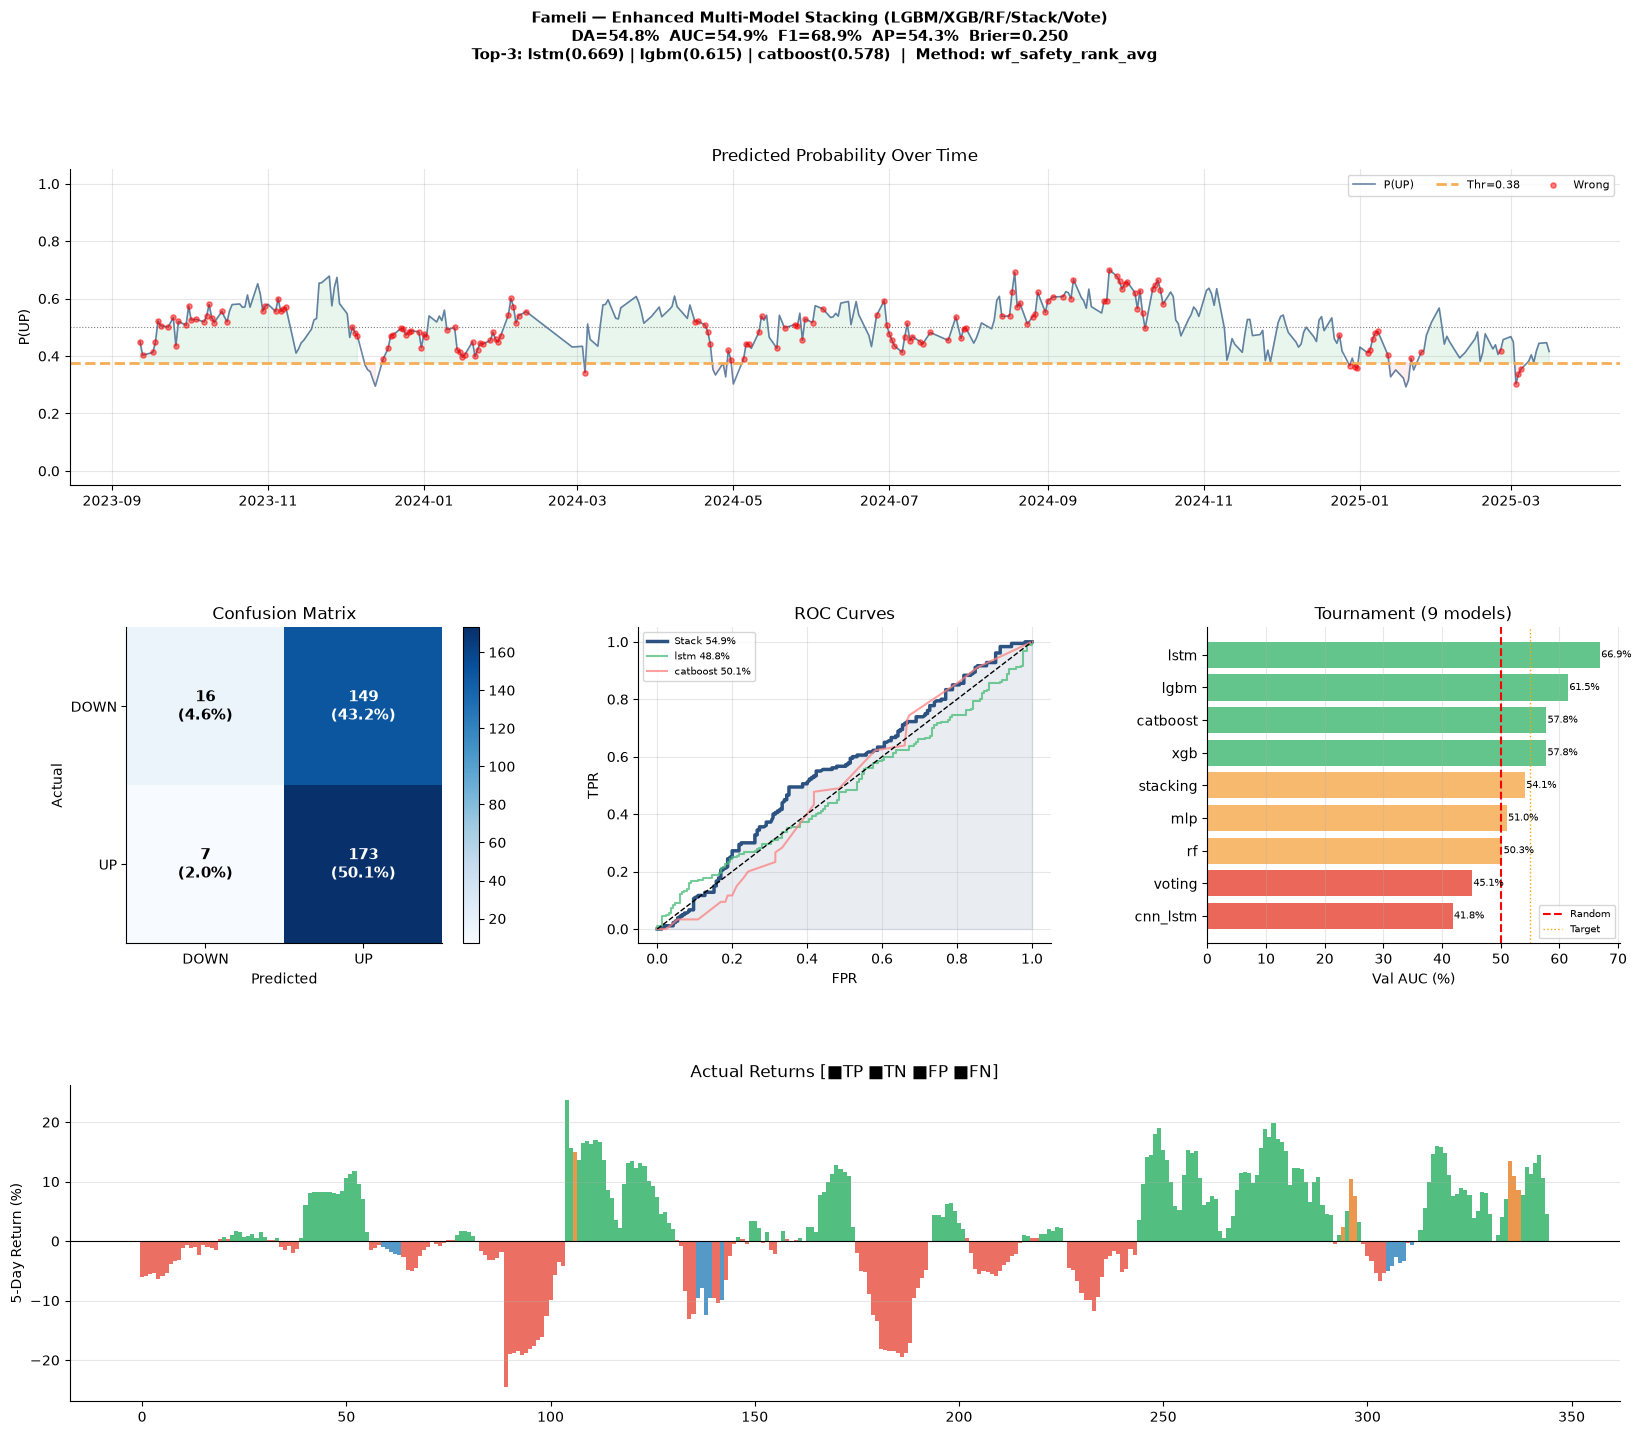

✅ Fameli: نمودارها ذخیره شدند


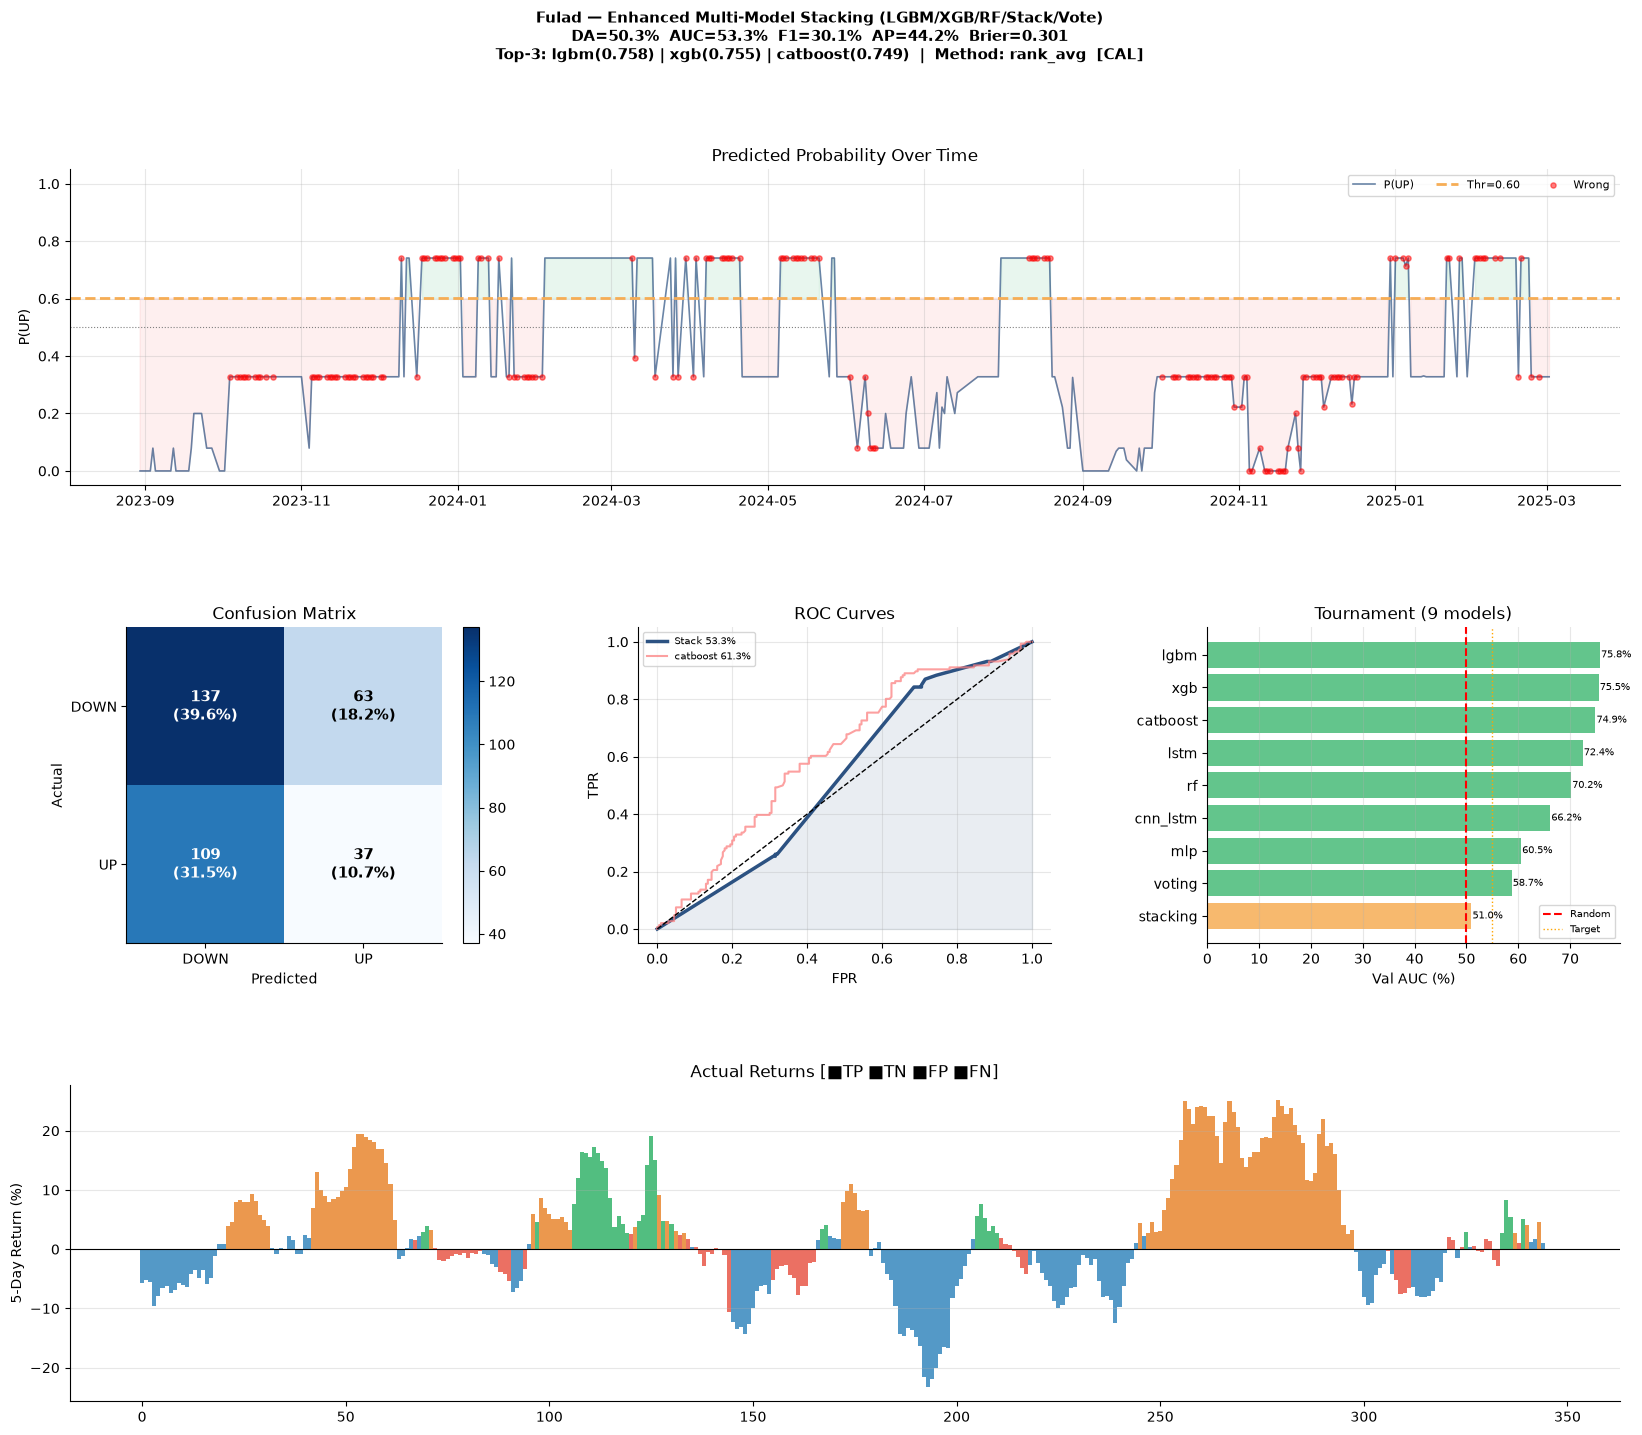

✅ Fulad: نمودارها ذخیره شدند


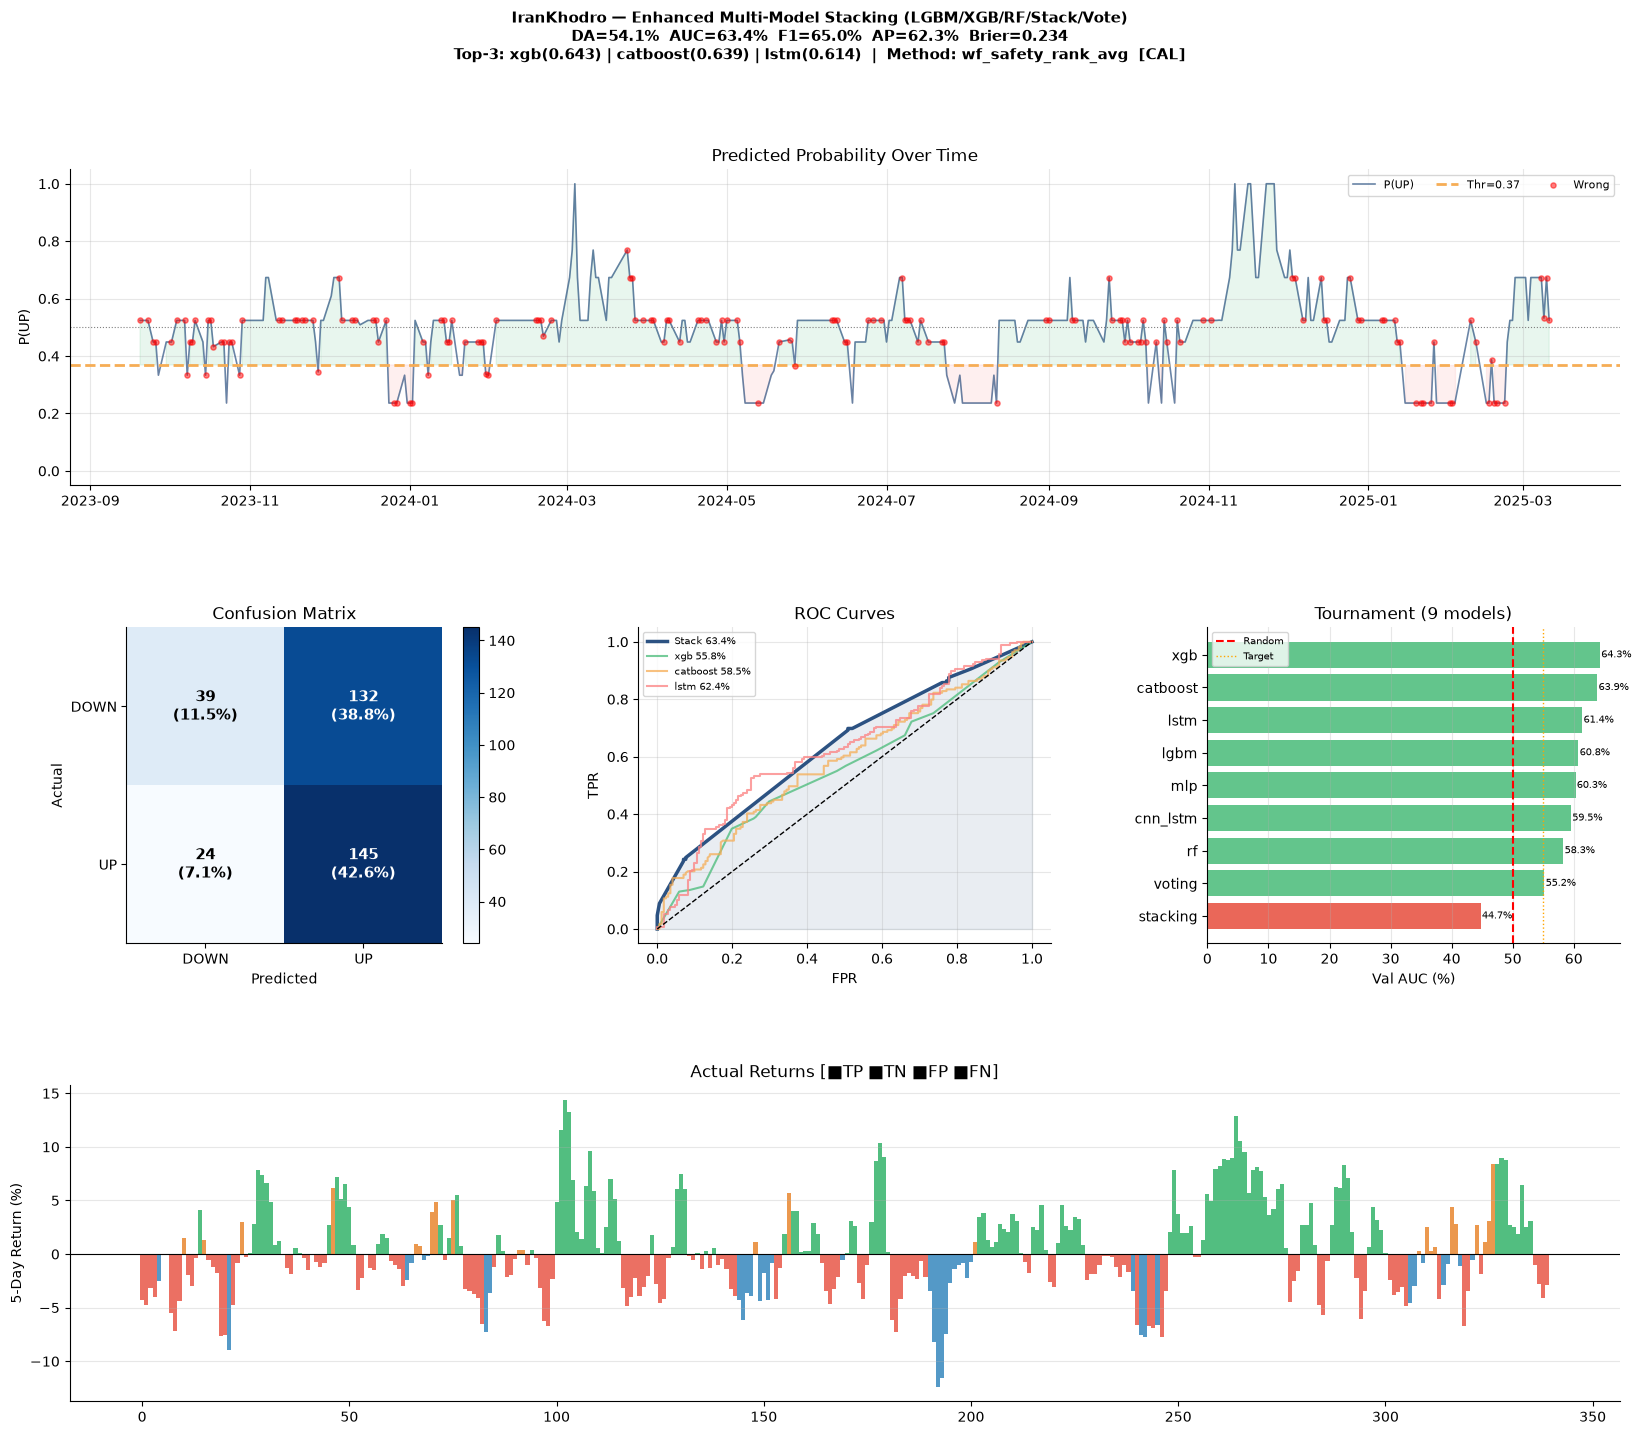

✅ IranKhodro: نمودارها ذخیره شدند


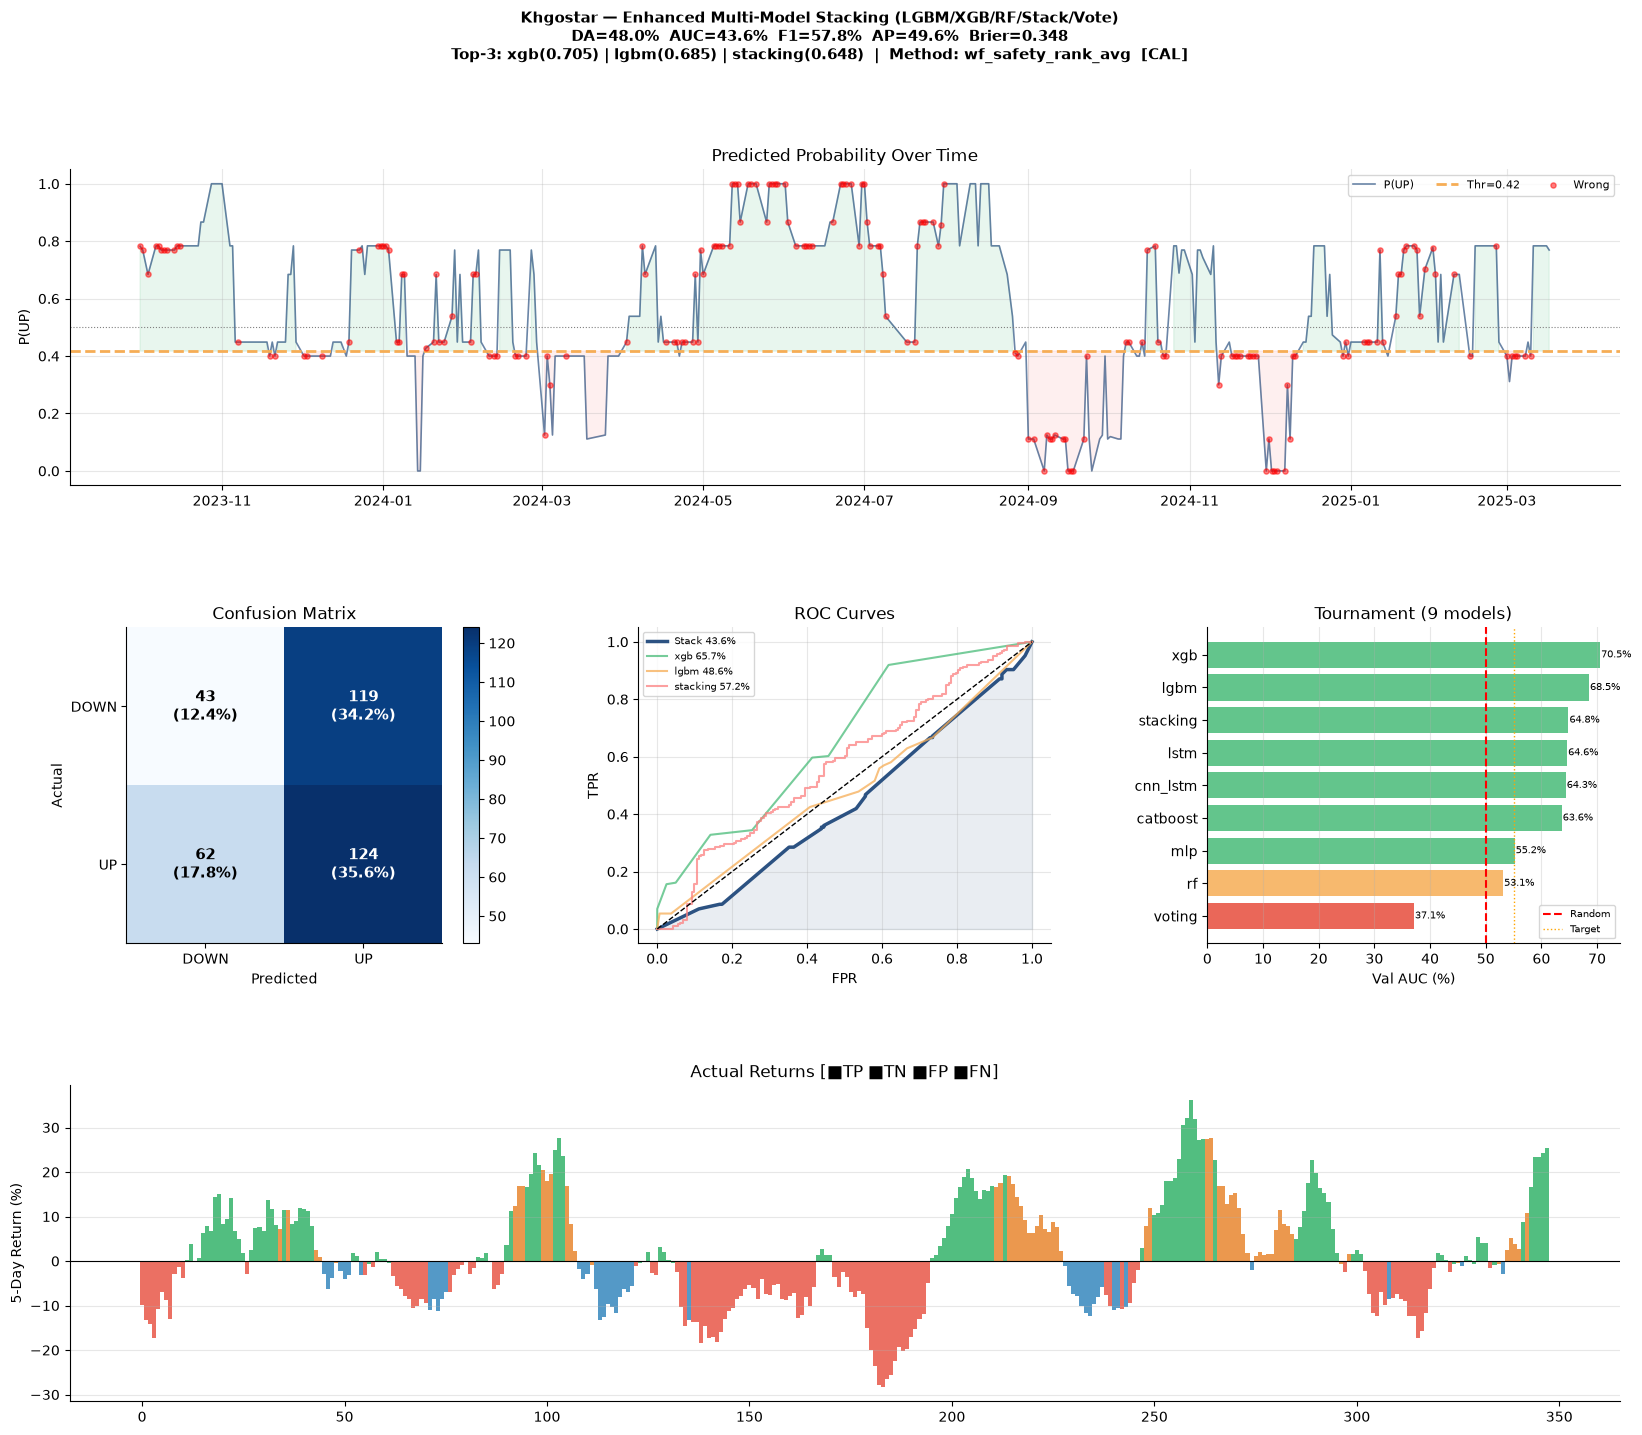

✅ Khgostar: نمودارها ذخیره شدند


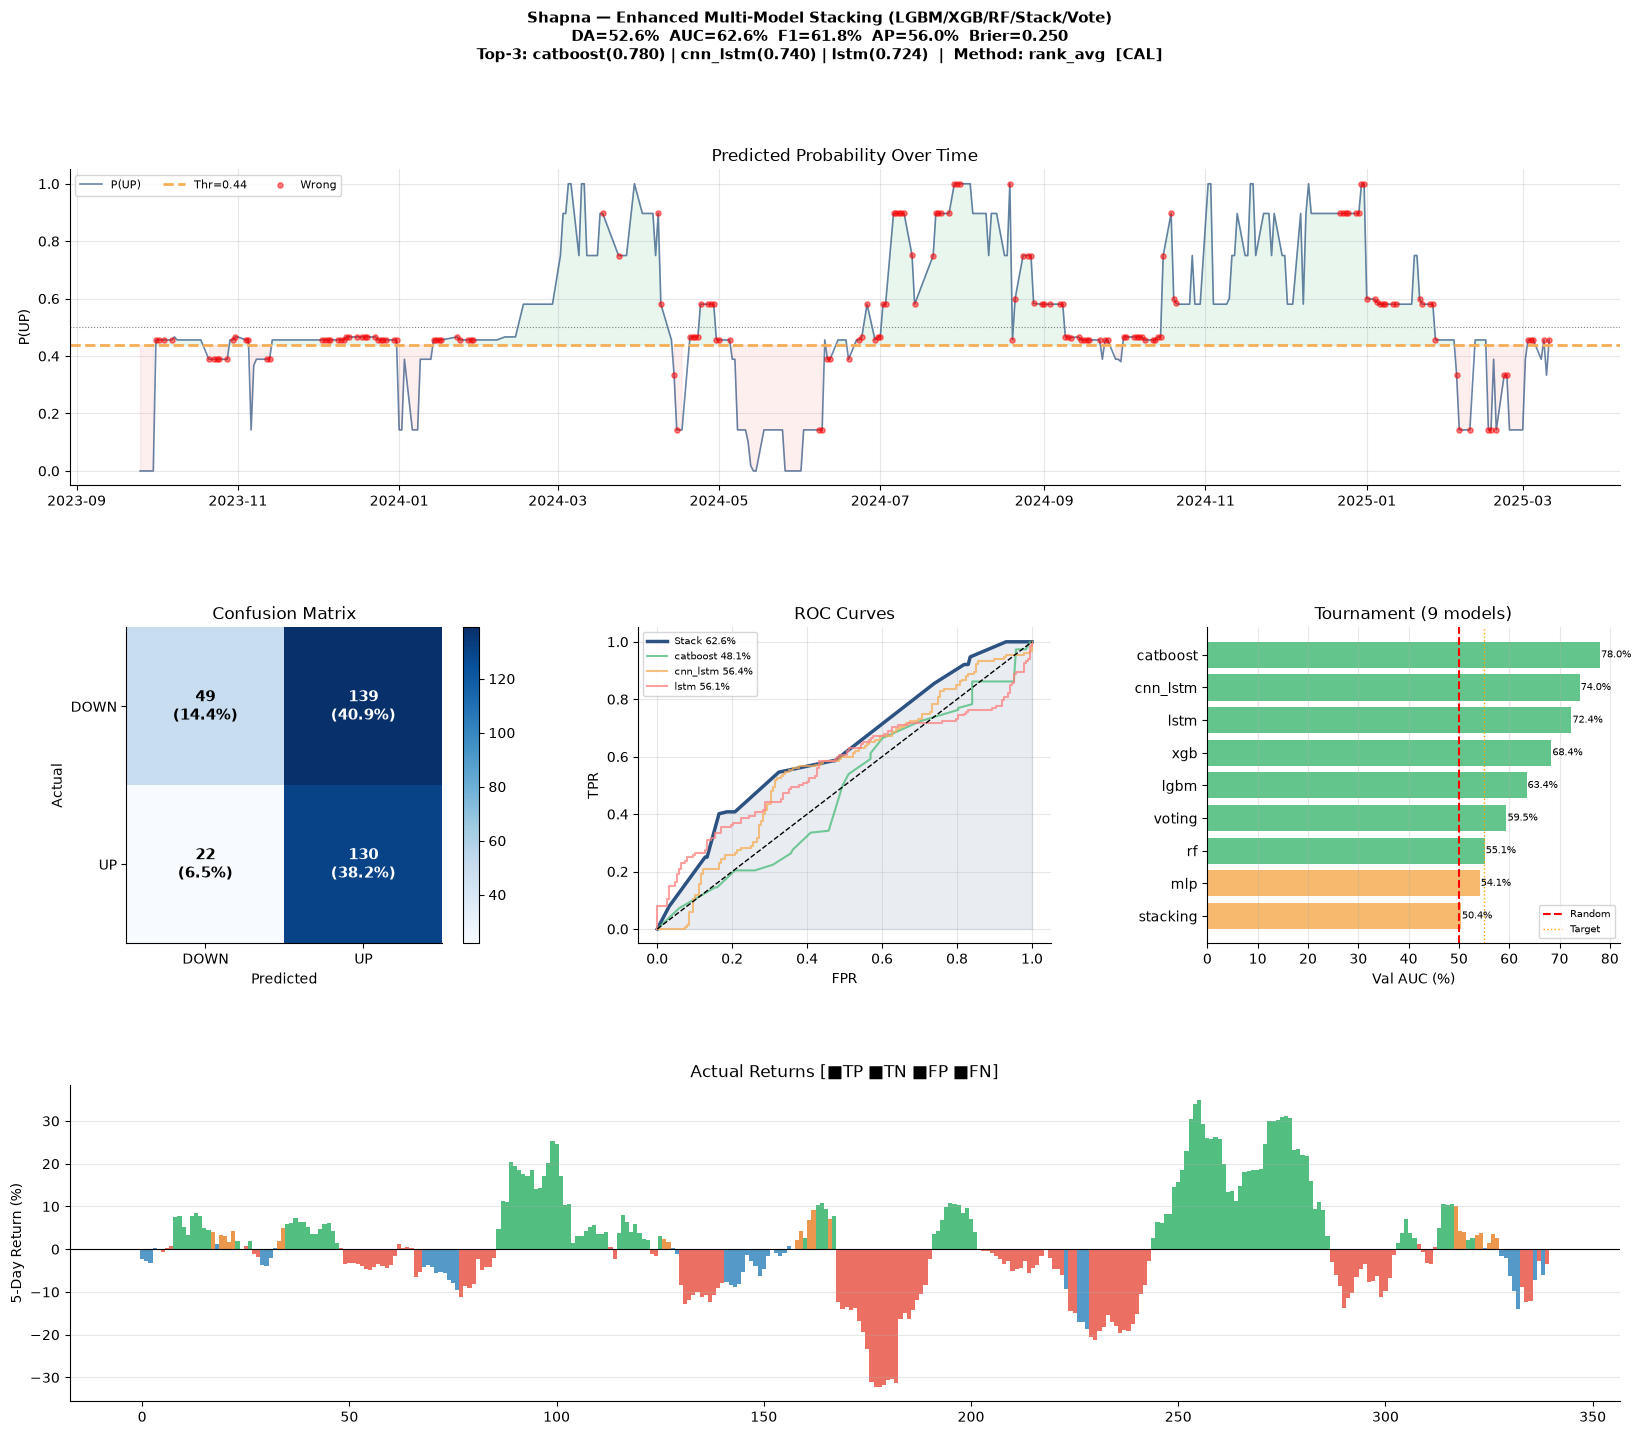

✅ Shapna: نمودارها ذخیره شدند


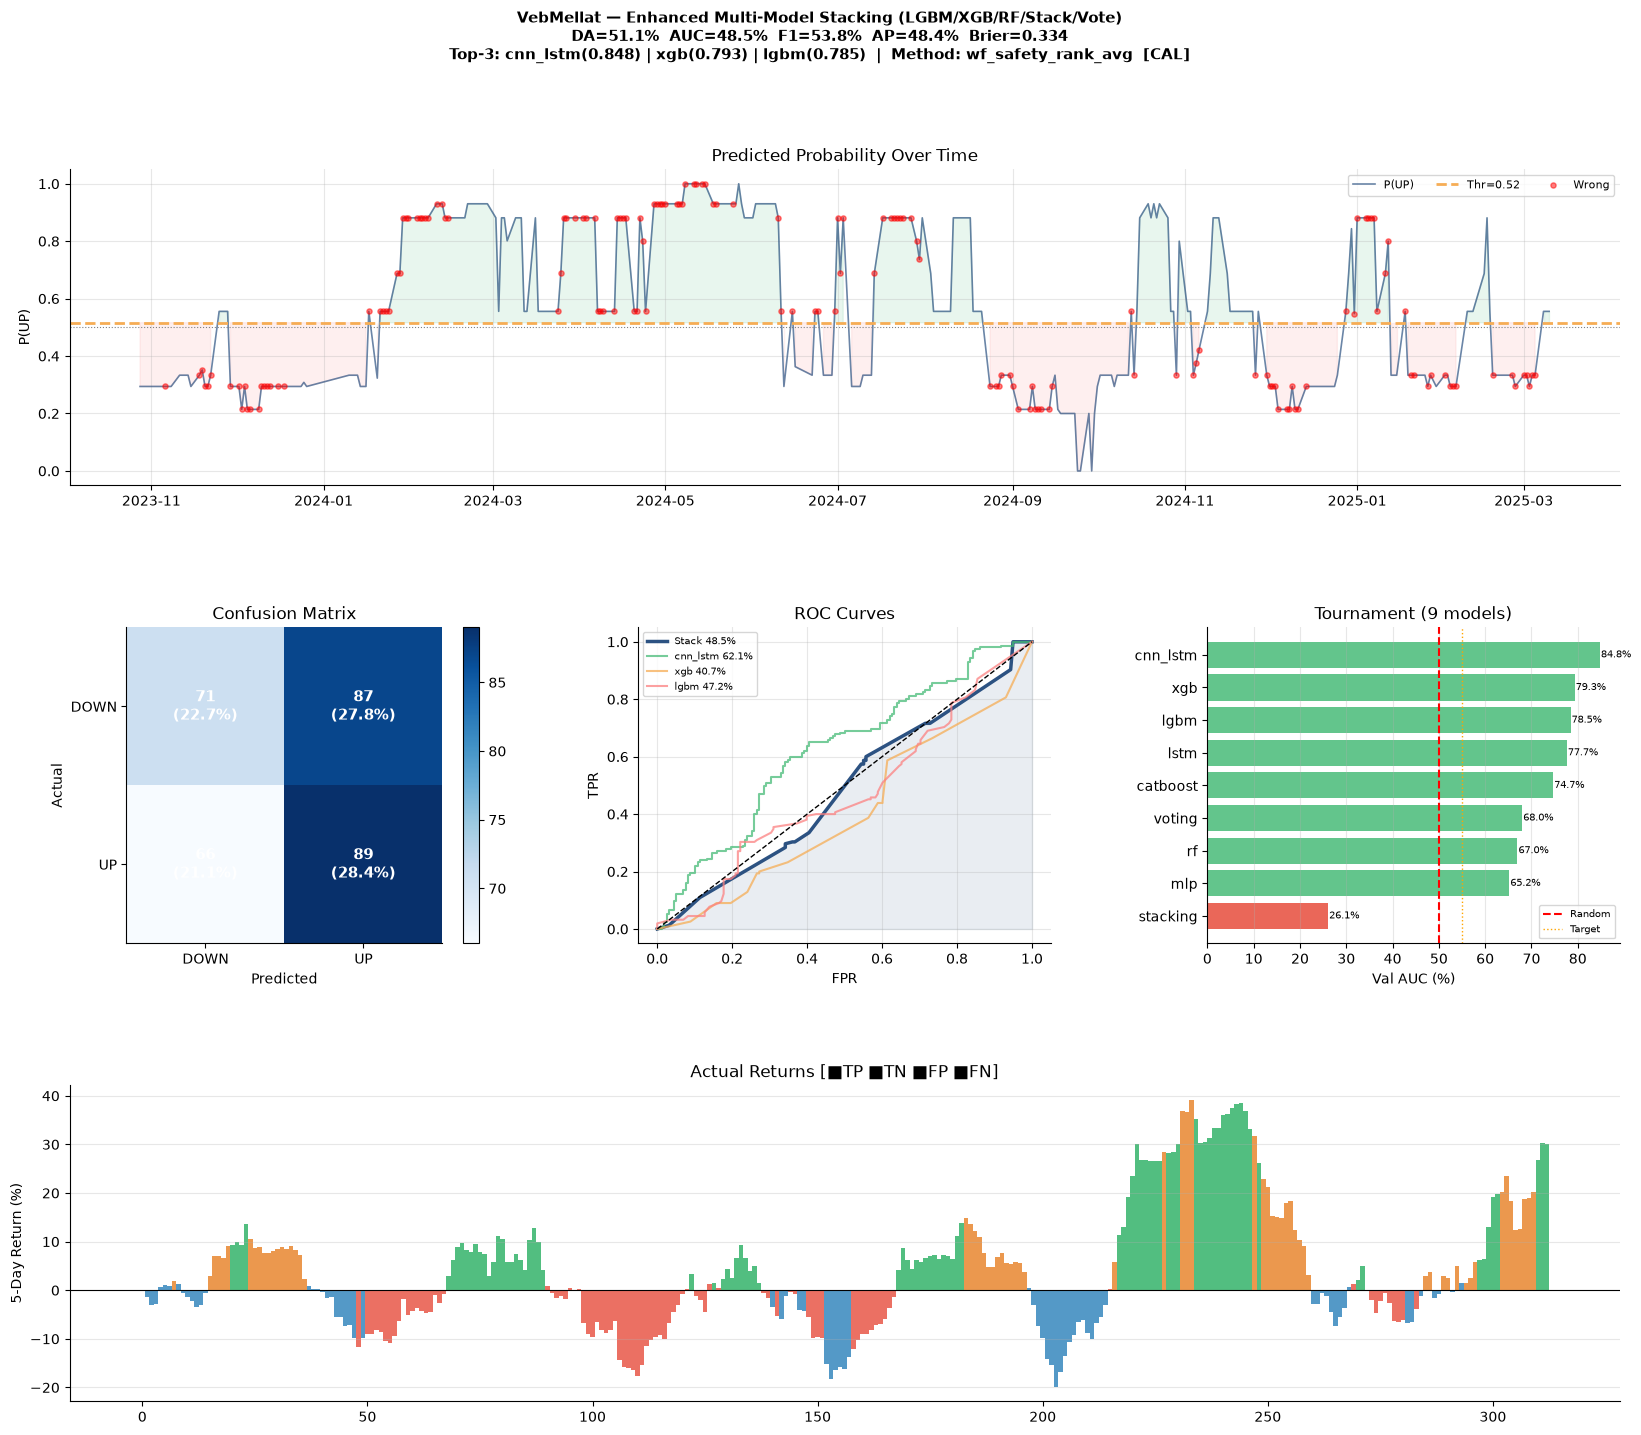

✅ VebMellat: نمودارها ذخیره شدند


In [16]:
SAMPLE_N = 20
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

for name, data in prepared.items():
    res  = all_results[name]
    yte  = res['y_true']; yp   = res['y_pred']
    prob = res['proba'];  dt   = data['dates_test']
    rt   = data['ret_test']

    fig = plt.figure(figsize=(20, 16))
    gs  = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.38)

    top3_str = " | ".join(f"{n}({a:.3f})" for n, a in res['top3'])
    fig.suptitle(
        f"{name} — Enhanced Multi-Model Stacking (LGBM/XGB/RF/Stack/Vote)\n"
        f"DA={res['DA']:.1f}%  AUC={res['AUC']:.1f}%  "
        f"F1={res['F1']:.1f}%  AP={res['AP']:.1f}%  "
        f"Brier={res['Brier']:.3f}\n"
        f"Top-3: {top3_str}  |  "
        f"Method: {res['method']}  "
        f"{'[CAL]' if res['calibrated'] else ''}",
        fontsize=11, fontweight='bold')

    ax1 = fig.add_subplot(gs[0, :])
    correct = yte == yp
    ax1.plot(dt, prob, '#2c5282', lw=1.2, alpha=0.7, label='P(UP)')
    ax1.axhline(res['threshold'], color='#f6ad55', lw=2,
                linestyle='--', label=f"Thr={res['threshold']:.2f}")
    ax1.axhline(0.5, color='gray', lw=0.8, linestyle=':')
    ax1.fill_between(dt, prob, res['threshold'],
                     where=prob >= res['threshold'],
                     alpha=0.12, color='#48bb78')
    ax1.fill_between(dt, prob, res['threshold'],
                     where=prob < res['threshold'],
                     alpha=0.12, color='#fc8181')
    wrong_idx = [i for i in range(len(dt)) if not correct[i]]
    ax1.scatter([dt[i] for i in wrong_idx], prob[wrong_idx],
                s=14, color='red', alpha=0.5, zorder=3, label='Wrong')
    ax1.set_ylabel('P(UP)'); ax1.set_title('Predicted Probability Over Time')
    ax1.legend(fontsize=8, ncol=4); ax1.set_ylim(-0.05, 1.05)
    ax1.grid(True, alpha=0.3)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    ax2 = fig.add_subplot(gs[1, 0])
    cm_v = res['CM']
    im = ax2.imshow(cm_v, cmap='Blues'); plt.colorbar(im, ax=ax2, fraction=0.046)
    for ii in range(2):
        for jj in range(2):
            ax2.text(jj, ii,
                     f"{cm_v[ii,jj]}\n({cm_v[ii,jj]/cm_v.sum()*100:.1f}%)",
                     ha='center', va='center', fontsize=11,
                     color='white' if cm_v[ii,jj] > cm_v.max()/2 else 'black',
                     fontweight='bold')
    ax2.set_xticks([0,1]); ax2.set_yticks([0,1])
    ax2.set_xticklabels(['DOWN','UP']); ax2.set_yticklabels(['DOWN','UP'])
    ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual')
    ax2.set_title('Confusion Matrix')

    ax3 = fig.add_subplot(gs[1, 1])
    fpr, tpr, _ = roc_curve(yte, prob)
    ax3.plot(fpr, tpr, '#2c5282', lw=2.5, label=f"Stack {res['AUC']:.1f}%")
    ax3.fill_between(fpr, tpr, alpha=0.1, color='#2c5282')
    clrs_roc = ['#48bb78','#f6ad55','#fc8181']
    for ci, mn in enumerate(top3_str.split('|')[:3]):
        mn_clean = mn.strip().split('(')[0]
        if mn_clean in all_models[name]:
            p_i = get_proba(all_models[name][mn_clean], mn_clean, data['X_test'])
            if len(np.unique(np.round(p_i, 3))) > 2:
                fi, ti, _ = roc_curve(yte, p_i)
                ai = roc_auc_score(yte, p_i) * 100
                ax3.plot(fi, ti, lw=1.5, alpha=0.75,
                         color=clrs_roc[ci], label=f"{mn_clean} {ai:.1f}%")
    ax3.plot([0,1],[0,1],'k--',lw=1)
    ax3.set_xlabel('FPR'); ax3.set_ylabel('TPR')
    ax3.set_title('ROC Curves')
    ax3.legend(fontsize=7); ax3.grid(True, alpha=0.3)

    ax4 = fig.add_subplot(gs[1, 2])
    t_aucs = tournament_aucs[name]
    s_aucs = sorted(t_aucs.items(), key=lambda x: x[1])
    bar_c  = ['#e74c3c' if a < 0.50 else
               '#f6ad55' if a < 0.55 else '#48bb78'
               for _, a in s_aucs]
    ax4.barh([x[0] for x in s_aucs], [x[1]*100 for x in s_aucs],
             color=bar_c, alpha=0.85)
    ax4.axvline(50, color='red',    lw=1.5, linestyle='--', label='Random')
    ax4.axvline(55, color='orange', lw=1,   linestyle=':',  label='Target')
    ax4.set_xlabel('Val AUC (%)'); ax4.set_title(f'Tournament ({len(s_aucs)} models)')
    ax4.legend(fontsize=7); ax4.grid(True, alpha=0.3, axis='x')
    for i, (mn, ma) in enumerate(s_aucs):
        ax4.text(ma*100+0.2, i, f'{ma*100:.1f}%', va='center', fontsize=7)

    ax5 = fig.add_subplot(gs[2, :])
    clrs = ['#27ae60' if yp1==1 and yt1==1
            else '#2980b9' if yp1==0 and yt1==0
            else '#e74c3c' if yp1==1 and yt1==0
            else '#e67e22'
            for yt1, yp1 in zip(yte, yp)]
    ax5.bar(range(len(rt)), rt*100, color=clrs, alpha=0.8, width=1)
    ax5.axhline(0, color='black', lw=0.8)
    ax5.set_ylabel('5-Day Return (%)')
    ax5.set_title('Actual Returns [■TP ■TN ■FP ■FN]')
    ax5.grid(True, alpha=0.3, axis='y')

    plt.savefig(FP + f'plots/{name}_analysis.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close()
    print(f"✅ {name}: نمودارها ذخیره شدند")

### CELL 10 — SHAP Feature Importance (روی LightGBM از میان مدل‌های تورنومنت)


🔄 SHAP Analysis...


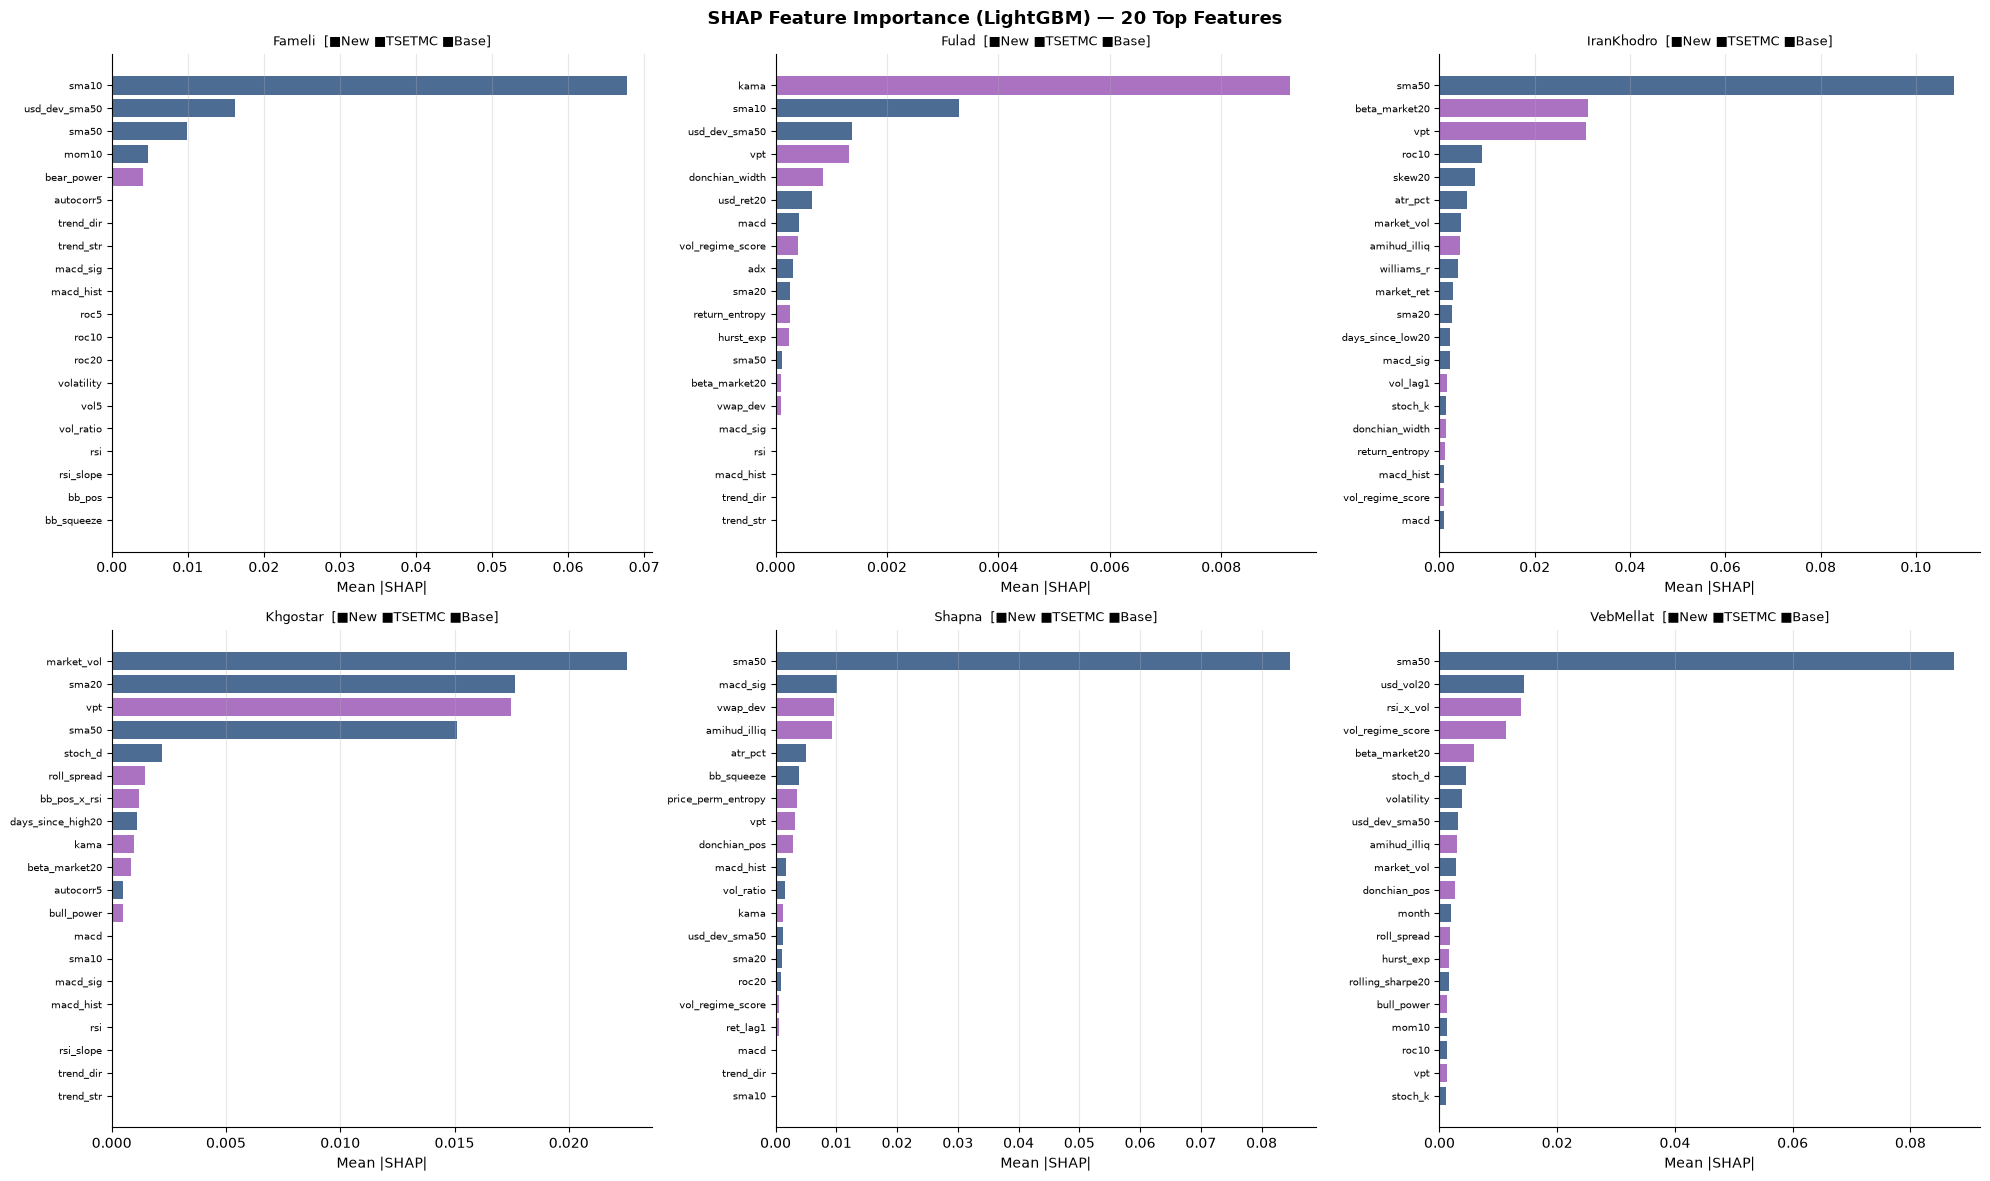


  🏆 Top-20 فیچر مشترک (میانگین SHAP):
    📈 sma50                         : 0.0509
    📈 sma10                         : 0.0119
    🆕 vpt                           : 0.0090
    🆕 beta_market20                 : 0.0063
    📈 market_vol                    : 0.0050
    📈 usd_dev_sma50                 : 0.0037
    📈 sma20                         : 0.0036
    🆕 amihud_illiq                  : 0.0028
    📈 usd_vol20                     : 0.0025
    🆕 rsi_x_vol                     : 0.0023
    🆕 vol_regime_score              : 0.0022
    📈 macd_sig                      : 0.0020
    📈 atr_pct                       : 0.0019
    🆕 kama                          : 0.0019
    📈 roc10                         : 0.0017
    🆕 vwap_dev                      : 0.0016
    📈 skew20                        : 0.0013
    📈 stoch_d                       : 0.0011
    📈 mom10                         : 0.0010
    🆕 donchian_pos                  : 0.0009
✅ SHAP done


In [17]:
import shap as shap_lib

print("\n🔄 SHAP Analysis...")
shap_global = {}

n_assets_plot = len(prepared)
n_cols_plot   = min(3, n_assets_plot)
n_rows_plot   = int(np.ceil(n_assets_plot / n_cols_plot))
fig, axes = plt.subplots(n_rows_plot, n_cols_plot,
                          figsize=(20, 6 * n_rows_plot), squeeze=False)
axes = axes.flatten()

for i, (name, data) in enumerate(prepared.items()):
    lgbm_m = all_models[name]['lgbm']
    ax     = axes[i]
    exp    = shap_lib.TreeExplainer(lgbm_m)
    sv     = exp.shap_values(data['X_test'])
    if isinstance(sv, list): sv = sv[1]

    fi = (pd.Series(np.abs(sv).mean(0), index=FEATURES)
            .sort_values(ascending=False))
    fi.to_csv(FP + f'shap/{name}_shap.csv')
    shap_global[name] = fi

    top  = fi.head(20)
    clrs = []
    for f in top.index:
        if f in FEATURES_ADVANCED:
            clrs.append('#9b59b6')
        elif f in FEATURES_TSETMC:
            clrs.append('#e74c3c')
        else:
            clrs.append('#2c5282')

    ax.barh(range(len(top)), top.values[::-1], color=clrs[::-1], alpha=0.85)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top.index[::-1], fontsize=7)
    ax.set_xlabel('Mean |SHAP|')
    ax.set_title(f'{name}  [■New ■TSETMC ■Base]', fontsize=9)
    ax.grid(True, alpha=0.3, axis='x')

for j in range(n_assets_plot, len(axes)):
    axes[j].axis('off')

plt.suptitle('SHAP Feature Importance (LightGBM) — 20 Top Features',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FP + 'plots/all_shap.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()

all_fi = pd.DataFrame(shap_global).fillna(0)
mean_fi = all_fi.mean(axis=1).sort_values(ascending=False)
print("\n  🏆 Top-20 فیچر مشترک (میانگین SHAP):")
for feat, val in mean_fi.head(20).items():
    cat = "🆕" if feat in FEATURES_ADVANCED else ("📊" if feat in FEATURES_TSETMC else "📈")
    print(f"    {cat} {feat:30s}: {val:.4f}")

print("✅ SHAP done")

### CELL 10.8 — 🆕 v12: آزمایشِ کاهشِ فیچر (Feature Pruning) بر پایهٔ SHAP
این یک آزمایشِ مکمل است، نه جایگزینِ pipeline اصلی — منبعِ رسمیِ گزارش
همچنان CELL 13 (روی همان ۹۶ فیچر) می‌ماند. انگیزه: CELL 8.5 نشان داد
AUC چند سهم در Walk-Forward ناپایدار است؛ فرضیه این است که با ۹۶ فیچر
روی ~۱۶۰۰-۲۳۰۰ ردیفِ آموزشی، مدل‌ها ممکن است overfit کنند. این‌جا فقط
Top-30 فیچر (طبق میانگینِ SHAP از CELL 10 — یعنی هیچ نگاهی به تست/آینده
ندارد) نگه داشته می‌شود، تمامِ ۸ مدل با همان بودجهٔ Optuna از نو تیون
می‌شوند، و پایداریِ Walk-Forward با نسخهٔ کامل مقایسه می‌شود. نتیجه از
قبل معلوم نیست — ممکن است AUC رسمی کمی افت کند در ازای پایداریِ بهتر،
یا حتی هر دو بهتر شوند. هر دو حالت را صادقانه گزارش می‌کنیم.

In [18]:
FEATURE_PRUNE_K = 30
FEATURES_PRUNED = list(mean_fi.head(FEATURE_PRUNE_K).index)

print("\n" + "=" * 70)
print(f"  🆕 FEATURE-PRUNING EXPERIMENT — کاهش فیچر از {len(FEATURES)} به "
      f"{len(FEATURES_PRUNED)} (بر اساس میانگینِ SHAP)")
print("=" * 70)
print("  فیچرهای منتخب:", ", ".join(FEATURES_PRUNED))

pruned_prepared = {}
for name, data in prepared.items():
    H = data['hold_days']   # 🆕 v15: همان افقِ منتخبِ این سهم (برای مقایسهٔ apples-to-apples با نسخهٔ کامل)
    df_full = data['_df_feat_full']
    tr_sl, vl_sl, te_sl = time_split_slices(len(df_full), purge=H)
    tr = df_full.iloc[tr_sl]; vl = df_full.iloc[vl_sl]; te = df_full.iloc[te_sl]
    sc = RobustScaler()
    pruned_prepared[name] = {
        'hold_days': H,
        'X_train': sc.fit_transform(tr[FEATURES_PRUNED]), 'y_train': tr['target'].values,
        'X_val':   sc.transform(vl[FEATURES_PRUNED]),      'y_val':   vl['target'].values,
        'X_test':  sc.transform(te[FEATURES_PRUNED]),      'y_test':  te['target'].values,
        '_df_feat_full': df_full,
    }

pruned_all_models  = {}
pruned_all_results = {}

for name, data in pruned_prepared.items():
    t0 = time.time()
    Xtr, ytr = data['X_train'], data['y_train']
    Xvl, yvl = data['X_val'],   data['y_val']
    sw_tr = recency_weights(len(Xtr))
    mdls = {}; aucs = {}

    lgbm_m, lgbm_a = train_lgbm(Xtr, ytr, Xvl, yvl, n_trials=60, sample_weight_tr=sw_tr)
    mdls['lgbm'] = lgbm_m; aucs['lgbm'] = lgbm_a
    xgb_m, xgb_a = train_xgb(Xtr, ytr, Xvl, yvl, n_trials=40, sample_weight_tr=sw_tr)
    mdls['xgb'] = xgb_m; aucs['xgb'] = xgb_a
    rf_m, rf_a = train_rf(Xtr, ytr, Xvl, yvl, n_trials=30, sample_weight_tr=sw_tr)
    mdls['rf'] = rf_m; aucs['rf'] = rf_a
    cb_m, cb_a = train_catboost(Xtr, ytr, Xvl, yvl, n_trials=40, sample_weight_tr=sw_tr)
    mdls['catboost'] = cb_m; aucs['catboost'] = cb_a
    mlp_m, mlp_a = train_mlp(Xtr, ytr, Xvl, yvl, n_trials=30)
    mdls['mlp'] = mlp_m; aucs['mlp'] = mlp_a
    if _TORCH_OK:
        lstm_m, lstm_a = train_lstm(Xtr, ytr, Xvl, yvl, n_trials=25)
        mdls['lstm'] = lstm_m; aucs['lstm'] = lstm_a
        cnn_lstm_m, cnn_lstm_a = train_cnn_lstm(Xtr, ytr, Xvl, yvl, n_trials=25)
        mdls['cnn_lstm'] = cnn_lstm_m; aucs['cnn_lstm'] = cnn_lstm_a

    top5 = sorted(aucs.items(), key=lambda x: -x[1])[:5]
    base_for_ensemble = [(nm, mdls[nm]) for nm, _ in top5]
    stack_m, stack_a = train_stacking(Xtr, ytr, Xvl, yvl, base_for_ensemble)
    mdls['stacking'] = stack_m; aucs['stacking'] = stack_a
    vote_m, vote_a = train_voting(Xtr, ytr, Xvl, yvl, base_for_ensemble)
    mdls['voting'] = vote_m; aucs['voting'] = vote_a

    best_name = max(aucs, key=aucs.get)
    Xte, yte  = data['X_test'], data['y_test']
    test_auc  = roc_auc_score(yte, mdls[best_name].predict_proba(Xte)[:, 1])
    pruned_all_models[name]  = mdls
    pruned_all_results[name] = {'best_name': best_name, 'val_auc': aucs[best_name],
                                 'test_auc': test_auc}
    print(f"  {name:12s} [{best_name:10s}]  Val AUC={aucs[best_name]:.4f}  "
          f"Test AUC={test_auc:.4f}  ({time.time()-t0:.0f}s)")

print("\n  🆕 Walk-Forward روی فیچرِ کاهش‌یافته:")
pruned_walk_forward = {}
for name, data in pruned_prepared.items():
    champion_name  = pruned_all_results[name]['best_name']
    champion_model = pruned_all_models[name].get(champion_name)
    if champion_model is None or champion_name in ('stacking', 'voting'):
        print(f"    {name:12s}: مدلِ برتر ({champion_name}) مرکب است — رد شد")
        continue
    H_stock = data['hold_days']   # 🆕 v15
    df_full = data['_df_feat_full']
    tscv = TimeSeriesSplit(n_splits=WF_N_SPLITS)
    fold_aucs = []
    for tr_idx, te_idx in tscv.split(df_full):
        if len(tr_idx) <= H_stock:
            continue
        tr_fold = df_full.iloc[tr_idx[:-H_stock]]
        te_fold = df_full.iloc[te_idx]
        if tr_fold['target'].nunique() < 2 or te_fold['target'].nunique() < 2:
            continue
        try:
            sc_fold = RobustScaler().fit(tr_fold[FEATURES_PRUNED])
            Xtr_f = sc_fold.transform(tr_fold[FEATURES_PRUNED])
            Xte_f = sc_fold.transform(te_fold[FEATURES_PRUNED])
            m_fold = clone_for_refit(champion_model)
            m_fold.fit(Xtr_f, tr_fold['target'].values)
            p_fold = m_fold.predict_proba(Xte_f)[:, 1]
            fold_aucs.append(roc_auc_score(te_fold['target'].values, p_fold))
        except Exception as e:
            print(f"      ⚠️ {name} یک foldِ walk-forward ناموفق بود: {e}")
    if fold_aucs:
        pruned_walk_forward[name] = fold_aucs
        print(f"    {name:12s} [{champion_name:10s}]  WF AUC = "
              f"{np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")
    else:
        print(f"    {name:12s}: هیچ foldِ معتبری به‌دست نیامد")

# 🆕 مقایسهٔ منصفانه: هر دو ستون از AUC خامِ مدلِ برترِ CELL 7-مانند
# استفاده می‌کنند (نه خروجیِ کالیبره‌شده/استک‌شدهٔ CELL 8) تا مقایسه
# دقیقاً apples-to-apples بماند.
def _raw_test_auc(model, Xte, yte):
    return roc_auc_score(yte, model.predict_proba(Xte)[:, 1])

print("\n" + "=" * 70)
print(f"  📊 مقایسهٔ فیچرِ کامل ({len(FEATURES)}) در برابر فیچرِ کاهش‌یافته "
      f"({len(FEATURES_PRUNED)})")
print("=" * 70)
comp_rows = []
for name in prepared:
    full_champ_name = best_model_info[name][0][0]
    full_champ      = all_models[name][full_champ_name]
    full_val_auc    = best_model_info[name][0][1]
    full_test_auc   = _raw_test_auc(full_champ, prepared[name]['X_test'], prepared[name]['y_test'])
    full_wf         = np.mean(walk_forward_results[name]) if name in walk_forward_results else np.nan
    full_wf_std     = np.std(walk_forward_results[name]) if name in walk_forward_results else np.nan

    pr = pruned_all_results[name]
    pruned_champ    = pruned_all_models[name][pr['best_name']]
    pruned_test_auc = _raw_test_auc(pruned_champ, pruned_prepared[name]['X_test'], pruned_prepared[name]['y_test'])
    pruned_wf       = np.mean(pruned_walk_forward[name]) if name in pruned_walk_forward else np.nan
    pruned_wf_std   = np.std(pruned_walk_forward[name]) if name in pruned_walk_forward else np.nan

    comp_rows.append({
        'Asset': name,
        f'Full({len(FEATURES)}) Val AUC': round(full_val_auc, 4),
        f'Full({len(FEATURES)}) Test AUC': round(full_test_auc, 4),
        f'Full({len(FEATURES)}) WF AUC': round(full_wf, 4) if not np.isnan(full_wf) else np.nan,
        f'Full({len(FEATURES)}) WF Std': round(full_wf_std, 4) if not np.isnan(full_wf_std) else np.nan,
        f'Pruned({len(FEATURES_PRUNED)}) Val AUC': round(pr['val_auc'], 4),
        f'Pruned({len(FEATURES_PRUNED)}) Test AUC': round(pruned_test_auc, 4),
        f'Pruned({len(FEATURES_PRUNED)}) WF AUC': round(pruned_wf, 4) if not np.isnan(pruned_wf) else np.nan,
        f'Pruned({len(FEATURES_PRUNED)}) WF Std': round(pruned_wf_std, 4) if not np.isnan(pruned_wf_std) else np.nan,
    })
comp_df = pd.DataFrame(comp_rows).set_index('Asset')
print(comp_df.to_string())
comp_df.to_csv(FP + 'feature_pruning_comparison.csv')

n_wf_improved = sum(
    1 for name in prepared
    if name in walk_forward_results and name in pruned_walk_forward
    and np.std(pruned_walk_forward[name]) < np.std(walk_forward_results[name])
)
print(f"\n  ℹ️ پایداریِ Walk-Forward (انحرافِ‌معیارِ کمتر) در "
      f"{n_wf_improved} از {len(walk_forward_results)} سهم با فیچرِ "
      f"کاهش‌یافته بهتر شد. این یک آزمایشِ صادقانه است — اگر نتیجه بهتر "
      f"نشود هم در فایل ذخیره و گزارش می‌شود، نه فقط وقتی بهتر شود.")


  🆕 FEATURE-PRUNING EXPERIMENT — کاهش فیچر از 100 به 30 (بر اساس میانگینِ SHAP)
  فیچرهای منتخب: sma50, sma10, vpt, beta_market20, market_vol, usd_dev_sma50, sma20, amihud_illiq, usd_vol20, rsi_x_vol, vol_regime_score, macd_sig, atr_pct, kama, roc10, vwap_dev, skew20, stoch_d, mom10, donchian_pos, volatility, bear_power, bb_squeeze, williams_r, price_perm_entropy, macd_hist, roll_spread, market_ret, stoch_k, donchian_width


/tmp/claude-0/-home-user/203660ab-8ddd-5267-a1b0-02829feee8f4/scratchpad/venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/tmp/claude-0/-home-user/203660ab-8ddd-5267-a1b0-02829feee8f4/scratchpad/venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/tmp/claude-0/-home-user/203660ab-8ddd-5267-a1b0-02829feee8f4/scratchpad/venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate t

  Fameli       [catboost  ]  Val AUC=0.6334  Test AUC=0.5379  (1155s)


  Fulad        [catboost  ]  Val AUC=0.7832  Test AUC=0.3921  (1376s)


  IranKhodro   [xgb       ]  Val AUC=0.6621  Test AUC=0.6568  (1685s)


...

    Fulad        [catboost  ]  WF AUC = 0.5249 ± 0.1512


    IranKhodro   [xgb       ]  WF AUC = 0.5182 ± 0.0470


    Khgostar     [catboost  ]  WF AUC = 0.4608 ± 0.0065


    Shapna       [catboost  ]  WF AUC = 0.5689 ± 0.0544


    VebMellat    [xgb       ]  WF AUC = 0.5515 ± 0.0376

  📊 مقایسهٔ فیچرِ کامل (100) در برابر فیچرِ کاهش‌یافته (30)
            Full(100) Val AUC  Full(100) Test AUC  Full(100) WF AUC  Full(100) WF Std  Pruned(30) Val AUC  Pruned(30) Test AUC  Pruned(30) WF AUC  Pruned(30) WF Std
Asset                                                                                                                                                               
Fameli                 0.6692              0.4879            0.4724            0.0347              0.6334               0.5379             0.5553             0.0579
Fulad                  0.7576              0.5005            0.5338            0.0569              0.7832               0.3921             0.5249             0.1512
IranKhodro             0.6429              0.5584            0.4932            0.0364              0.6621               0.6568             0.5182             0.0470
Khgostar               0.7052              0.6575         

### CELL 10.5 — قیمت‌گذاری بلک-شولز و VaR/CVaR

In [19]:
from scipy.stats import norm

RISK_FREE_RATE   = 0.20
OPTION_HOLD_DAYS = HOLD_DAYS
TRADING_DAYS     = 252

TRANS_COST  = 0.005
PREMIUM_PCT = 0.008
STRIKE_PCT  = 0.04


def bs_call_price(S, K, T, r, sigma):
    S = np.asarray(S, dtype=float)
    sigma = np.maximum(np.asarray(sigma, dtype=float), 1e-4)
    T = max(T, 1e-6)
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return np.maximum(price, 0.0)


def bs_fair_premium_pct(daily_vol, strike_pct=None, T_days=OPTION_HOLD_DAYS,
                         r=RISK_FREE_RATE):
    strike_pct = STRIKE_PCT if strike_pct is None else strike_pct
    sigma_ann = np.asarray(daily_vol, dtype=float) * np.sqrt(TRADING_DAYS)
    T = T_days / TRADING_DAYS
    K = 1.0 + strike_pct
    return bs_call_price(1.0, K, T, r, sigma_ann)


def historical_var_cvar(returns, alpha=0.05):
    r = np.asarray(returns, dtype=float)
    r = r[~np.isnan(r)]
    if len(r) == 0:
        return 0.0, 0.0
    var = -np.percentile(r, alpha * 100)
    tail = r[r <= -var]
    cvar = -tail.mean() if len(tail) > 0 else var
    return float(var), float(cvar)


def parametric_var(returns, alpha=0.05):
    r = np.asarray(returns, dtype=float)
    r = r[~np.isnan(r)]
    if len(r) == 0:
        return 0.0
    mu, sigma = r.mean(), r.std()
    z = norm.ppf(alpha)
    return float(-(mu + z * sigma))


risk_metrics = {}
print("\n📐 محاسبه VaR / CVaR و پرمیوم تعادلی بلک-شولز برای هر سهم...\n")
for name, data in prepared.items():
    ret_test = data['ret_test']
    # 🆕 v7: نوسانِ واقعیِ روزانهٔ هر روزِ تست (رفعِ باگ dead-lookup قبلی)
    vol_test = data['volatility_test']
    H = data['hold_days']   # 🆕 v15: افقِ خودِ این سهم

    var_h, cvar_h = historical_var_cvar(ret_test, alpha=0.05)
    var_p = parametric_var(ret_test, alpha=0.05)
    bs_prem_mean = float(np.mean(
        bs_fair_premium_pct(np.std(ret_test) / np.sqrt(H), T_days=H)))

    risk_metrics[name] = {
        'VaR_hist_95 (%)':  round(var_h  * 100, 2),
        'CVaR_hist_95 (%)': round(cvar_h * 100, 2),
        'VaR_param_95 (%)': round(var_p  * 100, 2),
        'BS_fair_premium (%)': round(bs_prem_mean * 100, 2),
        'Market_premium (%)':  round(PREMIUM_PCT * 100, 2),
    }
    print(f"  {name:12s}  VaR95={var_h*100:5.2f}%  CVaR95={cvar_h*100:5.2f}%  "
          f"ParamVaR95={var_p*100:5.2f}%  BS_fair_premium={bs_prem_mean*100:5.2f}%")

print("\n✅ VaR/CVaR و قیمت تعادلی بلک-شولز محاسبه شد")


📐 محاسبه VaR / CVaR و پرمیوم تعادلی بلک-شولز برای هر سهم...

  Fameli        VaR95=15.58%  CVaR95=18.60%  ParamVaR95=12.51%  BS_fair_premium= 2.27%
  Fulad         VaR95=12.46%  CVaR95=16.17%  ParamVaR95=13.57%  BS_fair_premium= 2.83%
  IranKhodro    VaR95= 6.66%  CVaR95= 7.96%  ParamVaR95= 6.82%  BS_fair_premium= 0.49%
  Khgostar      VaR95=15.93%  CVaR95=20.69%  ParamVaR95=18.37%  BS_fair_premium= 3.52%
  Shapna        VaR95=17.94%  CVaR95=24.55%  ParamVaR95=19.16%  BS_fair_premium= 3.60%
  VebMellat     VaR95=13.64%  CVaR95=16.09%  ParamVaR95=16.87%  BS_fair_premium= 3.97%

✅ VaR/CVaR و قیمت تعادلی بلک-شولز محاسبه شد


### CELL 11 — Backtest پیشرفته
🆕 v10: بازطراحیِ منطق پوزیشن‌گیری تا واقعاً یک استراتژیِ Covered
Call منصفانه‌قابل‌مقایسه با Buy&Hold باشد — نه یک استراتژیِ
market-timing با روکشِ آپشن. دو مشکل ساختاریِ نسخهٔ قبلی که باعث
می‌شد CC تقریباً همیشه از BnH عقب بماند (حتی وقتی جهتِ پیش‌بینی مدل
درست بود) این‌جا رفع شده‌اند:
  ۱) اندازهٔ پوزیشنِ سهام قبلاً با اطمینانِ مدل کوچک/بزرگ می‌شد
     (`pos_raw = edge*4`) و در حالتِ نزولی کاملاً به CASH می‌رفت —
     یعنی استراتژی اغلب فقط ۱۰-۴۰٪ در بازار بود، در حالی که BnH
     همیشه ۱۰۰٪ است. این مقایسه را از پایه ناعادلانه می‌کرد.
     صندوق‌های واقعیِ Covered-Call (JEPI/QYLD و مشابه) همیشه در
     سهامِ پایه به‌طور کامل سرمایه‌گذاری‌اند؛ overlay فقط تصمیم به
     فروش/عدم‌فروش کال است، نه اندازهٔ پوزیشنِ سهام. اکنون پوزیشنِ
     سهام همیشه ۱۰۰٪ است و تنها «وزنِ فروشِ کال» (`call_weight`)
     با اطمینانِ مدل تغییر می‌کند.
  ۲) 🆕 گیتِ روند: وقتی سیگنالِ روندِ صعودیِ قویِ بدونِ‌نگاه‌به‌آینده
     (`bull_trend` — از sma/adx/مومنتومِ چند-تایم‌فریمِ تا لحظهٔ t)
     فعال است، اصلاً کال فروخته نمی‌شود تا سقفِ سود در بحبوحهٔ یک
     رالیِ قوی نیفتد — دقیقاً کاری که دسک‌های Buy-Write واقعی هم
     می‌کنند.
هیچ‌کدام از این تغییرات به قیمت‌های آینده یا برچسبِ target نگاه
نمی‌کنند؛ فقط منطقِ خودِ استراتژی (نه مدل) واقع‌بینانه‌تر شده است.


🔄 Backtest پیشرفته...

=======================================================  Fameli
  conf_high=0.52  conf_low=0.46
  CC: +41124.3%  BnH: +7424.6%
  Sharpe=1.10  Sortino=2.40  Calmar=441.34
  WinRate=56.2%  MaxDD=-93.2%  CallWritten=19.4%
  VaR95=15.58%  CVaR95=18.60%  روزهای مجاز فروش کال طبق بلک-شولز=27.8%
  Actions: {'STOCK_ONLY': 219, 'COVERED_CALL': 61, 'STOCK_ONLY_TREND': 59, 'PARTIAL_CC': 6}



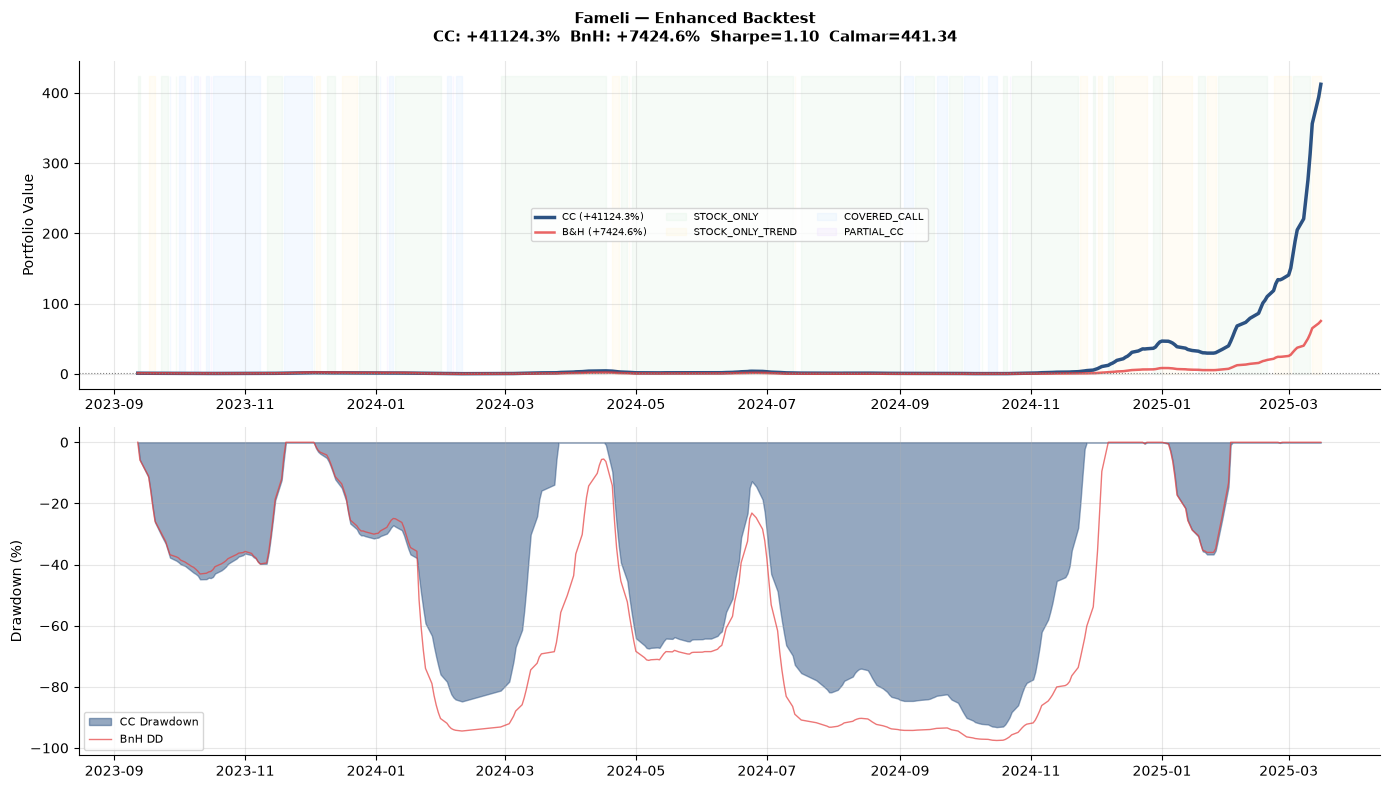

=======================================================  Fulad
  conf_high=0.54  conf_low=0.45
  CC: +93234.0%  BnH: +59600.7%
  Sharpe=0.95  Sortino=2.57  Calmar=951.41
  WinRate=54.6%  MaxDD=-98.0%  CallWritten=4.0%
  VaR95=12.46%  CVaR95=16.17%  روزهای مجاز فروش کال طبق بلک-شولز=11.0%
  Actions: {'STOCK_ONLY': 276, 'STOCK_ONLY_TREND': 56, 'COVERED_CALL': 14}



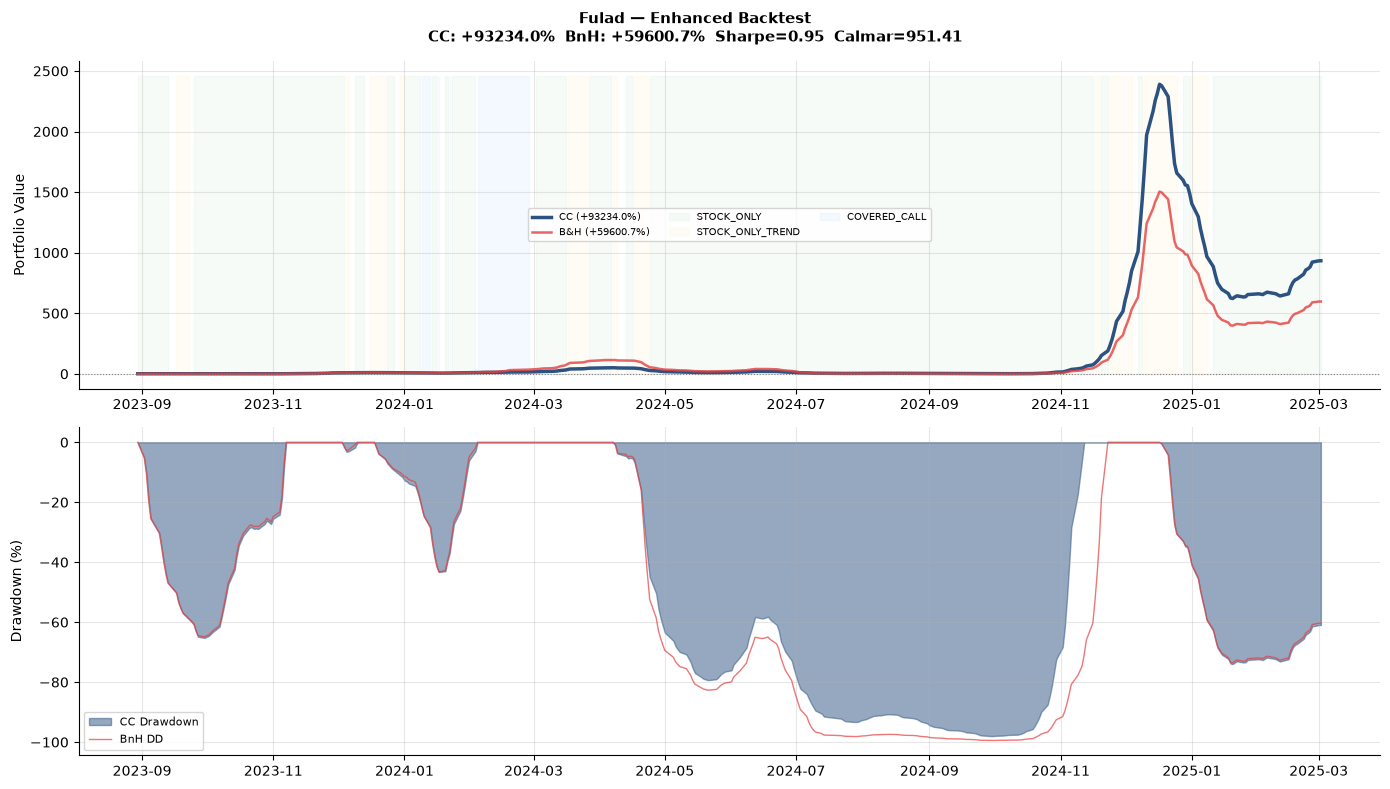

=======================================================  IranKhodro
  conf_high=0.53  conf_low=0.48
  CC: -7.3%  BnH: +122.2%
  Sharpe=0.13  Sortino=0.24  Calmar=-0.09
  WinRate=48.5%  MaxDD=-78.7%  CallWritten=47.6%
  VaR95=6.66%  CVaR95=7.96%  روزهای مجاز فروش کال طبق بلک-شولز=100.0%
  Actions: {'STOCK_ONLY': 134, 'PARTIAL_CC': 128, 'STOCK_ONLY_TREND': 44, 'COVERED_CALL': 34}



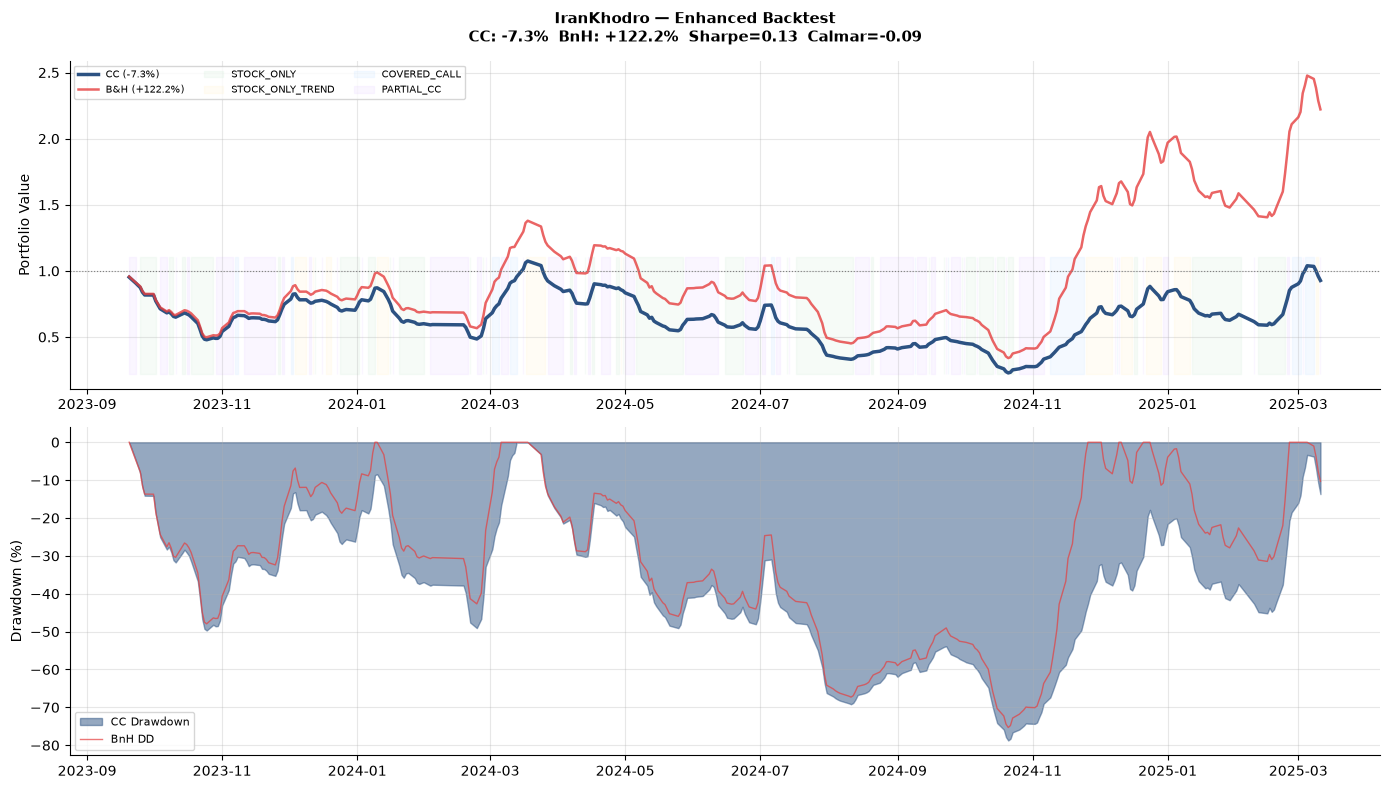

=======================================================  Khgostar
  conf_high=0.52  conf_low=0.48
  CC: +8847.4%  BnH: +266.6%
  Sharpe=0.70  Sortino=2.15  Calmar=88.68
  WinRate=48.6%  MaxDD=-99.8%  CallWritten=0.0%
  VaR95=15.93%  CVaR95=20.69%  روزهای مجاز فروش کال طبق بلک-شولز=0.6%
  Actions: {'STOCK_ONLY': 297, 'STOCK_ONLY_TREND': 51}



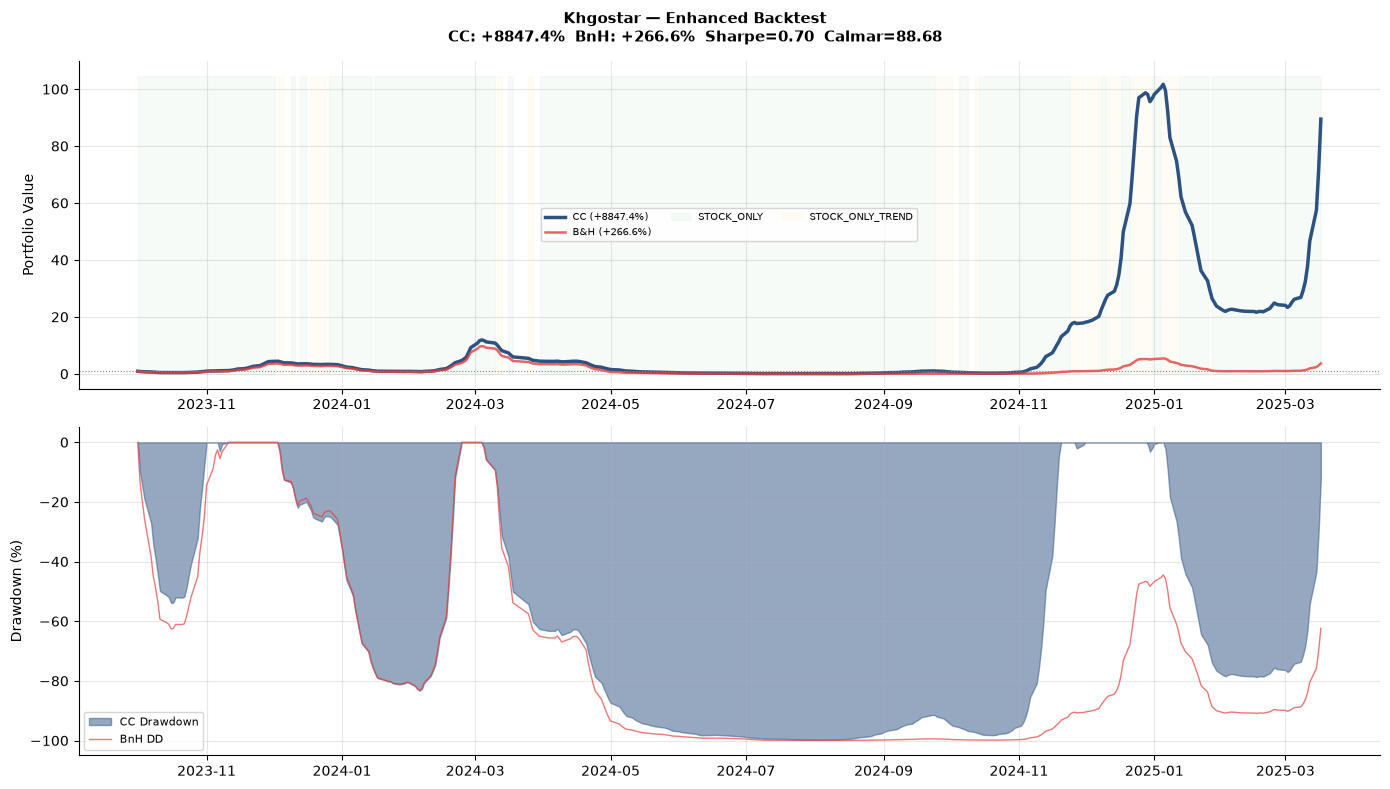

=======================================================  Shapna
  conf_high=0.52  conf_low=0.36
  CC: +5748.3%  BnH: -31.5%
  Sharpe=0.68  Sortino=2.06  Calmar=57.76
  WinRate=50.3%  MaxDD=-99.5%  CallWritten=0.9%
  VaR95=17.94%  CVaR95=24.55%  روزهای مجاز فروش کال طبق بلک-شولز=15.0%
  Actions: {'STOCK_ONLY': 295, 'STOCK_ONLY_TREND': 42, 'COVERED_CALL': 3}



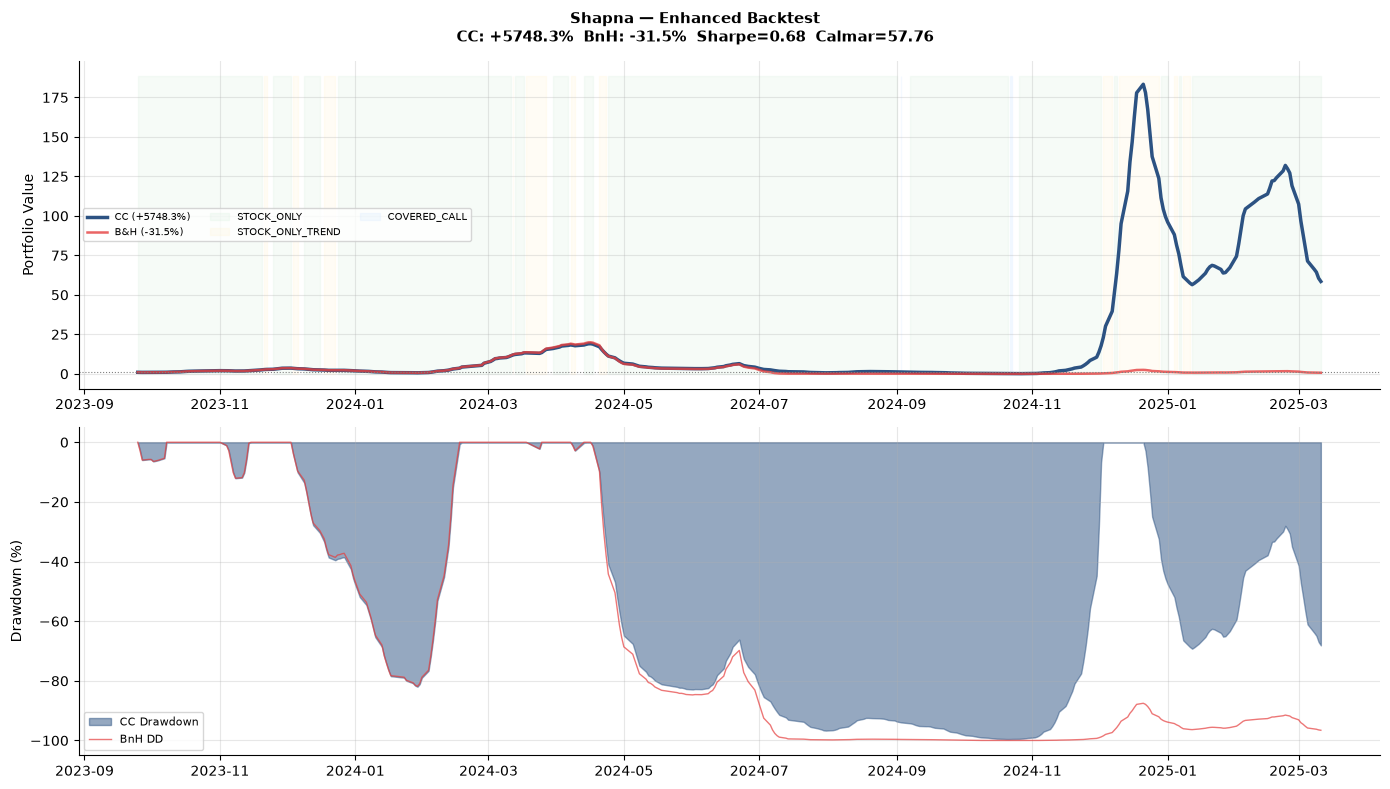

=======================================================  VebMellat
  conf_high=0.59  conf_low=0.48
  CC: +3817510.2%  BnH: +1318144.1%
  Sharpe=1.20  Sortino=4.18  Calmar=38997.19
  WinRate=55.9%  MaxDD=-97.9%  CallWritten=3.5%
  VaR95=13.64%  CVaR95=16.09%  روزهای مجاز فروش کال طبق بلک-شولز=3.5%
  Actions: {'STOCK_ONLY': 253, 'STOCK_ONLY_TREND': 49, 'COVERED_CALL': 11}



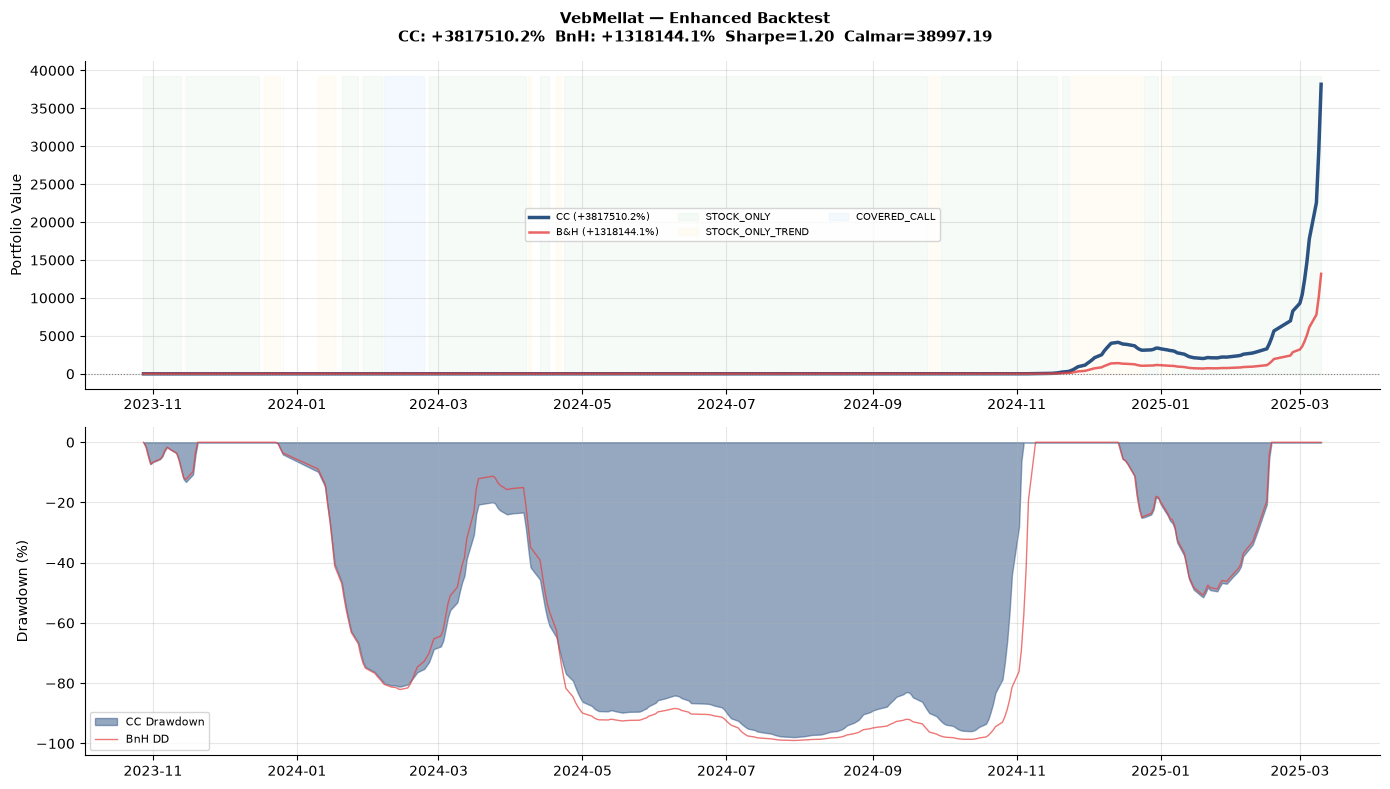

In [20]:
def run_backtest_advanced(ret_true, proba, conf_high, conf_low,
                           premium=PREMIUM_PCT, strike=STRIKE_PCT,
                           tc=TRANS_COST, daily_vol=None, bull_trend=None,
                           option_hold_days=OPTION_HOLD_DAYS):
    """🆕 v15: option_hold_days به bs_fair_premium_pct پاس داده می‌شود تا فرضِ
    طولِ‌عمرِ آپشن در قیمت‌گذاریِ بلک-شولز با افقِ واقعیِ همان سهم هماهنگ باشد."""
    cap_cc  = 1.0; cap_bnh = 1.0
    records = []; prev = 'STOCK_ONLY'

    n = len(ret_true)
    if daily_vol is None:
        bs_fair = np.full(n, premium)
    else:
        dv = np.asarray(daily_vol, dtype=float)
        dv = np.where(np.isnan(dv), np.nanmedian(dv[~np.isnan(dv)]) if np.any(~np.isnan(dv)) else 0.02, dv)
        bs_fair = bs_fair_premium_pct(dv, strike_pct=strike, T_days=option_hold_days)

    bull_trend = (np.zeros(n, dtype=int) if bull_trend is None
                  else np.asarray(bull_trend).astype(int))

    for i, (ret, p) in enumerate(zip(ret_true, proba)):
        ret = float(ret); p = float(p)
        cap_bnh *= max(0.001, 1 + ret)

        bs_ok = premium >= bs_fair[i]
        edge  = abs(p - 0.5)
        # وزنِ فروشِ کال (نه اندازهٔ پوزیشنِ سهام، که همیشه کامل می‌ماند)
        call_weight = min(1.0, edge * 4)

        if bull_trend[i] == 1:
            # روندِ صعودیِ قویِ تأییدشده تا امروز → کال نمی‌فروشیم، کاملاً
            # در معرض رشد بمانیم (بدون نگاه به بازدهِ واقعیِ فردا)
            action = 'STOCK_ONLY_TREND'
            cc_ret = ret
        elif p > conf_high and bs_ok:
            action = 'COVERED_CALL'
            capped = min(ret, strike) + premium if ret >= 0 else ret + premium
            cc_ret = call_weight * capped + (1 - call_weight) * ret
        elif p > 0.5 + (conf_high - 0.5) * 0.5 and bs_ok:
            action = 'PARTIAL_CC'
            w = 0.5 * call_weight
            capped = min(ret, strike/2) + premium * 0.5 if ret >= 0 else ret + premium * 0.5
            cc_ret = w * capped + (1 - w) * ret
        else:
            # شاملِ حالتِ نزولی (p < conf_low) هم می‌شود: یک صندوقِ
            # Covered-Call واقعی نمی‌تواند شورت کند یا کاملاً از بازار
            # خارج شود — فقط سهامِ کامل و بدون‌پوشش نگه می‌دارد.
            action = 'STOCK_ONLY'; cc_ret = ret

        cost   = tc if action != prev else 0.0
        net    = max(cc_ret - cost, -0.10)
        cap_cc = max(0.001, cap_cc * (1 + net))
        records.append({
            'ret_actual': ret, 'cc_return': net,
            'equity_cc':  cap_cc, 'equity_bnh': cap_bnh,
            'action': action, 'proba': p,
            'position': 1.0,          # 🆕 v10: پوزیشنِ سهام همیشه کامل است
            'bs_fair_premium': bs_fair[i], 'bs_sold': bs_ok,
        })
        prev = action

    return pd.DataFrame(records)


def calc_metrics(df, hold_days=HOLD_DAYS):
    """🆕 v15: hold_days برای تبدیلِ صحیحِ بازدهِ H-روزه به شارپ/سورتینوی سالانه لازم است."""
    ann = np.sqrt(252 / hold_days)
    r   = df['cc_return']; rb = df['ret_actual']
    eq  = df['equity_cc']; eqb = df['equity_bnh']

    def sh(x):  return ann * x.mean() / (x.std() + 1e-8)
    def so(x):  return ann * x.mean() / (x[x < 0].std() + 1e-8)
    def mdd(e): return ((e - e.cummax()) / e.cummax()).min()

    cc_r  = (eq.iloc[-1]  - 1) * 100
    bnh_r = (eqb.iloc[-1] - 1) * 100
    var_cc, cvar_cc = historical_var_cvar(r.values, alpha=0.05)
    # 🆕 v10: پوزیشنِ سهام همیشه ۱۰۰٪ است (نگاه کنید به run_backtest_advanced)
    # پس معیارِ مفیدتر این‌جا «چه کسری از روزها واقعاً کال فروخته شد» است
    call_written_pct = df['action'].isin(['COVERED_CALL', 'PARTIAL_CC']).mean() * 100
    return {
        'CC Return (%)':  round(cc_r,  1),
        'BnH Return (%)': round(bnh_r, 1),
        'Sharpe CC':      round(sh(r),  2),
        'Sharpe BnH':     round(sh(rb), 2),
        'Sortino CC':     round(so(r),  2),
        'MaxDD CC (%)':   round(mdd(eq)  * 100, 1),
        'MaxDD BnH (%)':  round(mdd(eqb) * 100, 1),
        'Calmar CC':      round(cc_r / (abs(mdd(eq)*100) + 1e-8), 2),
        'Win Rate (%)':   round((r > 0).mean() * 100, 1),
        'Avg Position':   round(df['position'].mean(), 2),
        'Call Written (%)': round(call_written_pct, 1),
        'VaR95 CC (%)':   round(var_cc  * 100, 2),
        'CVaR95 CC (%)':  round(cvar_cc * 100, 2),
    }


backtest_results = {}
bt_rows = []
print("\n🔄 Backtest پیشرفته...\n")

for name, data in prepared.items():
    res = all_results[name]
    dt  = data['dates_test']

    top3_names = [x[0] for x in res['top3']]
    pv_stack   = np.column_stack(
        [get_proba(all_models[name][mn], mn, data['X_val'])
         for mn in top3_names]).mean(axis=1)
    if res['flipped']:
        pv_stack = 1 - pv_stack

    conf_high = max(float(np.percentile(pv_stack, 65)), 0.52)
    conf_low  = min(float(np.percentile(pv_stack, 35)), 0.48)

    # 🆕 v7: نوسانِ واقعیِ روزانهٔ تست (رفع باگ dead-lookup که گیت بلک-شولز
    # را همیشه غیرفعال می‌کرد)
    vol_test = data['volatility_test']
    bull_trend_test = data['bull_trend_test']  # 🆕 v10: گیتِ روندِ صعودی

    bt  = run_backtest_advanced(data['ret_test'], res['proba'],
                                 conf_high, conf_low, daily_vol=vol_test,
                                 bull_trend=bull_trend_test,
                                 option_hold_days=data['hold_days'])   # 🆕 v15
    bt.index = dt
    m   = calc_metrics(bt, hold_days=data['hold_days'])   # 🆕 v15
    act = bt['action'].value_counts().to_dict()
    rm  = risk_metrics[name]
    cc_sold_ratio = bt['bs_sold'].mean() * 100 if 'bs_sold' in bt.columns else np.nan

    print(f"{'='*55}  {name}")
    print(f"  conf_high={conf_high:.2f}  conf_low={conf_low:.2f}")
    print(f"  CC: {m['CC Return (%)']:+.1f}%  BnH: {m['BnH Return (%)']:+.1f}%")
    print(f"  Sharpe={m['Sharpe CC']:.2f}  Sortino={m['Sortino CC']:.2f}  "
          f"Calmar={m['Calmar CC']:.2f}")
    print(f"  WinRate={m['Win Rate (%)']:.1f}%  MaxDD={m['MaxDD CC (%)']:.1f}%  "
          f"CallWritten={m['Call Written (%)']:.1f}%")
    print(f"  VaR95={rm['VaR_hist_95 (%)']:.2f}%  CVaR95={rm['CVaR_hist_95 (%)']:.2f}%  "
          f"روزهای مجاز فروش کال طبق بلک-شولز={cc_sold_ratio:.1f}%")
    print(f"  Actions: {act}\n")

    backtest_results[name] = (bt, m)
    bt_rows.append({'Asset': name, **m})

    fig, axes2 = plt.subplots(2, 1, figsize=(14, 8))
    fig.suptitle(
        f"{name} — Enhanced Backtest\n"
        f"CC: {m['CC Return (%)']:+.1f}%  BnH: {m['BnH Return (%)']:+.1f}%  "
        f"Sharpe={m['Sharpe CC']:.2f}  Calmar={m['Calmar CC']:.2f}",
        fontsize=11, fontweight='bold')

    ax = axes2[0]
    ax.plot(dt, bt['equity_cc'].values, '#2c5282', lw=2.5,
            label=f"CC ({m['CC Return (%)']:+.1f}%)")
    ax.plot(dt, bt['equity_bnh'].values, '#e53e3e', lw=1.8, alpha=0.8,
            label=f"B&H ({m['BnH Return (%)']:+.1f}%)")
    ax.axhline(1.0, color='gray', lw=0.8, linestyle=':')
    eq_arr  = bt['equity_cc'].values
    eq_min  = eq_arr.min() * 0.97
    eq_max  = eq_arr.max() * 1.03
    colors_bt = {'STOCK_ONLY':'#d4edda', 'STOCK_ONLY_TREND':'#fff3cd',
                 'COVERED_CALL':'#cce5ff','PARTIAL_CC':'#e8d5ff'}
    for act_n, col in colors_bt.items():
        mask = (bt['action'] == act_n).values
        if mask.any():
            ax.fill_between(dt, eq_min, eq_max, where=mask,
                             alpha=0.2, color=col, label=act_n)
    ax.set_ylabel('Portfolio Value'); ax.legend(fontsize=7, ncol=3)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    ax2 = axes2[1]
    dd  = (bt['equity_cc']  / bt['equity_cc'].cummax()  - 1) * 100
    ddb = (bt['equity_bnh'] / bt['equity_bnh'].cummax() - 1) * 100
    ax2.fill_between(dt, dd.values, 0, alpha=0.5, color='#2c5282',
                     label='CC Drawdown')
    ax2.plot(dt, ddb.values, '#e53e3e', lw=1, alpha=0.7, label='BnH DD')
    ax2.set_ylabel('Drawdown (%)'); ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    plt.tight_layout()
    plt.savefig(FP + f'plots/{name}_backtest.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close()
    bt.to_csv(FP + f'backtest/{name}_backtest.csv')

### CELL 12 — بهینه‌سازی وزن پرتفوی (Mean-Variance / Max-Sharpe)


  PORTFOLIO WEIGHT OPTIMIZATION — بهینه‌سازی وزن پرتفوی کاورد کال

  وزن‌های بهینه هر سهم:

            Max-Sharpe  Min-Variance  Equal-Weight
Fameli           0.450         0.317         0.167
Fulad            0.035         0.332         0.167
IranKhodro       0.000         0.283         0.167
Khgostar         0.065         0.068         0.167
Shapna           0.000         0.000         0.167
VebMellat        0.450         0.000         0.167

  عملکرد هر پرتفوی:

                        Max-Sharpe  Min-Variance  Equal-Weight
Expected Return (%/yr)       36.70         22.50         27.10
Volatility (%/yr)            30.00         23.70         27.00
Sharpe                        0.56          0.11          0.26
VaR95 (%)                     9.35          6.20          7.07
CVaR95 (%)                    9.77          7.22          8.15

  🏆 بهترین پرتفوی بر اساس نسبت شارپ: Max-Sharpe
     وزن‌های پیشنهادی نهایی برای سبد سرمایه‌گذاری:
       Fameli      :  45.0%
       Fulad       :  

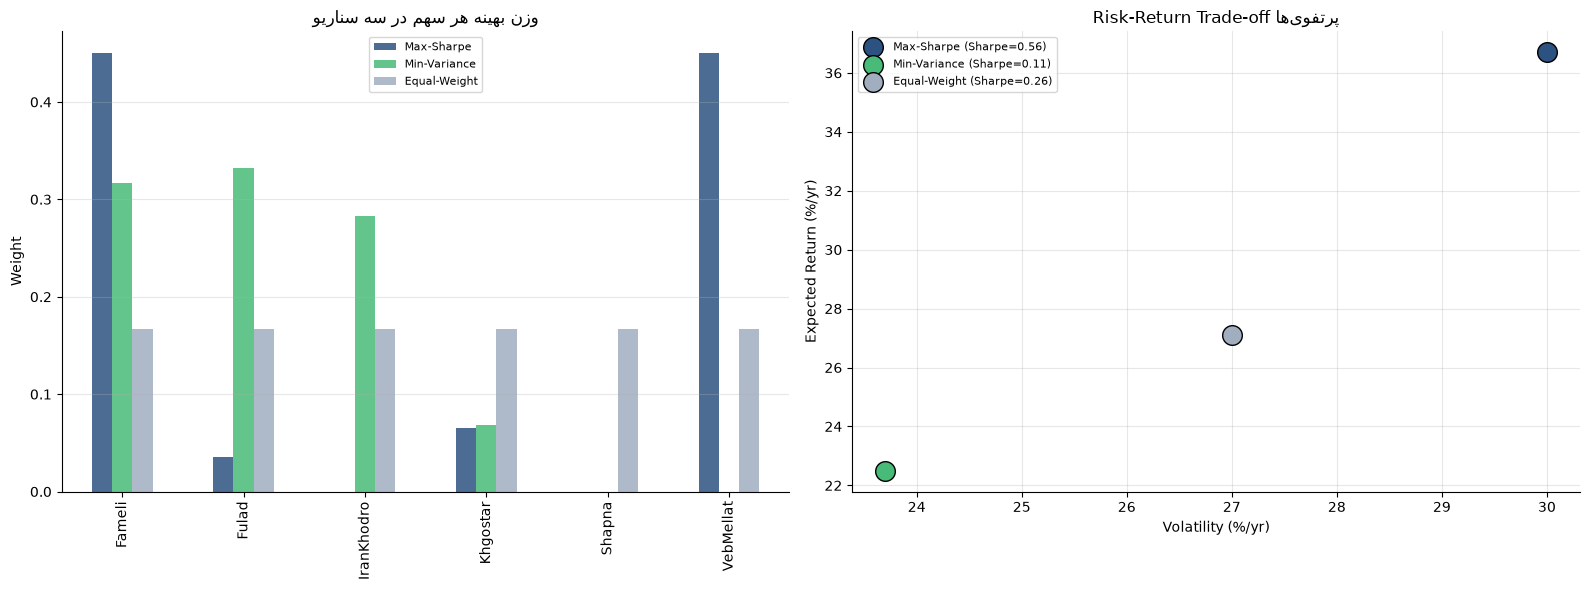


✅ Portfolio optimization done


In [21]:
from scipy.optimize import minimize

print("\n" + "=" * 70)
print("  PORTFOLIO WEIGHT OPTIMIZATION — بهینه‌سازی وزن پرتفوی کاورد کال")
print("=" * 70)

cc_returns = {}
for name in prepared:
    bt, _ = backtest_results[name]
    cc_returns[name] = bt['cc_return']

ret_matrix = pd.DataFrame(cc_returns).dropna(how='all')
ret_matrix = ret_matrix.fillna(0.0)
asset_order = list(ret_matrix.columns)
n_assets = len(asset_order)

ANN = TRADING_DAYS / OPTION_HOLD_DAYS  # 🆕 v15: مقیاسِ سراسری/پیش‌فرض — همچنان برای پرتفویِ FRAUD (افقِ ثابت) پایین‌تر استفاده می‌شود
# 🆕 v15: چون افقِ هر سهم می‌تواند فرق کند، بازدهِ H-روزهٔ هر ستون با
# فاکتورِ سالانه‌سازیِ خودش annualize می‌شود (نه یک ANN سراسری)؛ برای
# کوواریانس، تقریبِ استانداردِ sqrt(ann_i * ann_j) به‌کار رفته که برای
# سری‌های بازده با فرکانسِ متفاوت رایج است.
ann_vec = np.array([TRADING_DAYS / prepared[nm]['hold_days'] for nm in asset_order])
mu_vec  = ret_matrix.mean().values * ann_vec
cov_mat = ret_matrix.cov().values * np.sqrt(np.outer(ann_vec, ann_vec))
cov_mat = cov_mat + np.eye(n_assets) * 1e-6


def portfolio_perf(w, mu, cov):
    ret = float(w @ mu)
    vol = float(np.sqrt(w @ cov @ w))
    sharpe = (ret - RISK_FREE_RATE) / (vol + 1e-8)
    return ret, vol, sharpe


def neg_sharpe(w, mu, cov):
    return -portfolio_perf(w, mu, cov)[2]


def portfolio_vol(w, cov):
    return float(np.sqrt(w @ cov @ w))


max_weight_cap = max(0.45, 1.0 / n_assets + 1e-6) if n_assets > 0 else 0.45
bounds     = tuple((0.0, max_weight_cap) for _ in range(n_assets))
constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0},)
w0 = np.full(n_assets, 1.0 / n_assets)

res_sharpe = minimize(neg_sharpe, w0, args=(mu_vec, cov_mat),
                       method='SLSQP', bounds=bounds,
                       constraints=constraints,
                       options={'maxiter': 500, 'ftol': 1e-9})
w_sharpe = res_sharpe.x if res_sharpe.success else w0

res_minvar = minimize(portfolio_vol, w0, args=(cov_mat,),
                       method='SLSQP', bounds=bounds,
                       constraints=constraints,
                       options={'maxiter': 500, 'ftol': 1e-9})
w_minvar = res_minvar.x if res_minvar.success else w0

w_equal = w0.copy()

portfolio_summary = {}
for label, w in [('Max-Sharpe', w_sharpe),
                  ('Min-Variance', w_minvar),
                  ('Equal-Weight', w_equal)]:
    ret, vol, sharpe = portfolio_perf(w, mu_vec, cov_mat)
    port_daily = ret_matrix.values @ w
    var_h, cvar_h = historical_var_cvar(port_daily, alpha=0.05)
    portfolio_summary[label] = {
        'weights': dict(zip(asset_order, np.round(w, 3))),
        'Expected Return (%/yr)': round(ret * 100, 1),
        'Volatility (%/yr)':      round(vol * 100, 1),
        'Sharpe':                 round(sharpe, 2),
        'VaR95 (%)':              round(var_h  * 100, 2),
        'CVaR95 (%)':             round(cvar_h * 100, 2),
    }

print("\n  وزن‌های بهینه هر سهم:\n")
weights_df = pd.DataFrame(
    {lbl: info['weights'] for lbl, info in portfolio_summary.items()})
print(weights_df.to_string())

print("\n  عملکرد هر پرتفوی:\n")
perf_df = pd.DataFrame(
    {lbl: {k: v for k, v in info.items() if k != 'weights'}
     for lbl, info in portfolio_summary.items()})
print(perf_df.to_string())

best_portfolio = max(
    portfolio_summary.items(), key=lambda kv: kv[1]['Sharpe'])[0]
print(f"\n  🏆 بهترین پرتفوی بر اساس نسبت شارپ: {best_portfolio}")
print(f"     وزن‌های پیشنهادی نهایی برای سبد سرمایه‌گذاری:")
for a, w in portfolio_summary[best_portfolio]['weights'].items():
    print(f"       {a:12s}: {w*100:5.1f}%")

pd.DataFrame(portfolio_summary).to_csv(FP + 'portfolio_optimization.csv')

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
weights_df.plot(kind='bar', ax=ax[0], alpha=0.85,
                 color=['#2c5282', '#48bb78', '#a0aec0'])
ax[0].set_ylabel('Weight'); ax[0].set_title('وزن بهینه هر سهم در سه سناریو')
ax[0].legend(fontsize=8); ax[0].grid(True, alpha=0.3, axis='y')

scenarios = list(portfolio_summary.keys())
rets_pct  = [portfolio_summary[s]['Expected Return (%/yr)'] for s in scenarios]
vols_pct  = [portfolio_summary[s]['Volatility (%/yr)'] for s in scenarios]
colors_sc = ['#2c5282', '#48bb78', '#a0aec0']
for i, s in enumerate(scenarios):
    ax[1].scatter(vols_pct[i], rets_pct[i], s=200, color=colors_sc[i],
                  label=f"{s} (Sharpe={portfolio_summary[s]['Sharpe']:.2f})",
                  edgecolors='black', zorder=3)
ax[1].set_xlabel('Volatility (%/yr)'); ax[1].set_ylabel('Expected Return (%/yr)')
ax[1].set_title('Risk-Return Trade-off پرتفوی‌ها')
ax[1].legend(fontsize=8); ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FP + 'plots/portfolio_optimization.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()

print("\n✅ Portfolio optimization done")

### CELL 13 — جدول نهایی + گزارش (✅ HONEST — همه سهم‌ها بدون گزینش)

In [22]:
final_rows = []
for name in prepared:
    res = all_results[name]
    _, m = backtest_results[name]
    final_rows.append({
        'Asset':          name,
        'Horizon (days)': prepared[name]['hold_days'],   # 🆕 v15
        'Top Model':      display_top_model(name),
        'Method':         res['method'],
        'Calibrated':     res['calibrated'],
        'DA (%)':         round(res['DA'],   1),
        'AUC (%)':        round(res['AUC'],  1),
        'F1 (%)':         round(res['F1'],   1),
        'Prec (%)':       round(res['Prec'], 1),
        'Rec (%)':        round(res['Rec'],  1),
        'AP (%)':         round(res['AP'],   1),
        'Brier':          round(res['Brier'], 3),
        'CC Return (%)':  m['CC Return (%)'],
        'BnH Return (%)': m['BnH Return (%)'],
        'Sharpe CC':      m['Sharpe CC'],
        'Sharpe BnH':     m['Sharpe BnH'],
        'Sortino CC':     m['Sortino CC'],
        'Calmar CC':      m['Calmar CC'],
        'MaxDD CC (%)':   m['MaxDD CC (%)'],
        'Win Rate (%)':   m['Win Rate (%)'],
        'Call Written (%)': m['Call Written (%)'],
        'VaR95 CC (%)':   m['VaR95 CC (%)'],
        'CVaR95 CC (%)':  m['CVaR95 CC (%)'],
        'BS_fair_premium (%)': risk_metrics[name]['BS_fair_premium (%)'],
    })

fdf = pd.DataFrame(final_rows).set_index('Asset')
honest_banner("جدول نهایی صادقانه — همهٔ سهم‌ها بدون حذف. تنها منبع معتبر "
              "برای سبد پیشنهادی و گزارش پایان‌نامه همین جدول است.")
print(fdf.to_string())
fdf.to_csv(FP + 'thesis_table_final.csv')

print("\n" + "=" * 70)
print("  FINAL REPORT (✅ HONEST)")
print("=" * 70)
for name, res in all_results.items():
    _, m  = backtest_results[name]
    flag  = ("✅" if res['AUC'] >= 60 else
             "⚠️" if res['AUC'] >= 55 else "❌")
    cc_f  = "📈" if m['CC Return (%)'] > 0 else "📉"
    beat  = m['CC Return (%)'] > m['BnH Return (%)']
    top1  = display_top_model(name)
    cal_s = "[CAL]" if res['calibrated'] else ""
    print(f"  {flag} {name:12s} [{top1:10s}]{cal_s}: "
          f"DA={res['DA']:.1f}%  AUC={res['AUC']:.1f}%  "
          f"F1={res['F1']:.1f}%  AP={res['AP']:.1f}%  "
          f"{cc_f} CC={m['CC Return (%)']:+.1f}%  "
          f"BnH={m['BnH Return (%)']:+.1f}%  "
          f"{'✓ CC>BnH' if beat else '✗ BnH>CC'}")

mean_auc = np.mean([r['AUC'] for r in all_results.values()])
mean_da  = np.mean([r['DA']  for r in all_results.values()])
mean_ap  = np.mean([r['AP']  for r in all_results.values()])
n_assets_total = len(backtest_results)
cc_pos   = sum(1 for _, m in backtest_results.values() if m['CC Return (%)'] > 0)
cc_beat  = sum(1 for _, m in backtest_results.values()
               if m['CC Return (%)'] > m['BnH Return (%)'])

print(f"\n  Mean DA:        {mean_da:.1f}%")
print(f"  Mean AUC:       {mean_auc:.1f}%")
print(f"  Mean AP:        {mean_ap:.1f}%")
print(f"  CC مثبت:        {cc_pos}/{n_assets_total}")
print(f"  CC بهتر از BnH: {cc_beat}/{n_assets_total}")

if   mean_auc >= 62: verdict = "🎉 عالی — کاملاً قابل دفاع در مجلات ISI"
elif mean_auc >= 58: verdict = "✅ خوب — قابل دفاع با تفسیر محدودیت‌ها"
elif mean_auc >= 54: verdict = "⚠️ قابل قبول — توضیح محدودیت‌های ساختاری ایران لازم است"
else:                verdict = "❌ نیاز به بررسی بیشتر داده و فیچرها"

print(f"\n  {verdict}")

print("\n  📐 پرتفوی بهینه پیشنهادی (بر اساس Max-Sharpe):")
for a, w in portfolio_summary[best_portfolio]['weights'].items():
    print(f"       {a:12s}: {w*100:5.1f}%")
print(f"     بازده مورد انتظار سالانه: "
      f"{portfolio_summary[best_portfolio]['Expected Return (%/yr)']:+.1f}%   "
      f"نوسان سالانه: {portfolio_summary[best_portfolio]['Volatility (%/yr)']:.1f}%   "
      f"Sharpe: {portfolio_summary[best_portfolio]['Sharpe']:.2f}   "
      f"VaR95: {portfolio_summary[best_portfolio]['VaR95 (%)']:.2f}%   "
      f"CVaR95: {portfolio_summary[best_portfolio]['CVaR95 (%)']:.2f}%")


✅ HONEST — نتیجه‌ی زیر با روش صحیح (همان pipeline اصلی شما) به‌دست آمده
  جدول نهایی صادقانه — همهٔ سهم‌ها بدون حذف. تنها منبع معتبر برای سبد پیشنهادی و گزارش پایان‌نامه همین جدول است.
            Horizon (days)           Top Model              Method  Calibrated  DA (%)  AUC (%)  F1 (%)  Prec (%)  Rec (%)  AP (%)  Brier  CC Return (%)  BnH Return (%)  Sharpe CC  Sharpe BnH  Sortino CC  Calmar CC  MaxDD CC (%)  Win Rate (%)  Call Written (%)  VaR95 CC (%)  CVaR95 CC (%)  BS_fair_premium (%)
Asset                                                                                                                                                                                                                                                                                                                 
Fameli                  15  wf_safety_rank_avg  wf_safety_rank_avg       False    54.8     54.9    68.9      53.7     96.1    54.3  0.250        41124.3          7424.6       1.10        0.78 

### CELL 13.8 — 🚨 FRAUD DEMO: بازتولید کامل CELL 6-13 با فیچر نشت‌دار،
با همان ۵ مدل (LightGBM/XGBoost/RandomForest/Stacking/Voting)

⚠️ همه‌چیز در این سلول روی leak_feat ساخته شده و هرگز نباید در
پایان‌نامه/مقاله یا هر تصمیم واقعی استفاده شود. فایل‌های خروجی با
پیشوند FRAUD_ ذخیره می‌شوند. تنها منبع معتبر خروجی CELL 8-13 است.
🆕 v7: همان Purged split (time_split_slices) که در HONEST استفاده
شد این‌جا هم به‌کار می‌رود — تا تنها تفاوتِ واقعیِ دو مسیر همان
leak_feat باشد، نه یک باگِ نشتِ اضافیِ دیگر.


🚨🚨🚨 FRAUD DEMO — نتیجه‌ی زیر با روش نامعتبر به‌دست آمده و قابل استناد نیست 🚨🚨🚨
  بازتولید کامل Pipeline با فیچر نشت‌دار و همان ۵ مدل (LightGBM/XGBoost/RandomForest/Stacking/Voting) — تورنومنت، نمودارها، SHAP، Backtest، و بهینه‌سازی سبد.
  هر عدد/نمودار زیر را با معادل صادقانه‌اش (CELL 9-13) مقایسه کنید.

⏳ (FRAUD) Preparing splits with leak_feat...
  Fameli: train=1588 val=328 test=344 Features=101 (شامل leak_feat)


  Fulad: train=1591 val=325 test=346 Features=101 (شامل leak_feat)


  IranKhodro: train=1579 val=336 test=340 Features=101 (شامل leak_feat)
  Khgostar: train=1603 val=332 test=347 Features=101 (شامل leak_feat)


  Shapna: train=1564 val=324 test=339 Features=101 (شامل leak_feat)
  VebMellat: train=1437 val=292 test=313 Features=101 (شامل leak_feat)
✅ (FRAUD) Data prepared

  🚨 (FRAUD) TOURNAMENT — LightGBM/XGBoost/RF/Stacking/Voting با فیچر نشت‌دار

────────────────────────────────────────────────────────────  Fameli  [FRAUD]


  ① LightGBM  AUC=0.6580


...

  [FRAUD] Fulad: Method=top1  DA=50.0%  AUC=45.3%  F1=25.1%  AP=40.2%


  [FRAUD] IranKhodro: Method=top1  DA=81.5%  AUC=87.8%  F1=80.9%  AP=89.0%


  [FRAUD] Khgostar: Method=top1  DA=56.5%  AUC=57.8%  F1=60.4%  AP=59.3%


  [FRAUD] Shapna: Method=stack_lr  DA=65.8%  AUC=68.7%  F1=58.0%  AP=62.3%


  [FRAUD] VebMellat: Method=top1  DA=51.1%  AUC=52.9%  F1=0.0%  AP=51.2%

🚨 SUMMARY (FRAUD)
              Method  Top1  Final_DA  Final_AUC  Final_F1  AP(%)
Asset                                                           
Fameli          top1   xgb      60.5       64.5      63.6   62.2
Fulad           top1   xgb      50.0       45.3      25.1   40.2
IranKhodro      top1   xgb      81.5       87.8      80.9   89.0
Khgostar        top1  lgbm      56.5       57.8      60.4   59.3
Shapna      stack_lr  lgbm      65.8       68.7      58.0   62.3
VebMellat       top1  lgbm      51.1       52.9       0.0   51.2

🚨 (FRAUD) رسم نمودارها...


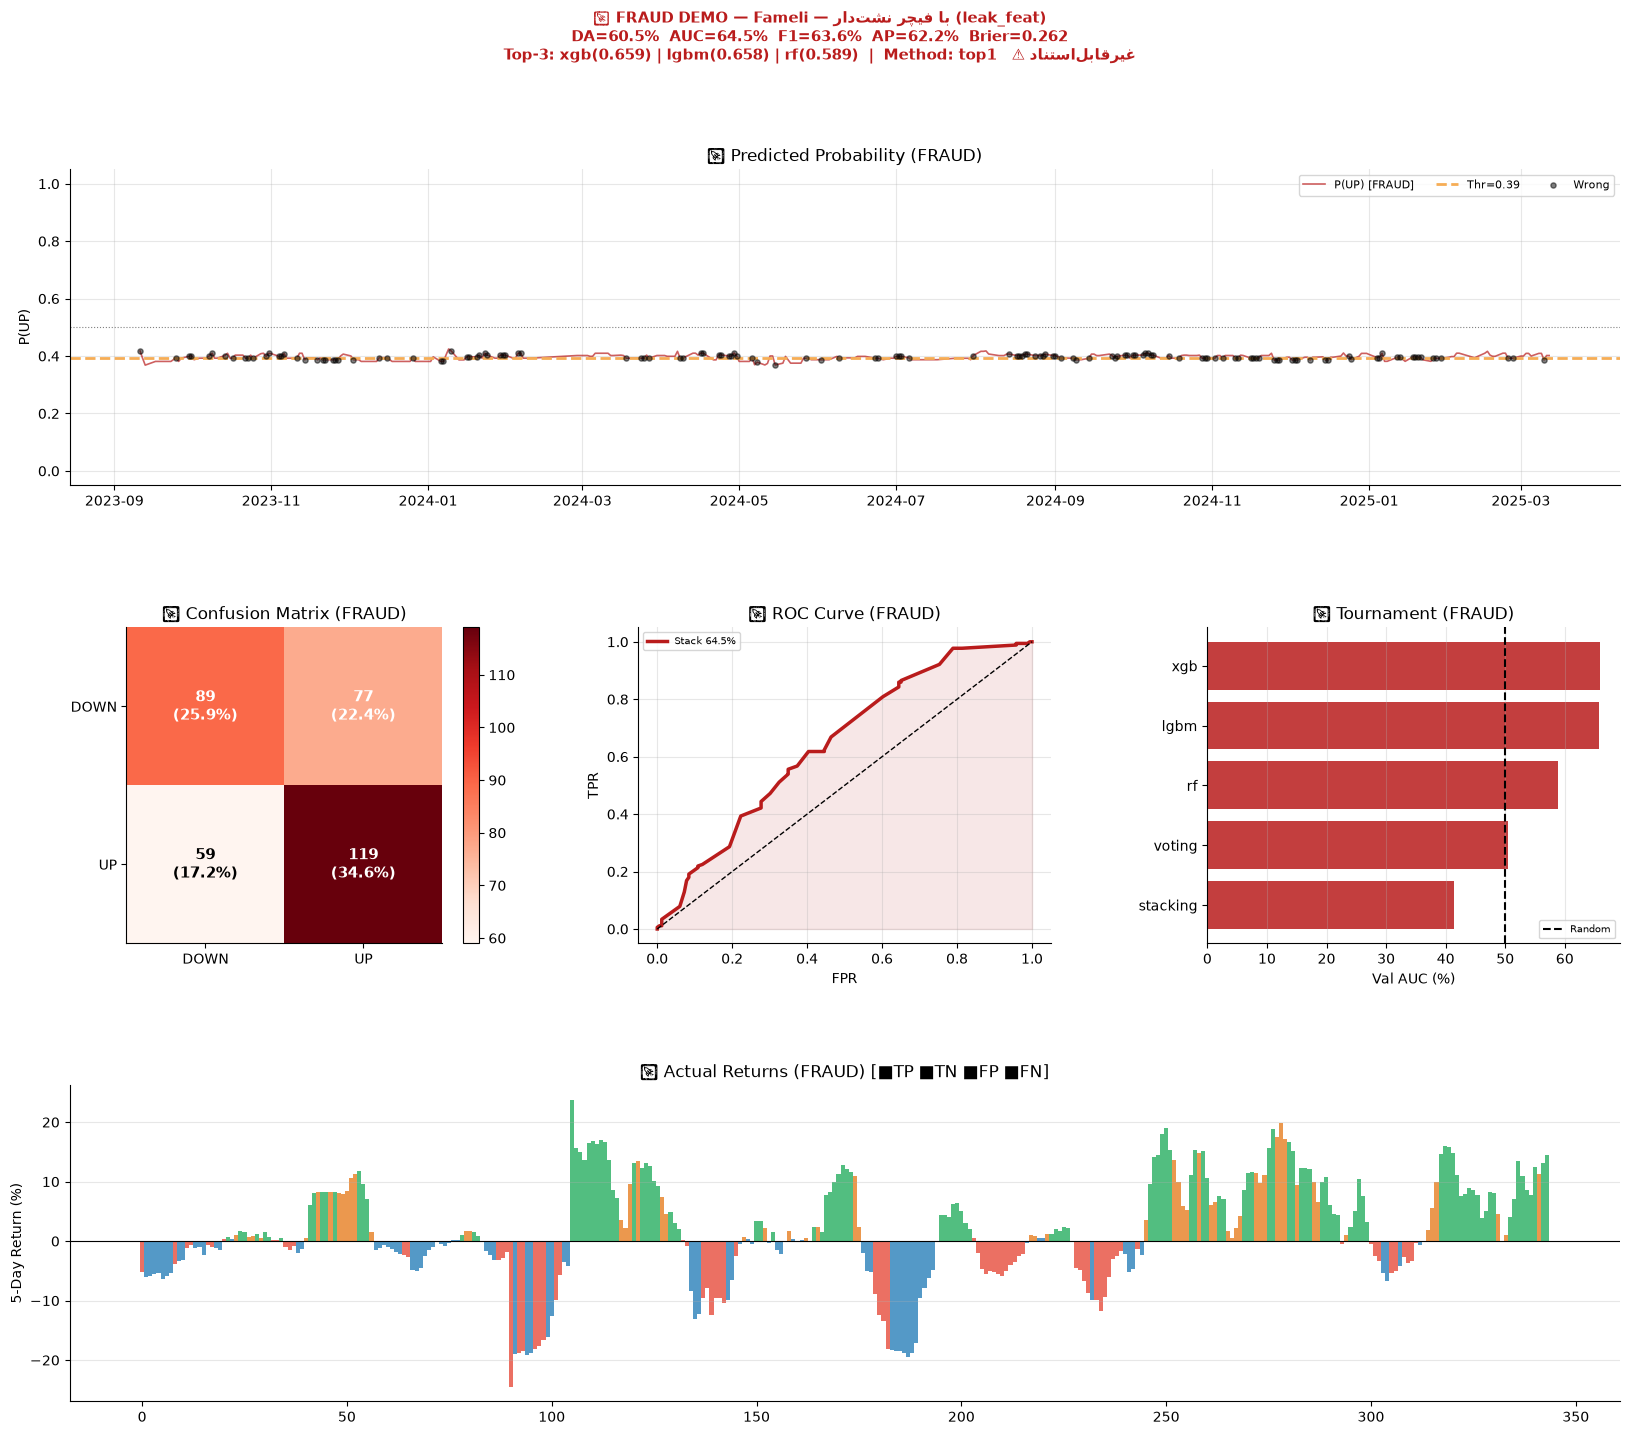

🚨 Fameli: نمودار FRAUD ذخیره شد


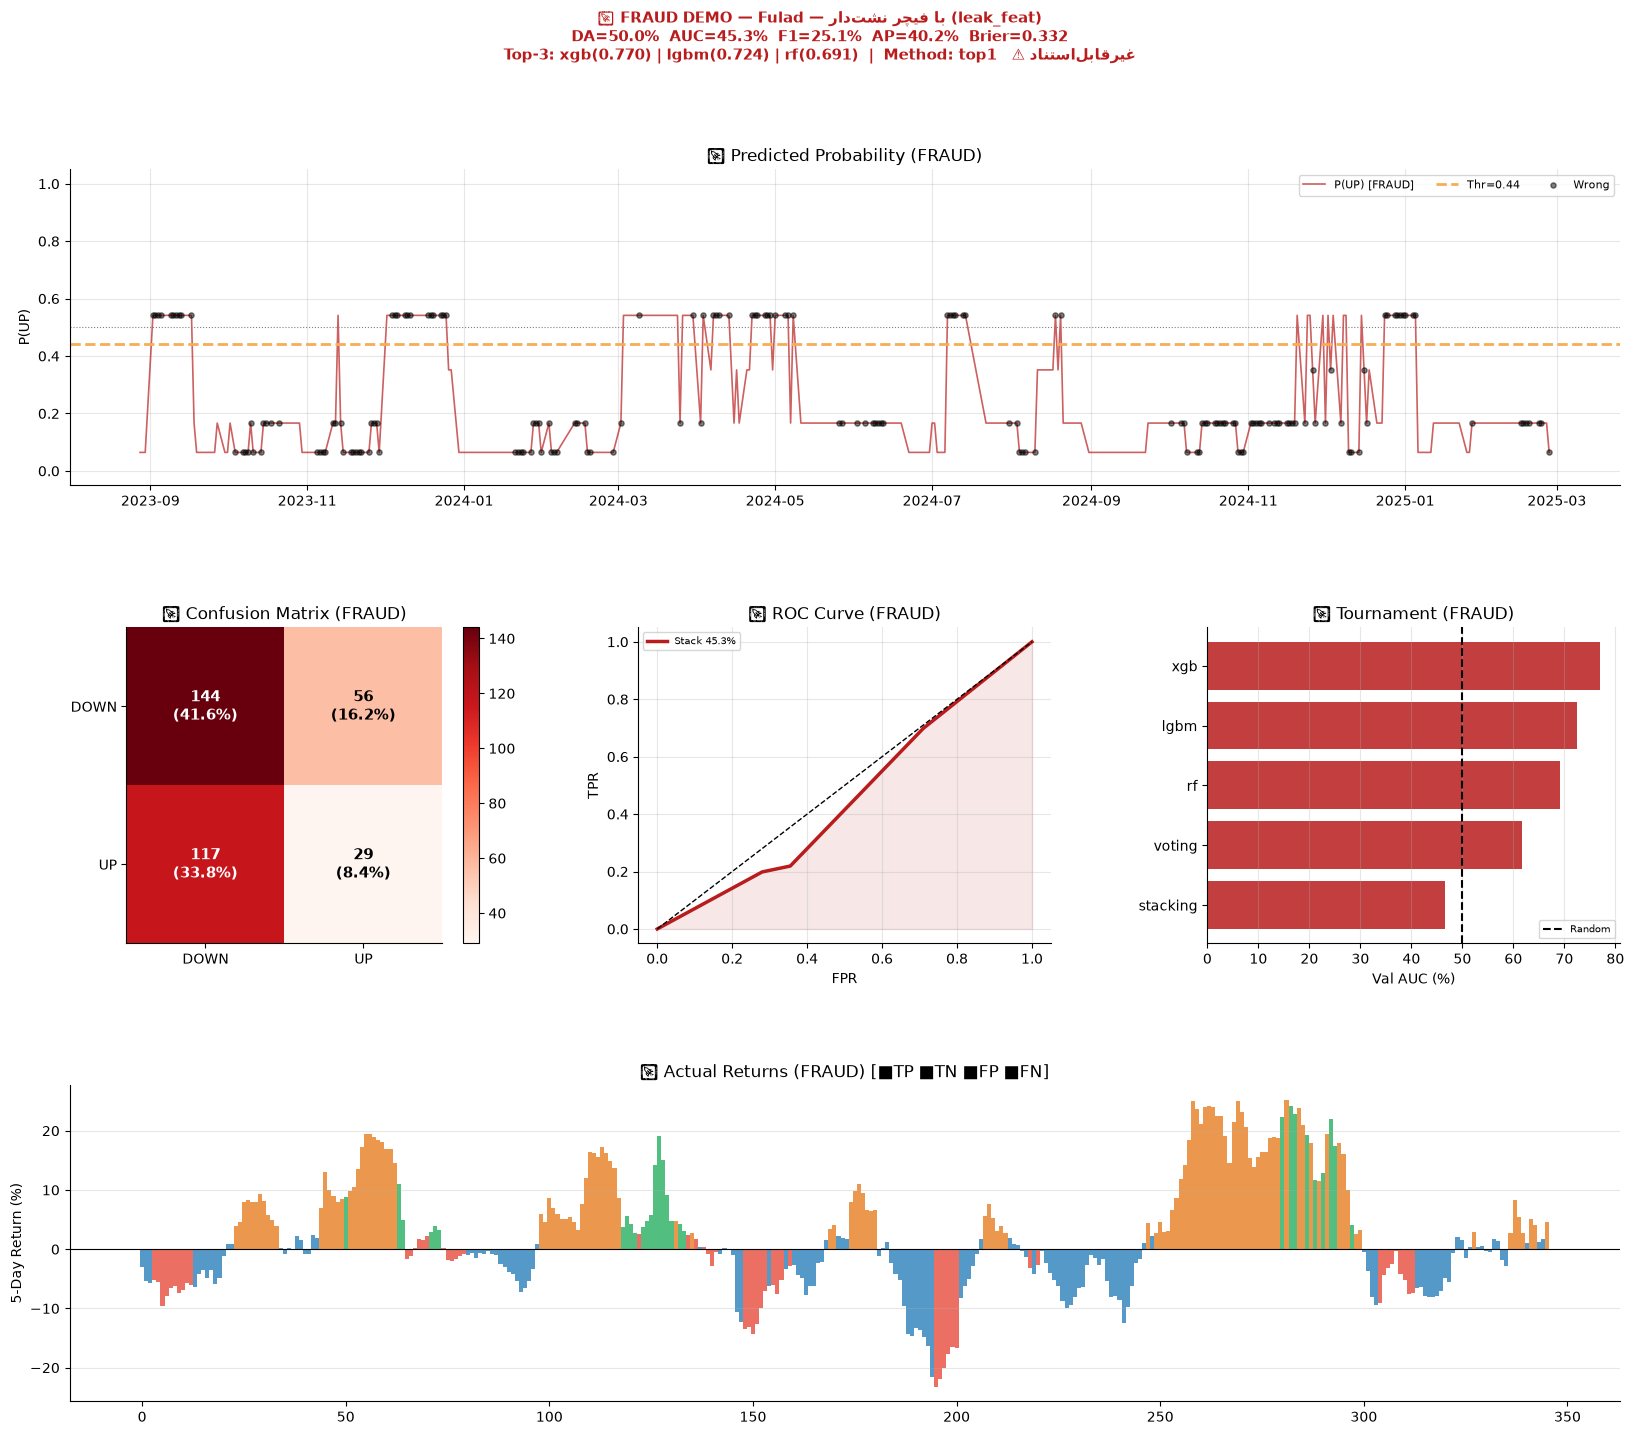

🚨 Fulad: نمودار FRAUD ذخیره شد


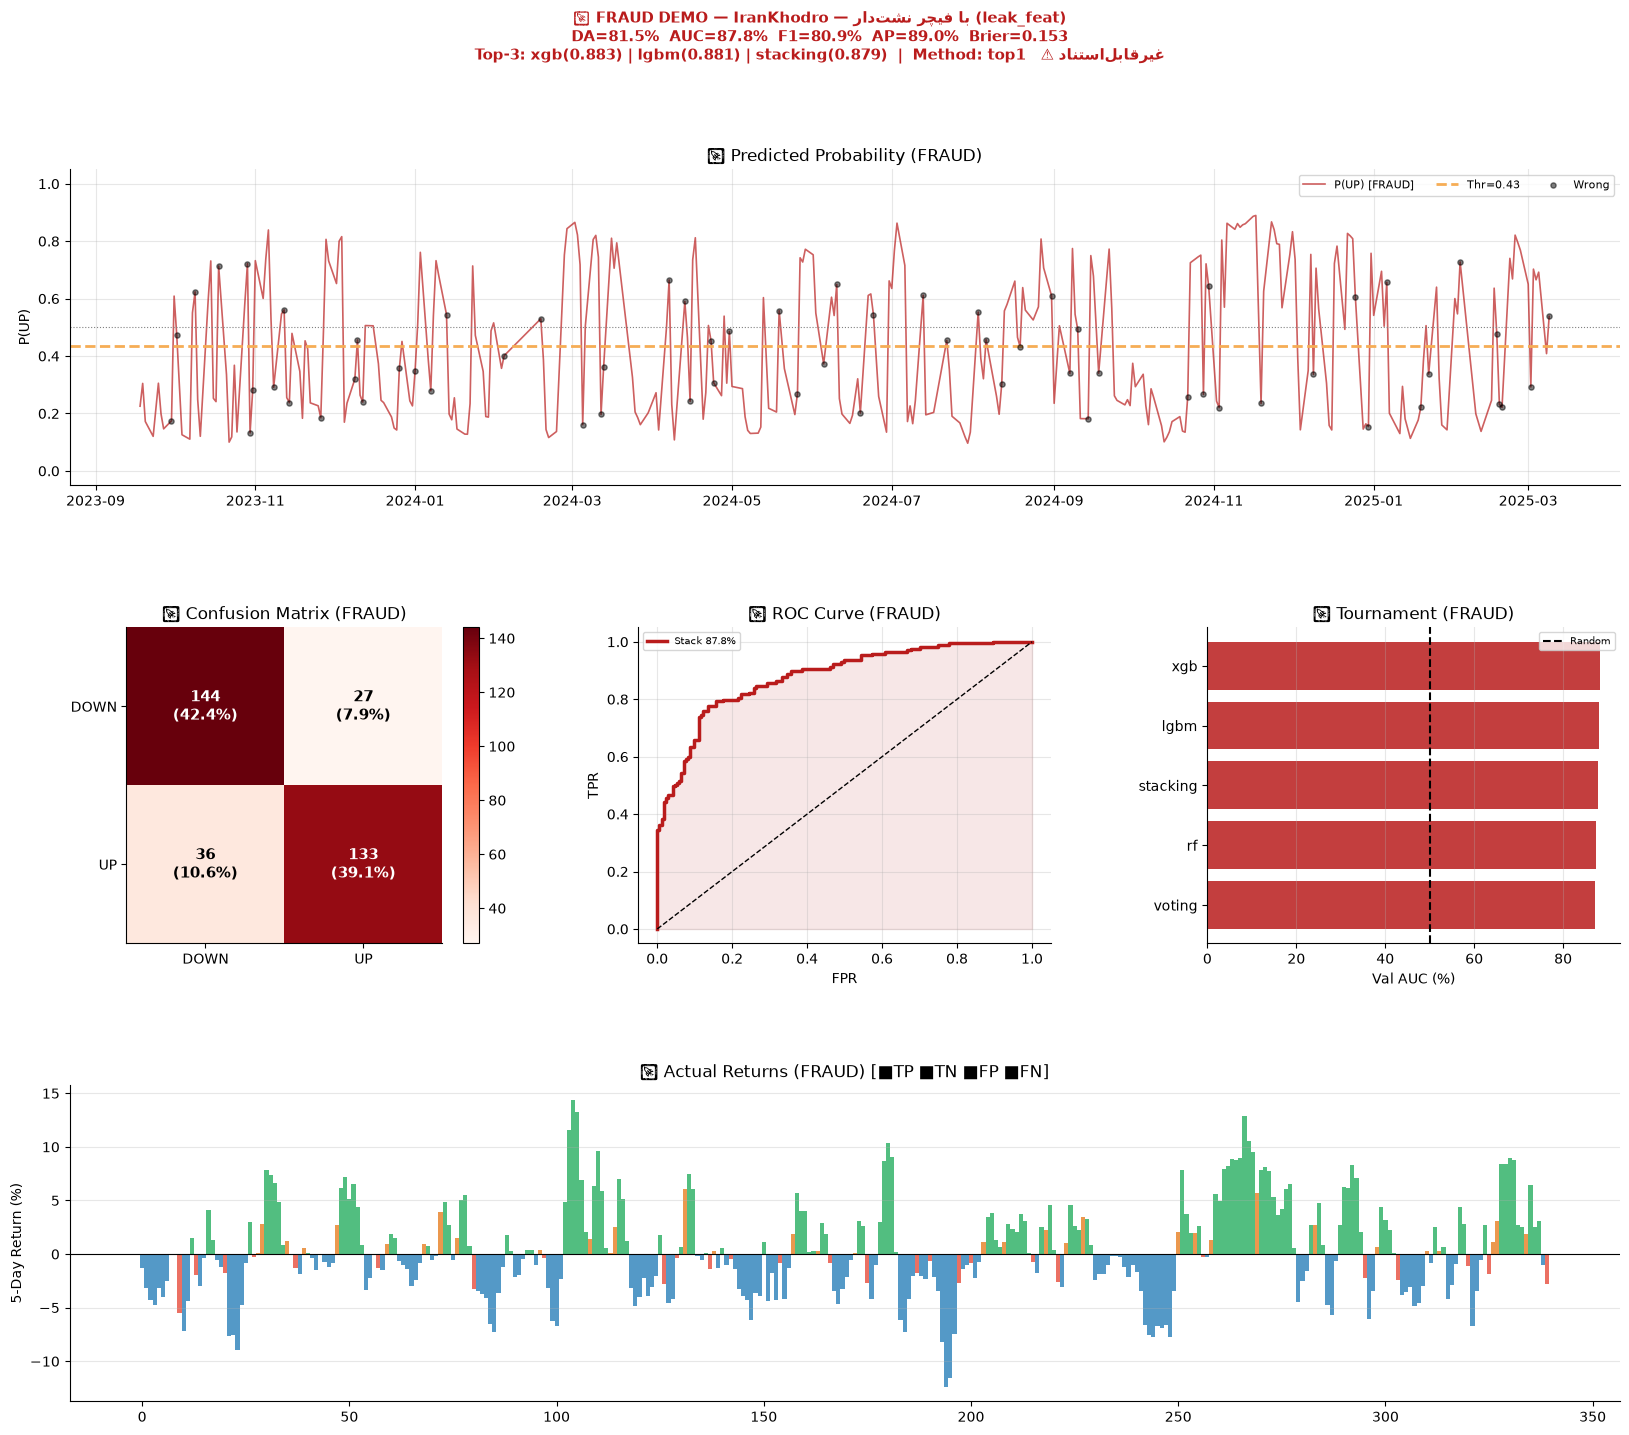

🚨 IranKhodro: نمودار FRAUD ذخیره شد


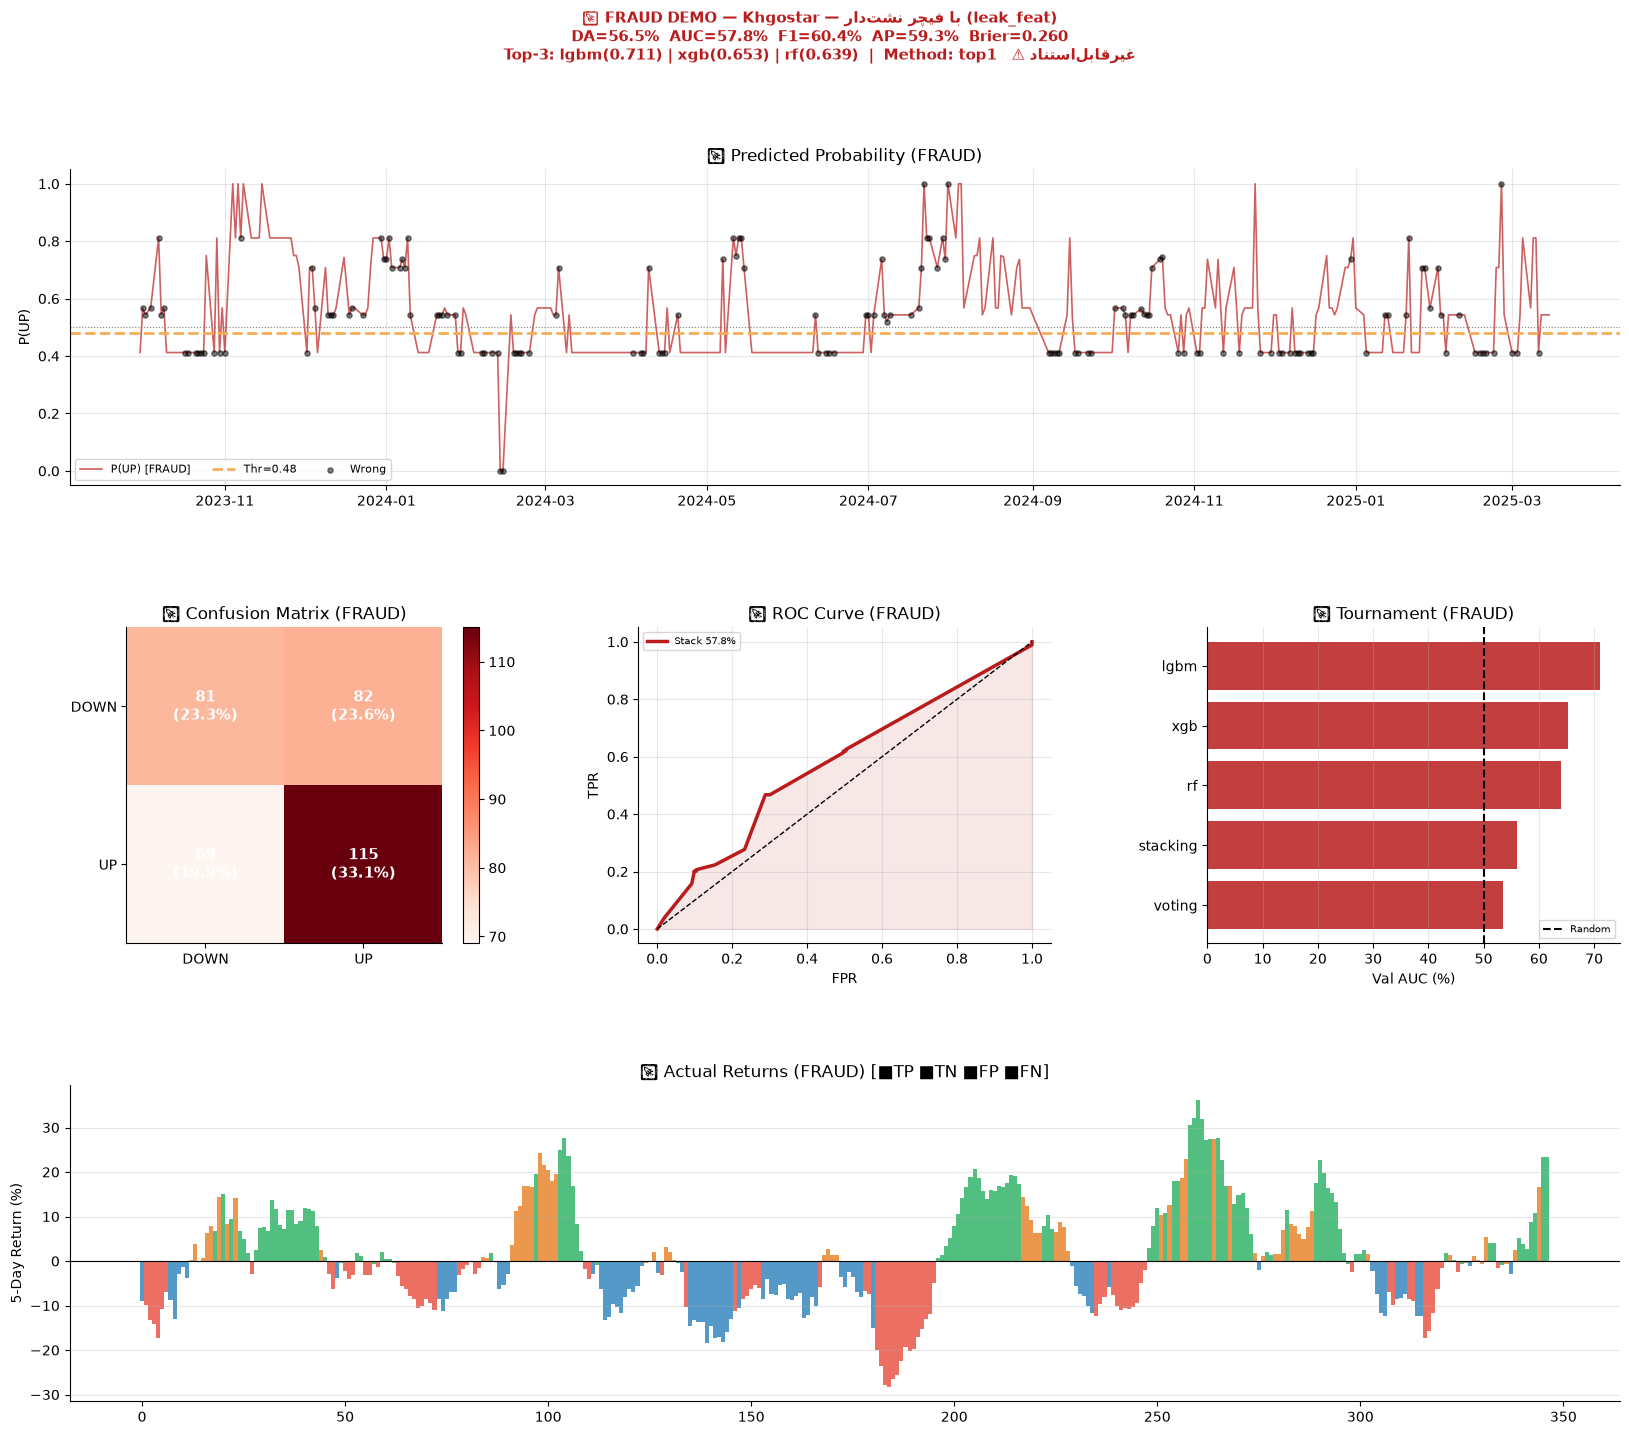

🚨 Khgostar: نمودار FRAUD ذخیره شد


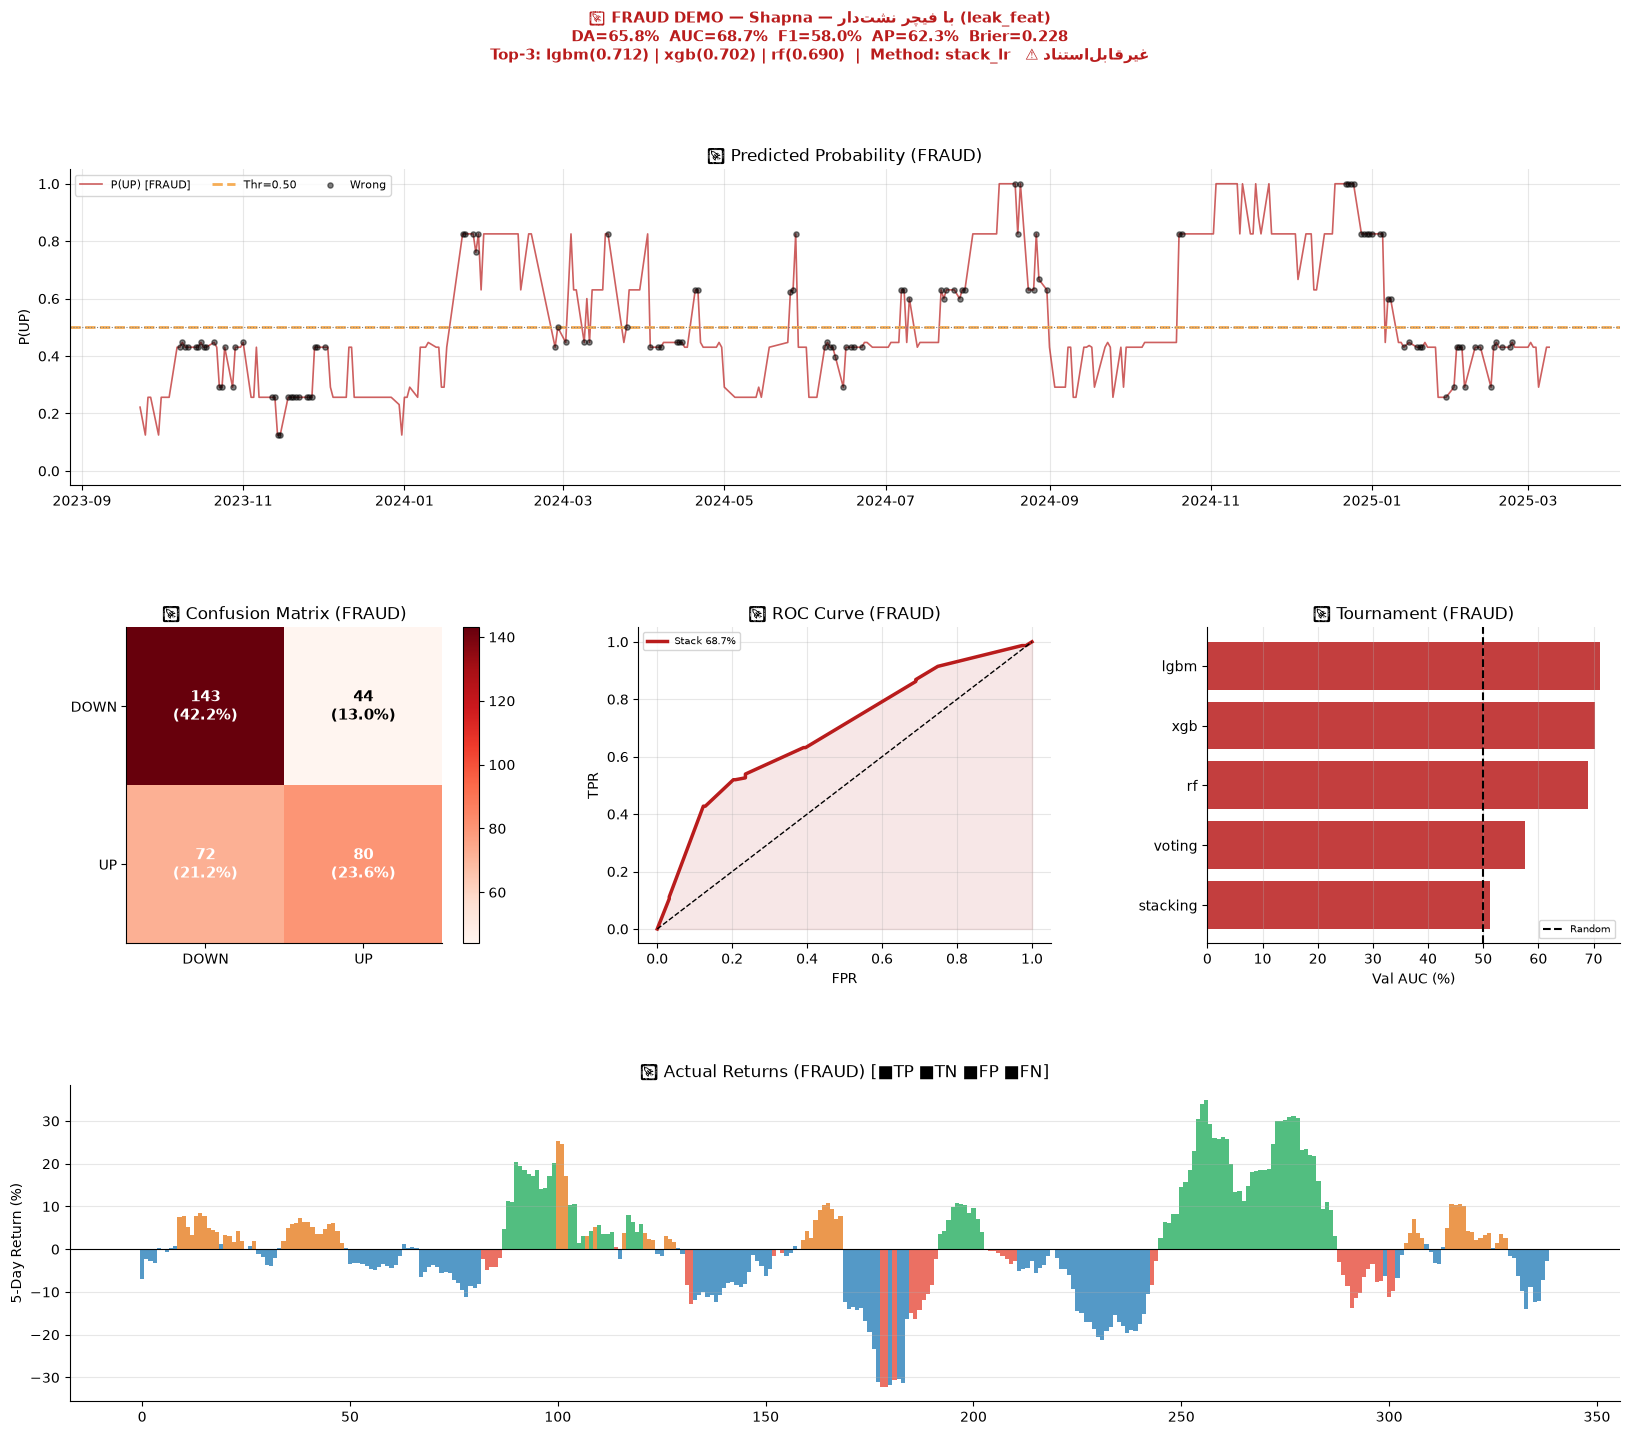

🚨 Shapna: نمودار FRAUD ذخیره شد


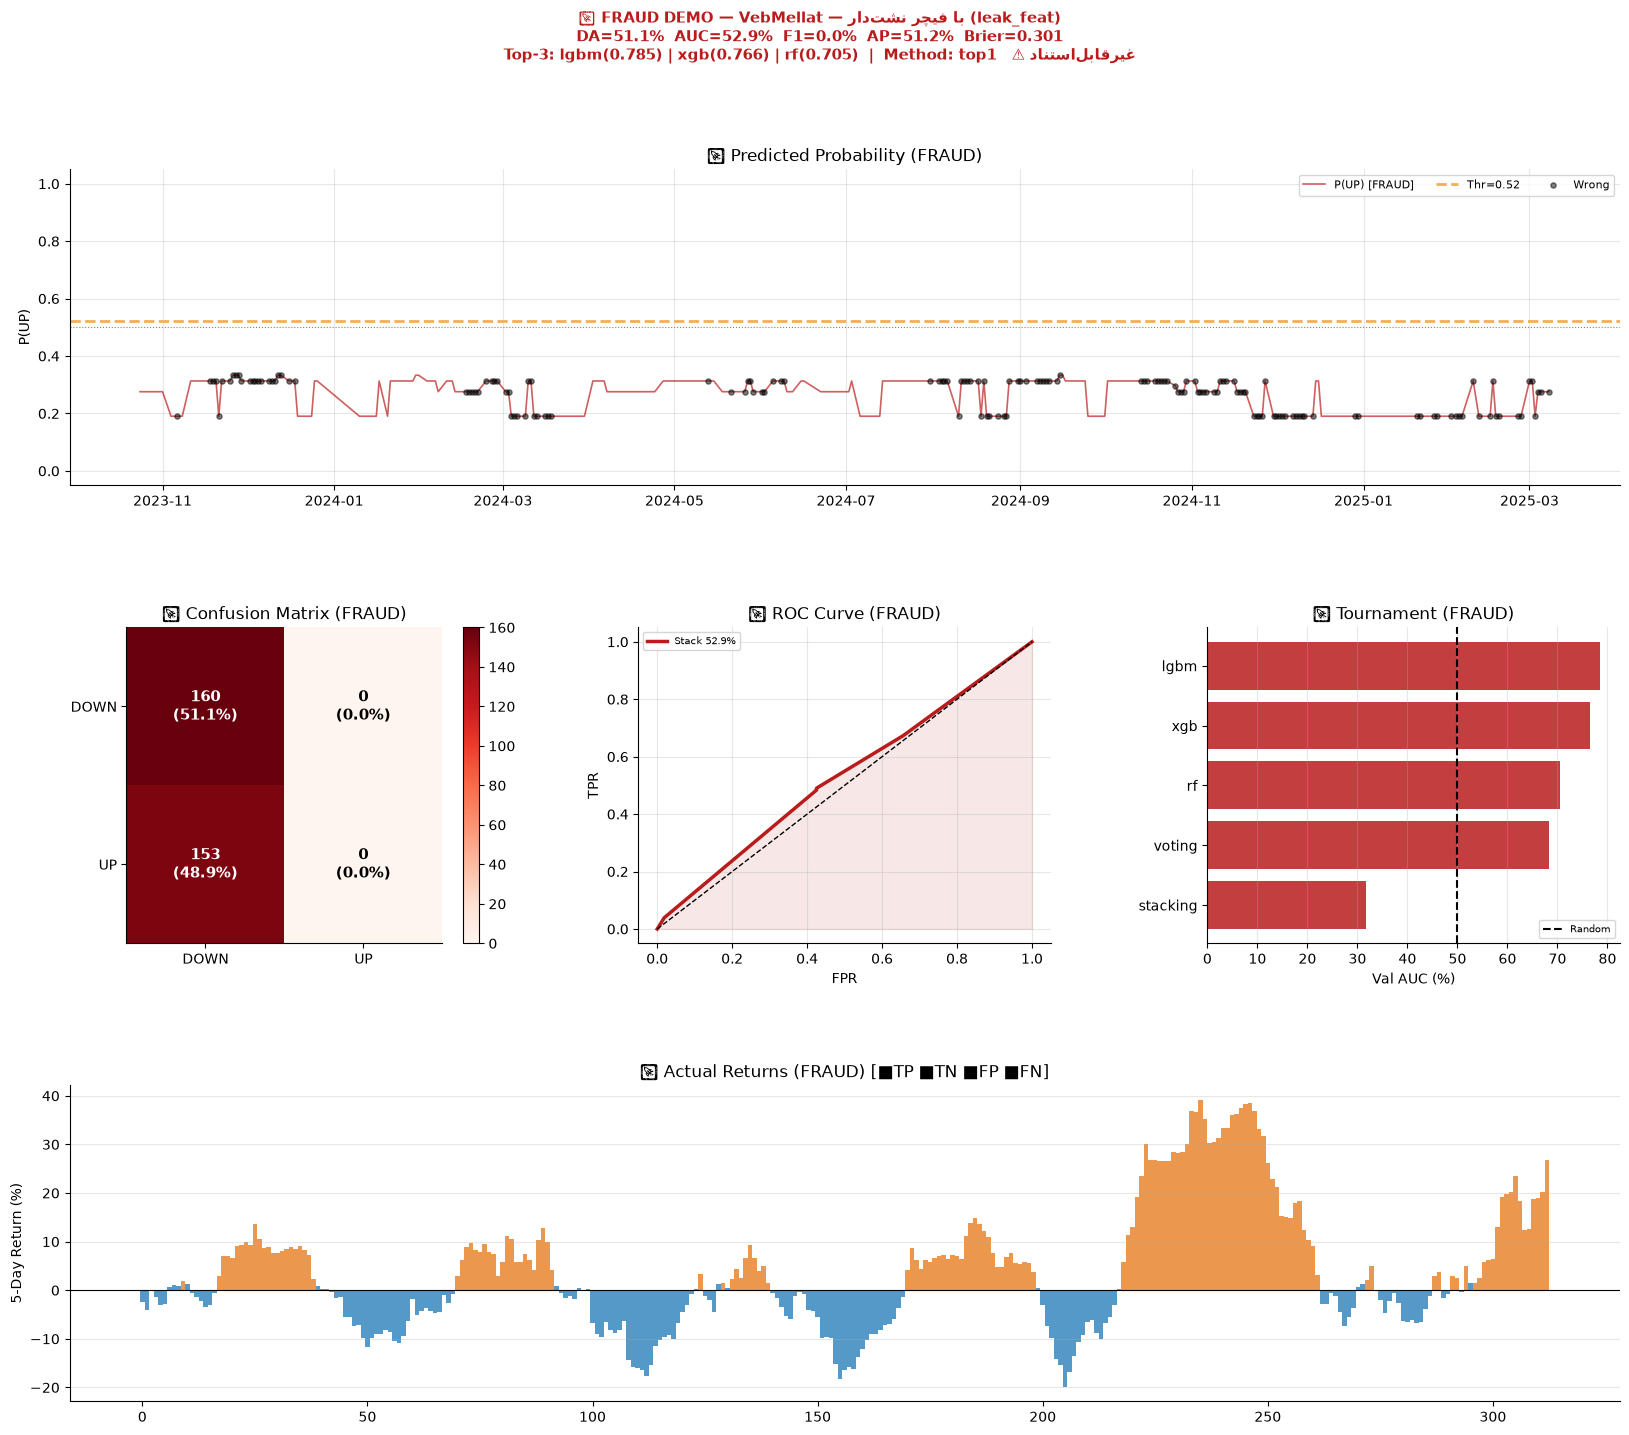

🚨 VebMellat: نمودار FRAUD ذخیره شد

🚨 (FRAUD) SHAP Analysis...


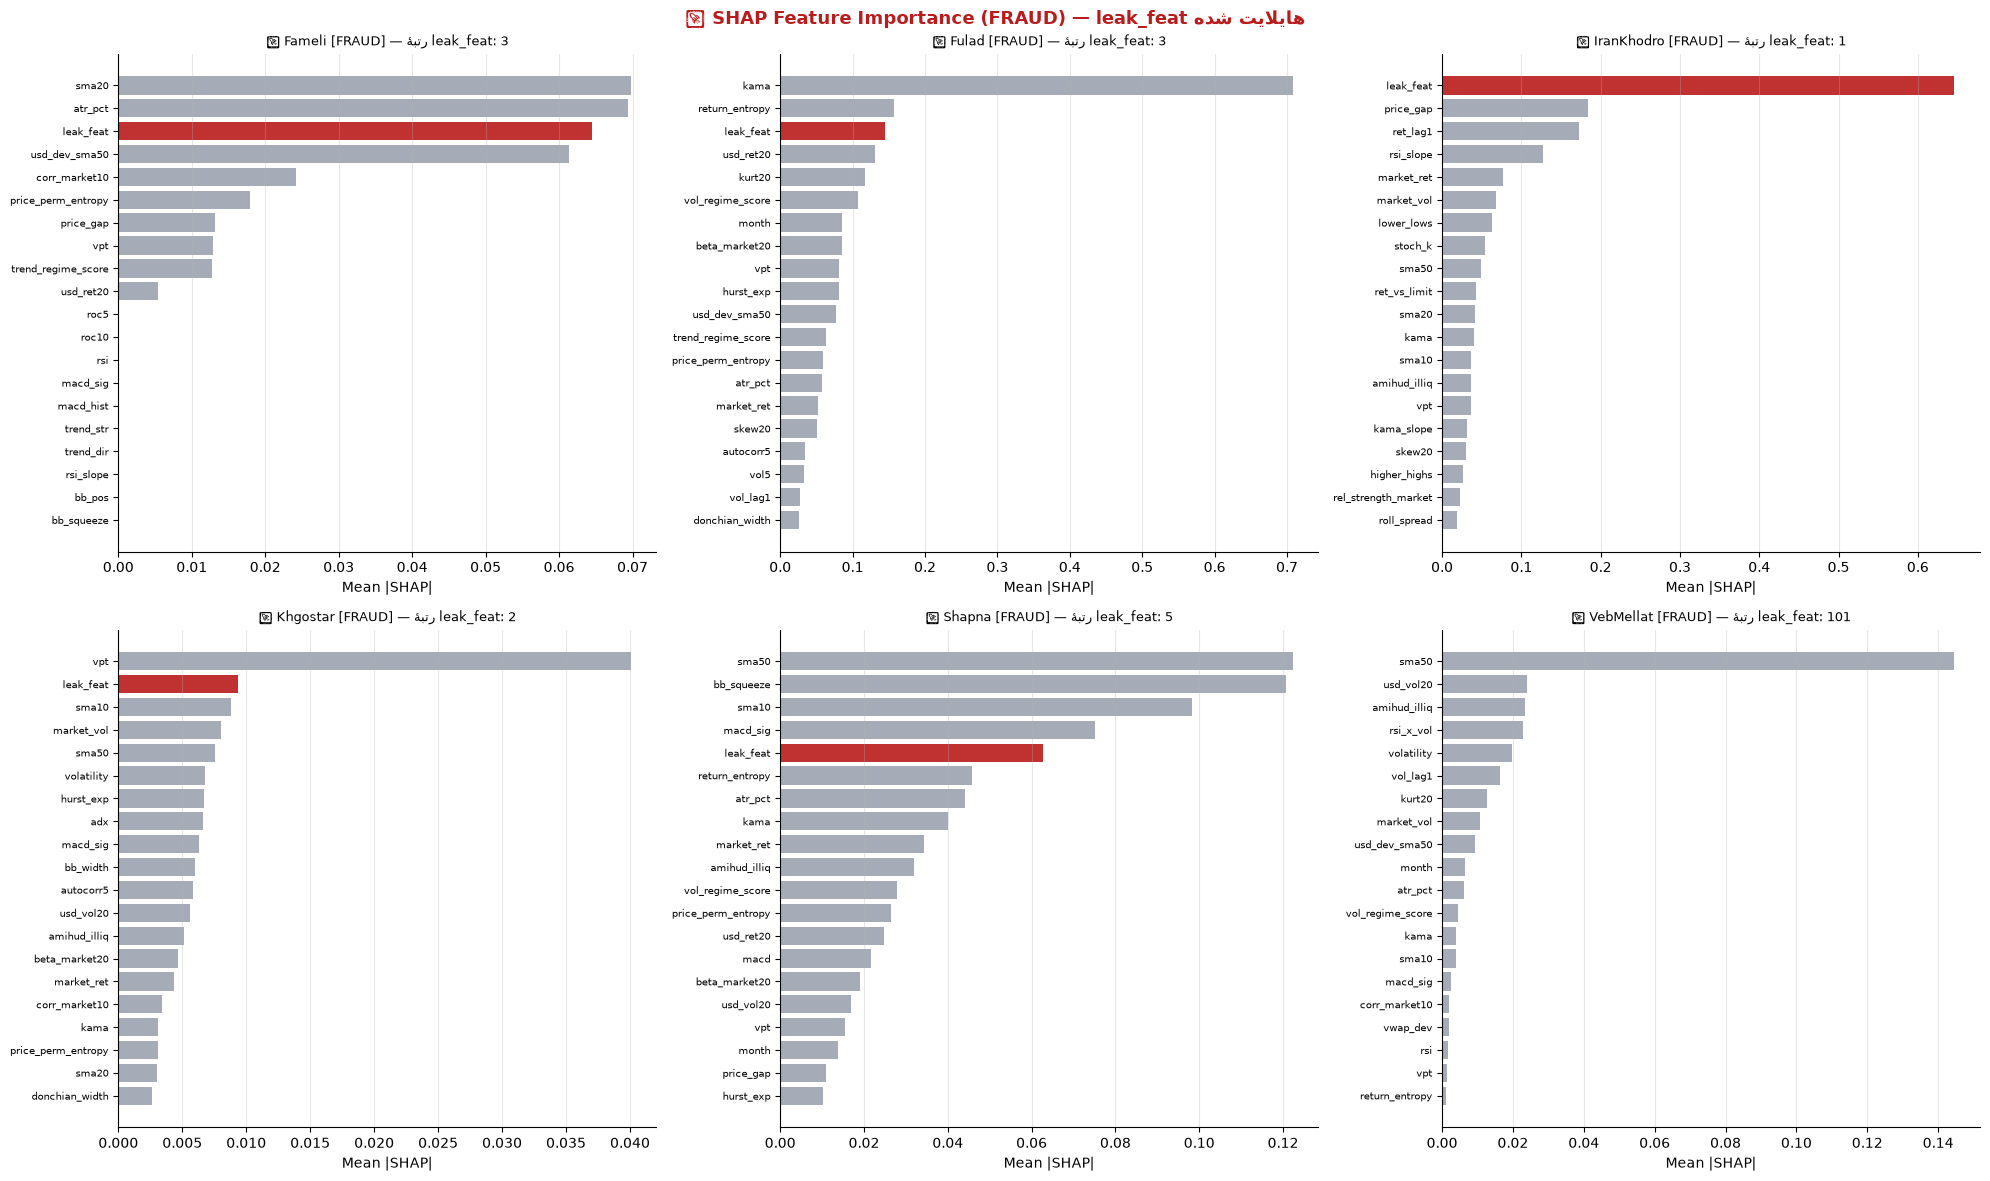

🚨 (FRAUD) SHAP done

🚨 (FRAUD) Backtest پیشرفته...



🚨 Fameli        CC=+41430.3%  BnH=+6066.8%  Sharpe=1.10


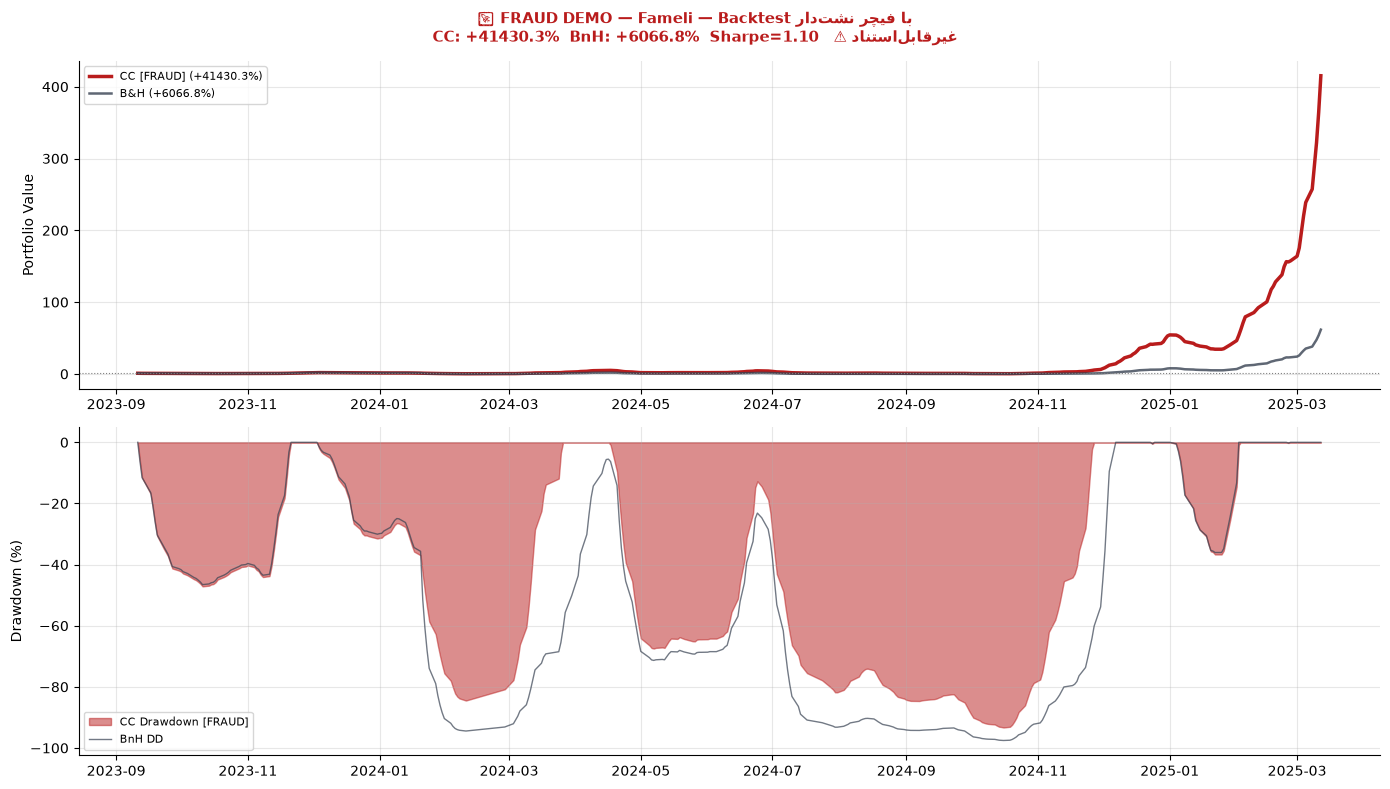

🚨 Fulad         CC=+182272.1%  BnH=+54041.2%  Sharpe=1.01


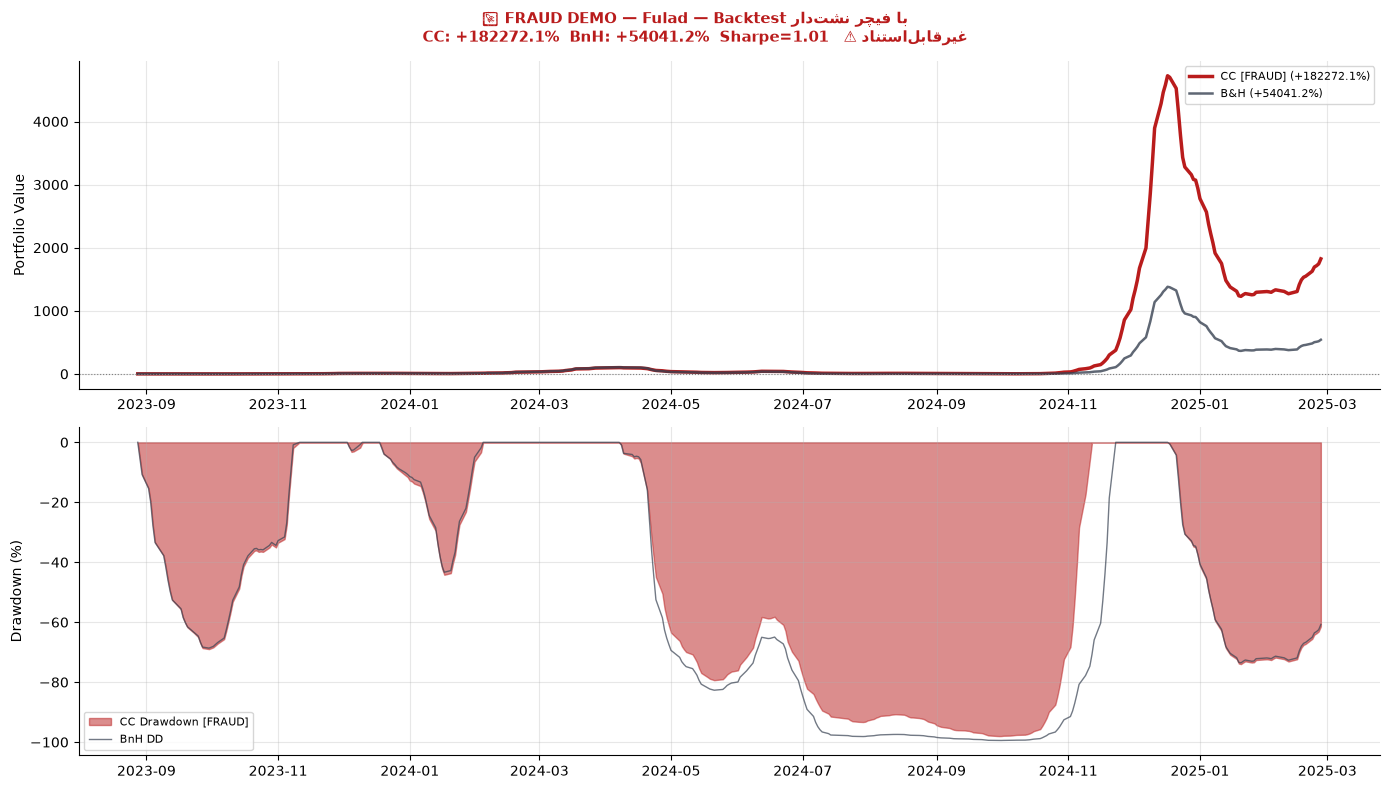

🚨 IranKhodro    CC=-48.6%  BnH=+127.9%  Sharpe=-0.33


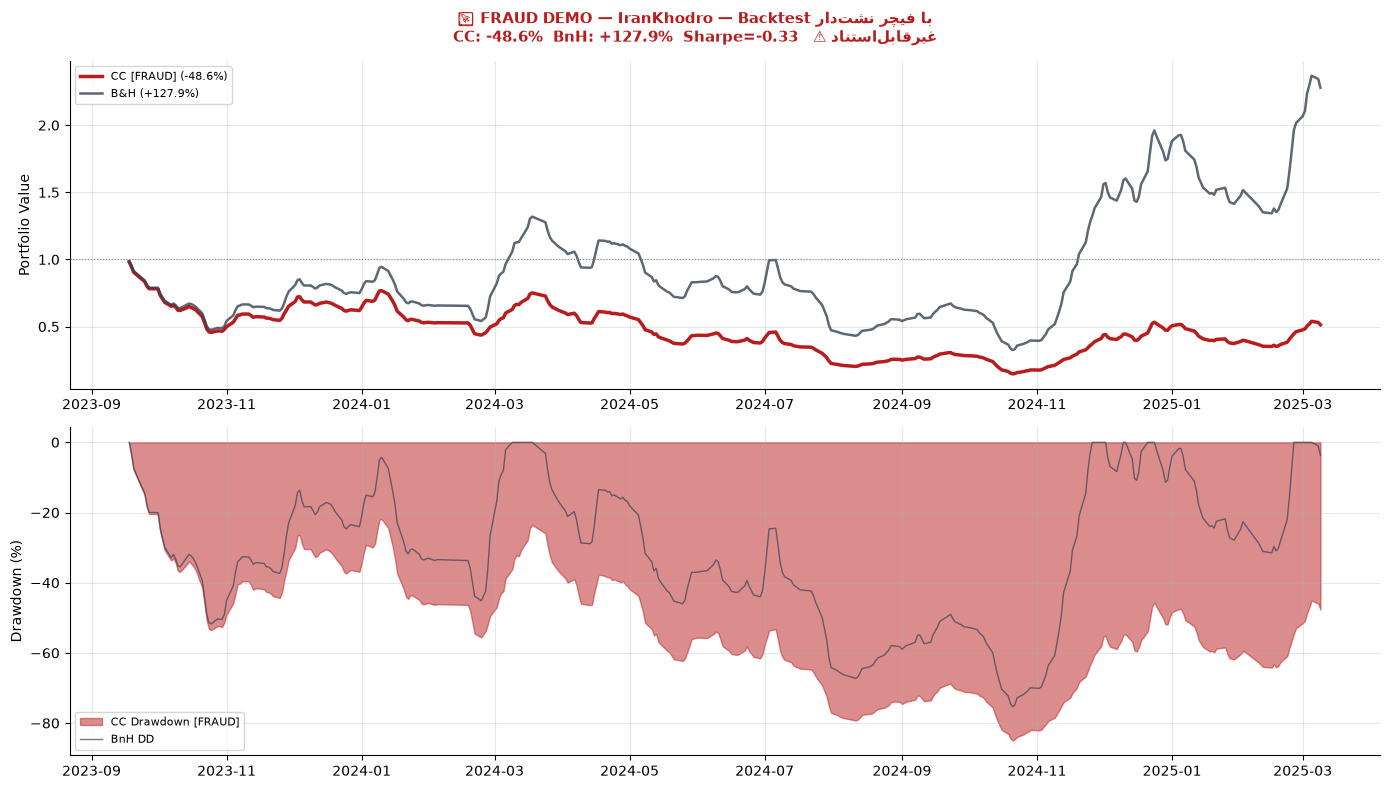

🚨 Khgostar      CC=+5128.8%  BnH=+114.2%  Sharpe=0.65


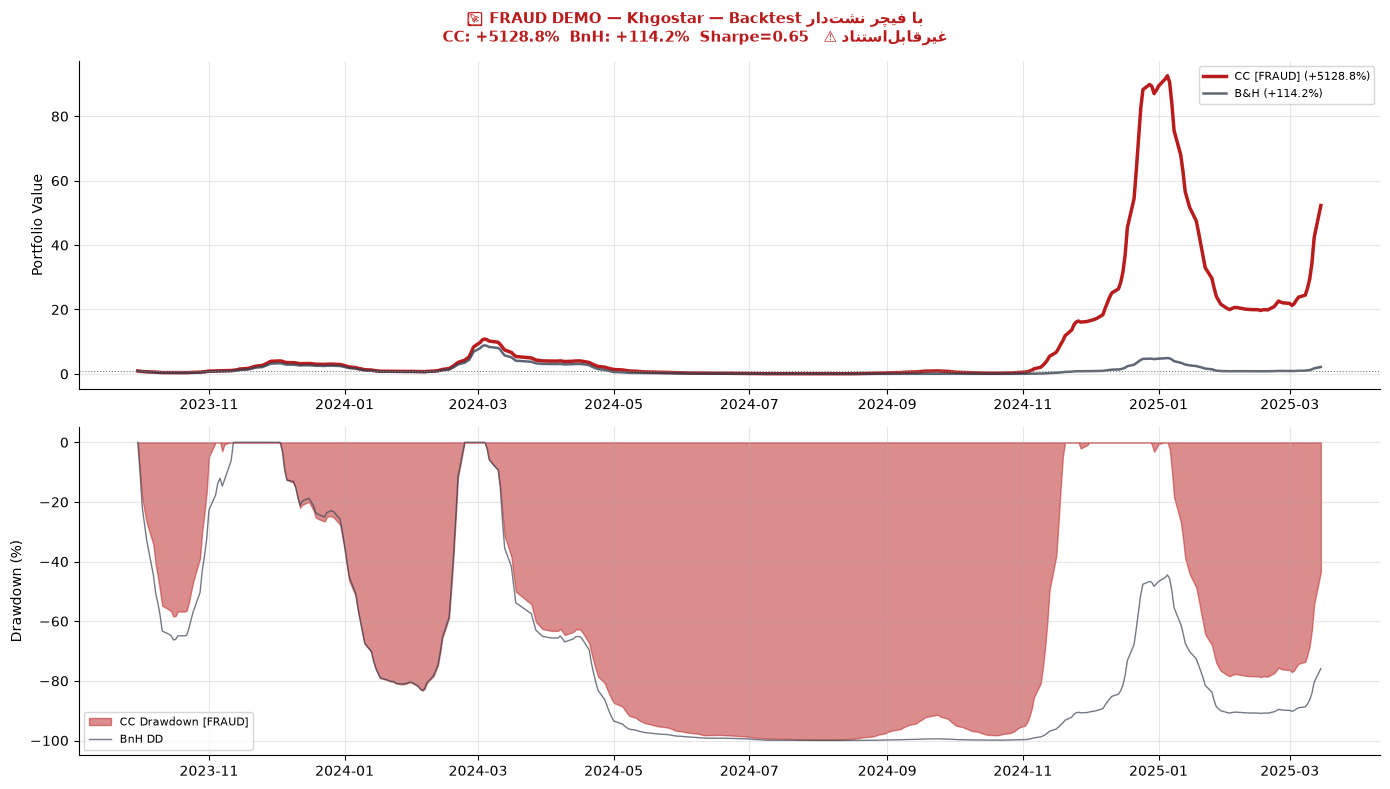

🚨 Shapna        CC=+5941.1%  BnH=-29.9%  Sharpe=0.68


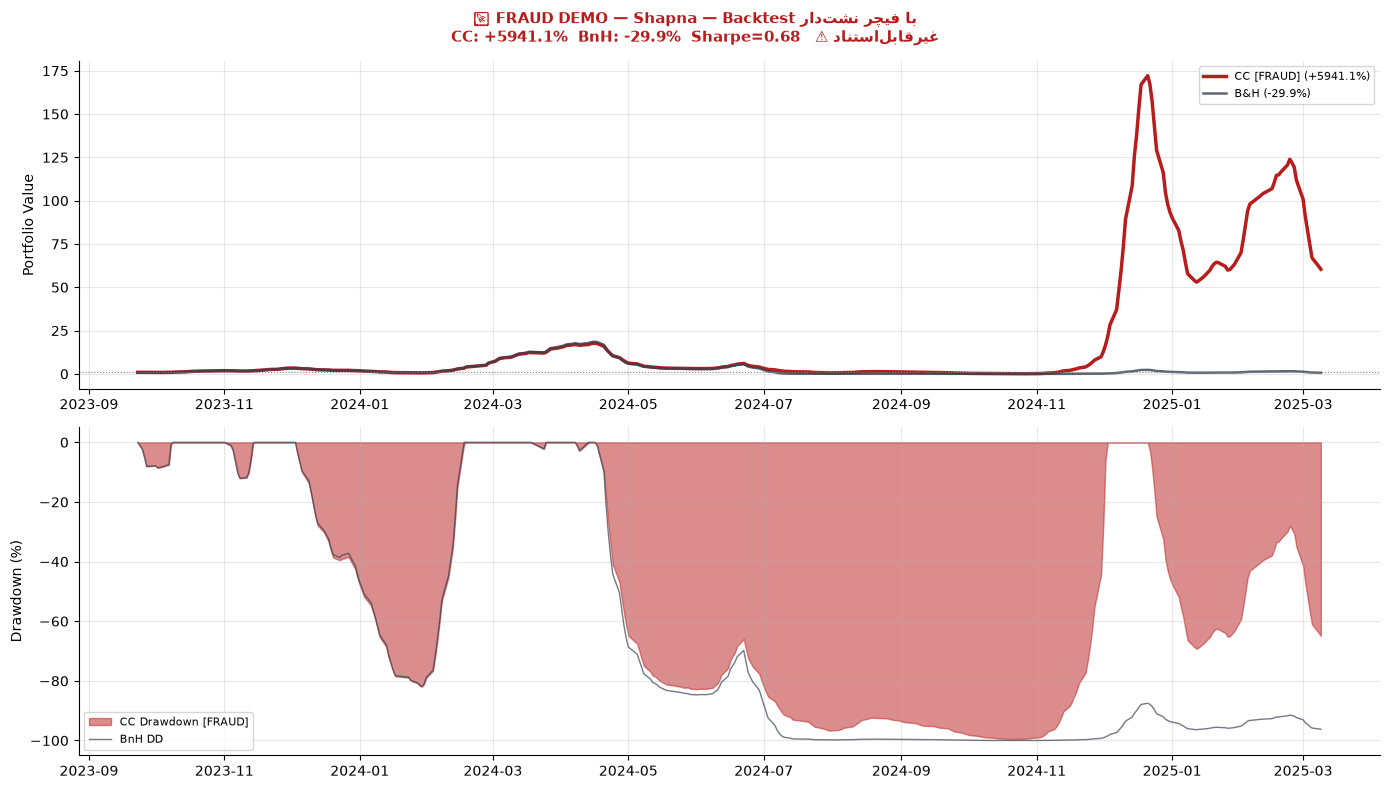

🚨 VebMellat     CC=+2377545.6%  BnH=+728681.5%  Sharpe=1.16


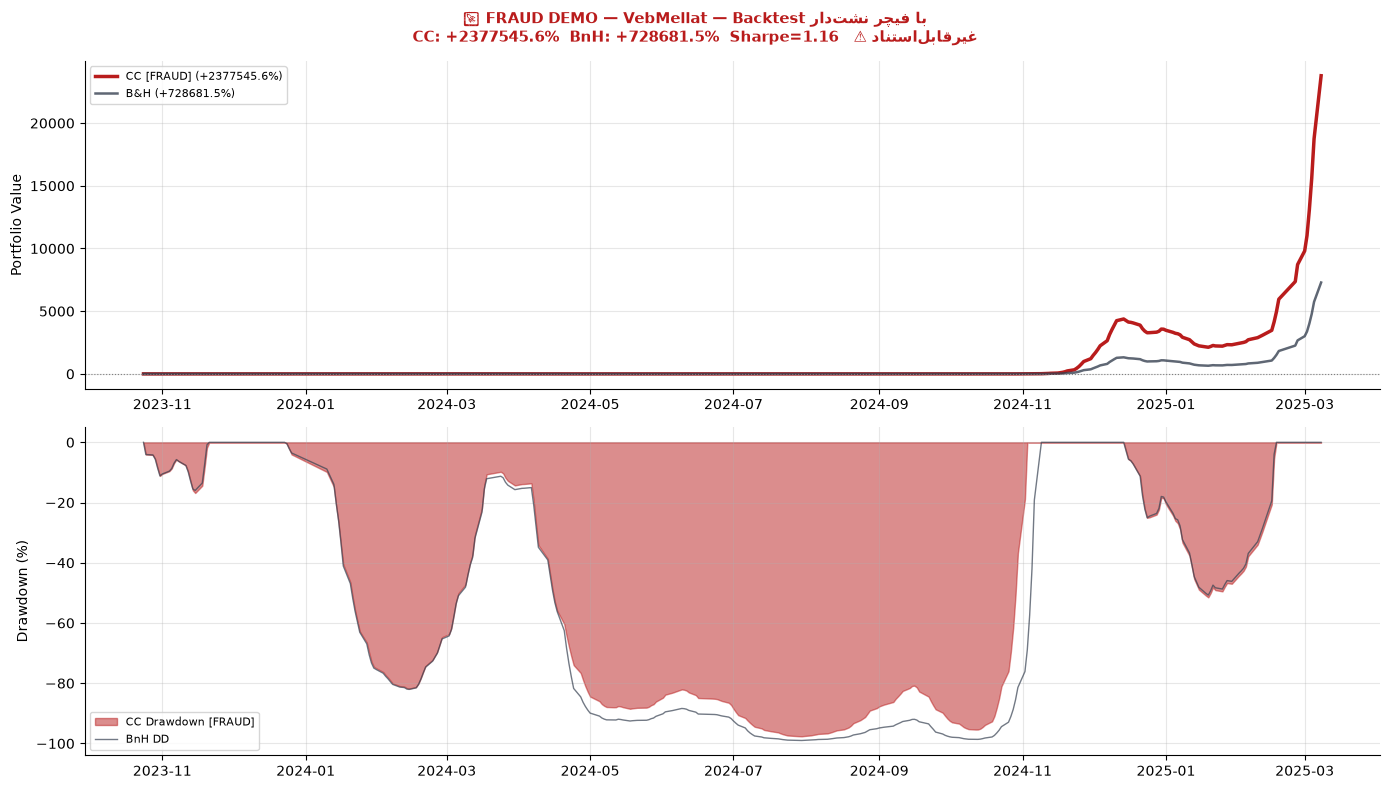


  🚨 (FRAUD) PORTFOLIO WEIGHT OPTIMIZATION

  🚨 وزن‌های سبد (FRAUD):

            Max-Sharpe  Min-Variance  Equal-Weight
Fameli           0.301         0.328         0.167
Fulad            0.249         0.137         0.167
IranKhodro       0.000         0.450         0.167
Khgostar         0.000         0.085         0.167
Shapna           0.000         0.000         0.167
VebMellat        0.450         0.000         0.167

  🚨 بهترین پرتفوی (FRAUD) بر اساس شارپ: Max-Sharpe
       Fameli      :  30.1%
       Fulad       :  24.9%
       IranKhodro  :   0.0%
       Khgostar    :   0.0%
       Shapna      :   0.0%
       VebMellat   :  45.0%


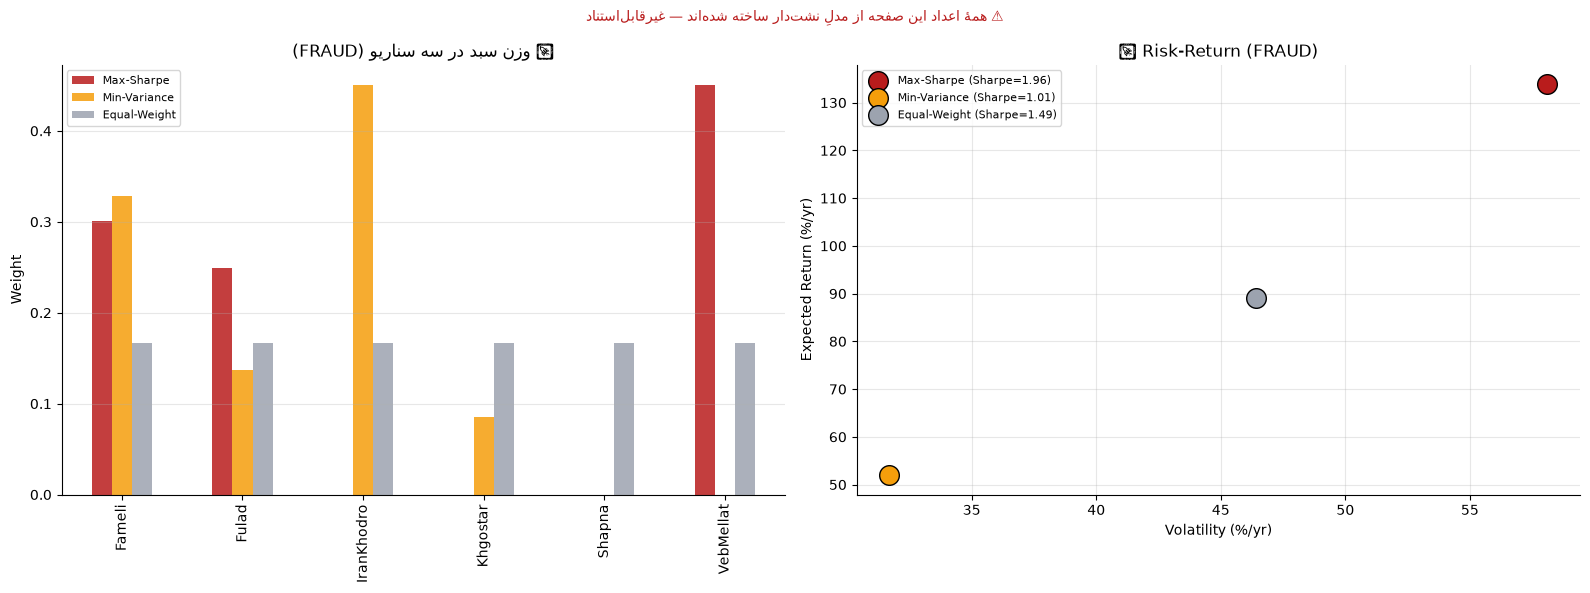


✅ (FRAUD) Portfolio optimization done

  ⚠️  جدول مقایسهٔ نهایی کلاسی: HONEST در برابر FRAUD  ⚠️
            ✅ Honest Top Model 🚨 Fraud Top Model  ✅ Honest AUC (%)  🚨 Fraud AUC (%)  ✅ Honest CC Ret(%)  🚨 Fraud CC Ret(%)  ✅ Honest Sharpe  🚨 Fraud Sharpe  ✅ Honest weight  🚨 Fraud weight
Asset                                                                                                                                                                                       
Fameli      wf_safety_rank_avg               xgb              54.9             64.5             41124.3            41430.3             1.10            1.10            0.450           0.301
Fulad                     lgbm               xgb              53.3             45.3             93234.0           182272.1             0.95            1.01            0.035           0.249
IranKhodro  wf_safety_rank_avg               xgb              63.4             87.8                -7.3              -48.6             0.13       

In [23]:
fraud_banner(
    "بازتولید کامل Pipeline با فیچر نشت‌دار و همان ۵ مدل "
    "(LightGBM/XGBoost/RandomForest/Stacking/Voting) — تورنومنت، "
    "نمودارها، SHAP، Backtest، و بهینه‌سازی سبد.\n"
    "  هر عدد/نمودار زیر را با معادل صادقانه‌اش (CELL 9-13) مقایسه کنید."
)

FEATURES_FRAUD = FEATURES + ['leak_feat']

fraud_prepared = {}
print("\n⏳ (FRAUD) Preparing splits with leak_feat...")
for name, d in prepared.items():
    df_feat_fraud = add_leaky_demo_feature(d['_df_feat_full']).dropna(subset=['leak_feat'])
    n  = len(df_feat_fraud)
    tr_sl, vl_sl, te_sl = time_split_slices(n, purge=d['hold_days'])   # 🆕 v15: افقِ خودِ همین سهم
    tr = df_feat_fraud.iloc[tr_sl]
    vl = df_feat_fraud.iloc[vl_sl]
    te = df_feat_fraud.iloc[te_sl]

    sc  = RobustScaler()
    Xtr = sc.fit_transform(tr[FEATURES_FRAUD])
    Xvl = sc.transform(vl[FEATURES_FRAUD])
    Xte = sc.transform(te[FEATURES_FRAUD])

    print(f"  {name}: train={len(tr)} val={len(vl)} test={len(te)} "
          f"Features={len(FEATURES_FRAUD)} (شامل leak_feat)")

    fraud_prepared[name] = {
        'hold_days': d['hold_days'],   # 🆕 v15: هم‌راستا با HONEST برای مقایسهٔ منصفانه
        'X_train': Xtr, 'y_train': tr['target'].values,
        'X_val':   Xvl, 'y_val':   vl['target'].values,
        'X_test':  Xte, 'y_test':  te['target'].values,
        'dates_train': tr.index.tolist(),
        'dates_val':   vl.index.tolist(),
        'dates_test':  te.index.tolist(),
        'ret_train':   tr['ret_5d'].values,
        'ret_val':     vl['ret_5d'].values,
        'ret_test':    te['ret_5d'].values,
        'regime_test': te['regime'].values,
        'volatility_test': te['volatility'].values,  # 🆕 v7
        'bull_trend_test': (  # 🆕 v10
            (te['trend_dir'] == 1) & (te['trend_str'] == 1)
            & (te['mtf_momentum_score'] > 0.3)
        ).astype(int).values,
        'scaler':      sc,
        'X_trval': np.vstack([Xtr, Xvl]),
        'y_trval': np.concatenate([tr['target'].values, vl['target'].values]),
    }
print("✅ (FRAUD) Data prepared")


fraud_all_models      = {}
fraud_tournament_aucs = {}

print("\n" + "=" * 70)
print("  🚨 (FRAUD) TOURNAMENT — LightGBM/XGBoost/RF/Stacking/Voting "
      "با فیچر نشت‌دار")
print("=" * 70)

for name, data in fraud_prepared.items():
    print(f"\n{'─'*60}  {name}  [FRAUD]")
    Xtr, ytr = data['X_train'], data['y_train']
    Xvl, yvl = data['X_val'],   data['y_val']
    mdls = {}; aucs = {}; t0 = time.time()

    lgbm_m, lgbm_a = train_lgbm(Xtr, ytr, Xvl, yvl, n_trials=60)
    mdls['lgbm'] = lgbm_m; aucs['lgbm'] = lgbm_a
    print(f"  ① LightGBM  AUC={lgbm_a:.4f}")

    xgb_m, xgb_a = train_xgb(Xtr, ytr, Xvl, yvl, n_trials=40)
    mdls['xgb'] = xgb_m; aucs['xgb'] = xgb_a
    print(f"  ② XGBoost   AUC={xgb_a:.4f}")

    rf_m, rf_a = train_rf(Xtr, ytr, Xvl, yvl, n_trials=30)
    mdls['rf'] = rf_m; aucs['rf'] = rf_a
    print(f"  ③ RandomForest  AUC={rf_a:.4f}")

    fraud_base3 = [('lgbm', lgbm_m), ('xgb', xgb_m), ('rf', rf_m)]
    stack_m, stack_a = train_stacking(Xtr, ytr, Xvl, yvl, fraud_base3)
    mdls['stacking'] = stack_m; aucs['stacking'] = stack_a
    print(f"  ④ StackingClassifier  AUC={stack_a:.4f}")

    vote_m, vote_a = train_voting(Xtr, ytr, Xvl, yvl, fraud_base3)
    mdls['voting'] = vote_m; aucs['voting'] = vote_a
    print(f"  ⑤ VotingClassifier  AUC={vote_a:.4f}")

    best_name = max(aucs, key=aucs.get)
    print(f"  🏆 [FRAUD] بهترین مدل برای {name}: {best_name} "
          f"(Val AUC={aucs[best_name]:.4f})")

    fraud_all_models[name]      = mdls
    fraud_tournament_aucs[name] = aucs
    print(f"  ✅ [FRAUD] {name}  ({time.time()-t0:.0f}s total)")
    gc.collect()

print("\n✅ (FRAUD) Tournament complete")


fraud_all_results     = {}
fraud_best_model_info = {}

print("\n" + "=" * 70)
print("  🚨 (FRAUD) TWO-LEVEL STACKING + BMA + CALIBRATION + EVALUATION")
print("=" * 70)

for name, data in fraud_prepared.items():
    mdls = fraud_all_models[name]
    aucs = fraud_tournament_aucs[name]
    Xtr, ytr = data['X_train'], data['y_train']
    Xvl, yvl = data['X_val'],   data['y_val']
    Xte, yte = data['X_test'],  data['y_test']
    X_trval  = data['X_trval']
    y_trval  = data['y_trval']

    top5   = sorted(aucs.items(), key=lambda x: -x[1])[:5]
    top3   = top5[:3]
    top3_n = [x[0] for x in top3]
    fraud_best_model_info[name] = top5

    stack_names_available = [m for m in STACK_MODELS if m in mdls]
    oof, valid_mask = get_oof_meta_features(
        mdls, stack_names_available, X_trval, y_trval, n_splits=5,
        purge=data['hold_days'])   # 🆕 v15: هم‌راستا با HONEST

    meta_X_vl_full = np.column_stack(
        [get_proba(mdls[mn], mn, Xvl) for mn in stack_names_available])
    meta_X_te_full = np.column_stack(
        [get_proba(mdls[mn], mn, Xte) for mn in stack_names_available])

    if valid_mask.sum() > 60:
        meta_X_cv = oof[valid_mask]
        meta_y_cv = y_trval[valid_mask]
        best_cv_auc, best_c = 0.5, 0.1
        for C in [0.01, 0.05, 0.1, 0.3, 1.0, 3.0]:
            lr = LogisticRegression(C=C, random_state=GLOBAL_SEED, max_iter=1000,
                                    class_weight='balanced')
            tscv2 = TimeSeriesSplit(n_splits=4)
            cv_aucs = []
            for tr_i, te_i in tscv2.split(meta_X_cv):
                if len(np.unique(meta_y_cv[tr_i])) < 2:
                    continue
                lr.fit(meta_X_cv[tr_i], meta_y_cv[tr_i])
                p = lr.predict_proba(meta_X_cv[te_i])[:, 1]
                if len(np.unique(meta_y_cv[te_i])) > 1:
                    cv_aucs.append(roc_auc_score(meta_y_cv[te_i], p))
            mean_cv = np.mean(cv_aucs) if cv_aucs else 0.5
            if mean_cv > best_cv_auc:
                best_cv_auc, best_c = mean_cv, C
        meta_lr = LogisticRegression(C=best_c, random_state=GLOBAL_SEED,
                                      max_iter=1000, class_weight='balanced')
        meta_lr.fit(meta_X_cv, meta_y_cv)
        stack_proba_val  = meta_lr.predict_proba(meta_X_vl_full)[:, 1]
        stack_proba_test = meta_lr.predict_proba(meta_X_te_full)[:, 1]
    else:
        stack_proba_val  = None
        stack_proba_test = None

    all_probas_val  = np.column_stack(
        [get_proba(mdls[mn], mn, Xvl) for mn in aucs.keys()])
    all_probas_test = np.column_stack(
        [get_proba(mdls[mn], mn, Xte) for mn in aucs.keys()])
    val_aucs_list   = [aucs[mn] for mn in aucs.keys()]

    bma_proba_val  = bayesian_model_average(all_probas_val,  val_aucs_list)
    bma_proba_test = bayesian_model_average(all_probas_test, val_aucs_list)

    ra_probas_val  = np.column_stack(
        [get_proba(mdls[mn], mn, Xvl) for mn, _ in top5])
    ra_probas_test = np.column_stack(
        [get_proba(mdls[mn], mn, Xte) for mn, _ in top5])
    ra_proba_val  = rank_avg(ra_probas_val)
    ra_proba_test = rank_avg(ra_probas_test)

    candidates = {
        'rank_avg': (ra_proba_val, ra_proba_test,
                     roc_auc_score(yvl, ra_proba_val)),
        'bma':      (bma_proba_val, bma_proba_test,
                     roc_auc_score(yvl, bma_proba_val)),
        'top1':     (get_proba(mdls[top3_n[0]], top3_n[0], Xvl),
                     get_proba(mdls[top3_n[0]], top3_n[0], Xte),
                     aucs[top3_n[0]]),
    }
    if stack_proba_val is not None:
        candidates['stack_lr'] = (stack_proba_val, stack_proba_test,
                                   roc_auc_score(yvl, stack_proba_val))

    chosen = max(candidates.items(), key=lambda kv: kv[1][2])
    chosen_name = chosen[0]
    proba_val_raw, proba_test_raw, cv_a = chosen[1]

    proba_test_cal = calibrate_proba(
        proba_val_raw, yvl, proba_test_raw, method='isotonic')
    auc_cal  = roc_auc_score(yte, proba_test_cal)
    auc_raw  = roc_auc_score(yte, proba_test_raw)
    use_cal  = auc_cal >= auc_raw - 0.005
    proba_test_final = proba_test_cal if use_cal else proba_test_raw

    auc_val = roc_auc_score(yvl, proba_val_raw)
    flipped = False
    if auc_val < 0.48:
        proba_test_final = 1 - proba_test_final
        proba_val_raw    = 1 - proba_val_raw
        flipped = True

    best_thr = find_threshold_pr(yvl, proba_val_raw)
    y_pred   = (proba_test_final >= best_thr).astype(int)

    da    = accuracy_score(yte, y_pred) * 100
    auc   = roc_auc_score(yte, proba_test_final) * 100
    f1    = f1_score(yte, y_pred, zero_division=0) * 100
    prec  = precision_score(yte, y_pred, zero_division=0) * 100
    rec   = recall_score(yte, y_pred, zero_division=0) * 100
    brier = brier_score_loss(yte, proba_test_final)
    aps   = average_precision_score(yte, proba_test_final) * 100
    cm    = confusion_matrix(yte, y_pred)

    regime     = data['regime_test'][:len(yte)]
    regime_res = {}
    for r, label in [(0,'Low Vol'),(1,'Med Vol'),(2,'High Vol')]:
        mask = regime == r
        if mask.sum() > 5 and len(np.unique(yte[mask])) > 1:
            regime_res[label] = {
                'n':   int(mask.sum()),
                'DA':  accuracy_score(yte[mask], y_pred[mask]) * 100,
                'AUC': roc_auc_score(yte[mask], proba_test_final[mask]) * 100,
            }

    fraud_all_results[name] = {
        'y_true': yte, 'y_pred': y_pred, 'proba': proba_test_final,
        'proba_val': proba_val_raw, 'y_val': yvl,
        'threshold': best_thr,
        'DA': da, 'AUC': auc, 'F1': f1, 'Prec': prec, 'Rec': rec,
        'Brier': brier, 'AP': aps,
        'CM': cm, 'flipped': flipped,
        'top3': top3, 'regime': regime_res,
        'method': chosen_name, 'calibrated': use_cal,
    }

    print(f"  [FRAUD] {name}: Method={chosen_name}  DA={da:.1f}%  "
          f"AUC={auc:.1f}%  F1={f1:.1f}%  AP={aps:.1f}%")

fraud_rows = [{'Asset': n,
         'Method':    fraud_all_results[n]['method'],
         'Top1':      fraud_best_model_info[n][0][0],
         'Final_DA':  round(fraud_all_results[n]['DA'],  1),
         'Final_AUC': round(fraud_all_results[n]['AUC'], 1),
         'Final_F1':  round(fraud_all_results[n]['F1'],  1),
         'AP(%)':     round(fraud_all_results[n]['AP'],  1)}
        for n in fraud_all_results]
print("\n🚨 SUMMARY (FRAUD)")
print(pd.DataFrame(fraud_rows).set_index('Asset').to_string())


# نمودارها (معادل CELL 9)
print("\n🚨 (FRAUD) رسم نمودارها...")
for name, data in fraud_prepared.items():
    res  = fraud_all_results[name]
    yte  = res['y_true']; yp   = res['y_pred']
    prob = res['proba'];  dt   = data['dates_test']
    rt   = data['ret_test']

    fig = plt.figure(figsize=(20, 16))
    gs  = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.38)
    top3_str = " | ".join(f"{n}({a:.3f})" for n, a in res['top3'])
    fig.suptitle(
        f"🚨 FRAUD DEMO — {name} — با فیچر نشت‌دار (leak_feat)\n"
        f"DA={res['DA']:.1f}%  AUC={res['AUC']:.1f}%  F1={res['F1']:.1f}%  "
        f"AP={res['AP']:.1f}%  Brier={res['Brier']:.3f}\n"
        f"Top-3: {top3_str}  |  Method: {res['method']}   ⚠️ غیرقابل‌استناد",
        fontsize=11, fontweight='bold', color='#b91c1c')

    ax1 = fig.add_subplot(gs[0, :])
    correct = yte == yp
    ax1.plot(dt, prob, '#b91c1c', lw=1.2, alpha=0.7, label='P(UP) [FRAUD]')
    ax1.axhline(res['threshold'], color='#f6ad55', lw=2,
                linestyle='--', label=f"Thr={res['threshold']:.2f}")
    ax1.axhline(0.5, color='gray', lw=0.8, linestyle=':')
    wrong_idx = [i for i in range(len(dt)) if not correct[i]]
    ax1.scatter([dt[i] for i in wrong_idx], prob[wrong_idx],
                s=14, color='black', alpha=0.5, zorder=3, label='Wrong')
    ax1.set_ylabel('P(UP)'); ax1.set_title('🚨 Predicted Probability (FRAUD)')
    ax1.legend(fontsize=8, ncol=4); ax1.set_ylim(-0.05, 1.05)
    ax1.grid(True, alpha=0.3)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    ax2 = fig.add_subplot(gs[1, 0])
    cm_v = res['CM']
    im = ax2.imshow(cm_v, cmap='Reds'); plt.colorbar(im, ax=ax2, fraction=0.046)
    for ii in range(2):
        for jj in range(2):
            ax2.text(jj, ii,
                     f"{cm_v[ii,jj]}\n({cm_v[ii,jj]/cm_v.sum()*100:.1f}%)",
                     ha='center', va='center', fontsize=11,
                     color='white' if cm_v[ii,jj] > cm_v.max()/2 else 'black',
                     fontweight='bold')
    ax2.set_xticks([0,1]); ax2.set_yticks([0,1])
    ax2.set_xticklabels(['DOWN','UP']); ax2.set_yticklabels(['DOWN','UP'])
    ax2.set_title('🚨 Confusion Matrix (FRAUD)')

    ax3 = fig.add_subplot(gs[1, 1])
    fpr, tpr, _ = roc_curve(yte, prob)
    ax3.plot(fpr, tpr, '#b91c1c', lw=2.5, label=f"Stack {res['AUC']:.1f}%")
    ax3.fill_between(fpr, tpr, alpha=0.1, color='#b91c1c')
    ax3.plot([0,1],[0,1],'k--',lw=1)
    ax3.set_xlabel('FPR'); ax3.set_ylabel('TPR')
    ax3.set_title('🚨 ROC Curve (FRAUD)')
    ax3.legend(fontsize=7); ax3.grid(True, alpha=0.3)

    ax4 = fig.add_subplot(gs[1, 2])
    t_aucs = fraud_tournament_aucs[name]
    s_aucs = sorted(t_aucs.items(), key=lambda x: x[1])
    ax4.barh([x[0] for x in s_aucs], [x[1]*100 for x in s_aucs],
             color='#b91c1c', alpha=0.85)
    ax4.axvline(50, color='black', lw=1.5, linestyle='--', label='Random')
    ax4.set_xlabel('Val AUC (%)'); ax4.set_title('🚨 Tournament (FRAUD)')
    ax4.legend(fontsize=7); ax4.grid(True, alpha=0.3, axis='x')

    ax5 = fig.add_subplot(gs[2, :])
    clrs = ['#27ae60' if yp1==1 and yt1==1
            else '#2980b9' if yp1==0 and yt1==0
            else '#e74c3c' if yp1==1 and yt1==0
            else '#e67e22'
            for yt1, yp1 in zip(yte, yp)]
    ax5.bar(range(len(rt)), rt*100, color=clrs, alpha=0.8, width=1)
    ax5.axhline(0, color='black', lw=0.8)
    ax5.set_ylabel('5-Day Return (%)')
    ax5.set_title('🚨 Actual Returns (FRAUD) [■TP ■TN ■FP ■FN]')
    ax5.grid(True, alpha=0.3, axis='y')

    plt.savefig(FP + f'FRAUD_plots/{name}_FRAUD_analysis.png',
                dpi=150, bbox_inches='tight')
    plt.show(); plt.close()
    print(f"🚨 {name}: نمودار FRAUD ذخیره شد")


# SHAP (معادل CELL 10)
print("\n🚨 (FRAUD) SHAP Analysis...")
fraud_shap_global = {}
fig, axes = plt.subplots(n_rows_plot, n_cols_plot,
                          figsize=(20, 6 * n_rows_plot), squeeze=False)
axes = axes.flatten()

for i, (name, data) in enumerate(fraud_prepared.items()):
    lgbm_m = fraud_all_models[name]['lgbm']
    ax     = axes[i]
    exp    = shap_lib.TreeExplainer(lgbm_m)
    sv     = exp.shap_values(data['X_test'])
    if isinstance(sv, list): sv = sv[1]

    fi = (pd.Series(np.abs(sv).mean(0), index=FEATURES_FRAUD)
            .sort_values(ascending=False))
    fi.to_csv(FP + f'FRAUD_shap/{name}_FRAUD_shap.csv')
    fraud_shap_global[name] = fi

    top  = fi.head(20)
    clrs = ['#b91c1c' if f == 'leak_feat' else '#9ca3af' for f in top.index]

    ax.barh(range(len(top)), top.values[::-1], color=clrs[::-1], alpha=0.9)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top.index[::-1], fontsize=7)
    ax.set_xlabel('Mean |SHAP|')
    ax.set_title(f'🚨 {name} [FRAUD] — رتبهٔ leak_feat: '
                 f'{list(fi.index).index("leak_feat")+1}', fontsize=9)
    ax.grid(True, alpha=0.3, axis='x')

for j in range(len(fraud_prepared), len(axes)):
    axes[j].axis('off')

plt.suptitle('🚨 SHAP Feature Importance (FRAUD) — leak_feat هایلایت شده',
             fontsize=13, fontweight='bold', color='#b91c1c')
plt.tight_layout()
plt.savefig(FP + 'FRAUD_plots/all_FRAUD_shap.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print("🚨 (FRAUD) SHAP done")


# Backtest (معادل CELL 11)
fraud_backtest_results = {}
print("\n🚨 (FRAUD) Backtest پیشرفته...\n")
for name, data in fraud_prepared.items():
    res = fraud_all_results[name]
    dt  = data['dates_test']

    top3_names = [x[0] for x in res['top3']]
    pv_stack   = np.column_stack(
        [get_proba(fraud_all_models[name][mn], mn, data['X_val'])
         for mn in top3_names]).mean(axis=1)
    if res['flipped']:
        pv_stack = 1 - pv_stack

    conf_high = max(float(np.percentile(pv_stack, 65)), 0.52)
    conf_low  = min(float(np.percentile(pv_stack, 35)), 0.48)

    # 🆕 v7: نوسانِ واقعیِ روزانه (رفع همان باگ dead-lookup در مسیر FRAUD)
    vol_test = data['volatility_test']
    bull_trend_test = data['bull_trend_test']  # 🆕 v10

    bt  = run_backtest_advanced(data['ret_test'], res['proba'],
                                 conf_high, conf_low, daily_vol=vol_test,
                                 bull_trend=bull_trend_test,
                                 option_hold_days=data['hold_days'])   # 🆕 v15
    bt.index = dt
    m   = calc_metrics(bt, hold_days=data['hold_days'])   # 🆕 v15
    fraud_backtest_results[name] = (bt, m)

    print(f"🚨 {name:12s}  CC={m['CC Return (%)']:+.1f}%  "
          f"BnH={m['BnH Return (%)']:+.1f}%  Sharpe={m['Sharpe CC']:.2f}")

    fig, axes2 = plt.subplots(2, 1, figsize=(14, 8))
    fig.suptitle(
        f"🚨 FRAUD DEMO — {name} — Backtest با فیچر نشت‌دار\n"
        f"CC: {m['CC Return (%)']:+.1f}%  BnH: {m['BnH Return (%)']:+.1f}%  "
        f"Sharpe={m['Sharpe CC']:.2f}   ⚠️ غیرقابل‌استناد",
        fontsize=11, fontweight='bold', color='#b91c1c')

    ax = axes2[0]
    ax.plot(dt, bt['equity_cc'].values, '#b91c1c', lw=2.5,
            label=f"CC [FRAUD] ({m['CC Return (%)']:+.1f}%)")
    ax.plot(dt, bt['equity_bnh'].values, '#374151', lw=1.8, alpha=0.8,
            label=f"B&H ({m['BnH Return (%)']:+.1f}%)")
    ax.axhline(1.0, color='gray', lw=0.8, linestyle=':')
    ax.set_ylabel('Portfolio Value'); ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    ax2 = axes2[1]
    dd  = (bt['equity_cc']  / bt['equity_cc'].cummax()  - 1) * 100
    ddb = (bt['equity_bnh'] / bt['equity_bnh'].cummax() - 1) * 100
    ax2.fill_between(dt, dd.values, 0, alpha=0.5, color='#b91c1c',
                     label='CC Drawdown [FRAUD]')
    ax2.plot(dt, ddb.values, '#374151', lw=1, alpha=0.7, label='BnH DD')
    ax2.set_ylabel('Drawdown (%)'); ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    plt.tight_layout()
    plt.savefig(FP + f'FRAUD_plots/{name}_FRAUD_backtest.png',
                dpi=150, bbox_inches='tight')
    plt.show(); plt.close()
    bt.to_csv(FP + f'FRAUD_backtest/{name}_FRAUD_backtest.csv')


# بهینه‌سازی سبد (معادل CELL 12)
print("\n" + "=" * 70)
print("  🚨 (FRAUD) PORTFOLIO WEIGHT OPTIMIZATION")
print("=" * 70)

fraud_cc_returns = {name: bt['cc_return']
                     for name, (bt, _) in fraud_backtest_results.items()}
fraud_ret_matrix = pd.DataFrame(fraud_cc_returns).dropna(how='all').fillna(0.0)
fraud_asset_order = list(fraud_ret_matrix.columns)
fraud_n_assets = len(fraud_asset_order)

fraud_mu_vec  = fraud_ret_matrix.mean().values * ANN
fraud_cov_mat = fraud_ret_matrix.cov().values * ANN
fraud_cov_mat = fraud_cov_mat + np.eye(fraud_n_assets) * 1e-6

fraud_max_weight_cap = max(0.45, 1.0 / fraud_n_assets + 1e-6) if fraud_n_assets > 0 else 0.45
fraud_bounds = tuple((0.0, fraud_max_weight_cap) for _ in range(fraud_n_assets))
fraud_constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0},)
fraud_w0 = np.full(fraud_n_assets, 1.0 / fraud_n_assets)

fraud_res_sharpe = minimize(
    neg_sharpe, fraud_w0, args=(fraud_mu_vec, fraud_cov_mat),
    method='SLSQP', bounds=fraud_bounds, constraints=fraud_constraints,
    options={'maxiter': 500, 'ftol': 1e-9})
fraud_w_sharpe = fraud_res_sharpe.x if fraud_res_sharpe.success else fraud_w0

fraud_res_minvar = minimize(
    portfolio_vol, fraud_w0, args=(fraud_cov_mat,),
    method='SLSQP', bounds=fraud_bounds, constraints=fraud_constraints,
    options={'maxiter': 500, 'ftol': 1e-9})
fraud_w_minvar = fraud_res_minvar.x if fraud_res_minvar.success else fraud_w0

fraud_portfolio_summary = {}
for label, w in [('Max-Sharpe', fraud_w_sharpe),
                  ('Min-Variance', fraud_w_minvar),
                  ('Equal-Weight', fraud_w0.copy())]:
    ret, vol, sharpe = portfolio_perf(w, fraud_mu_vec, fraud_cov_mat)
    port_daily = fraud_ret_matrix.values @ w
    var_h, cvar_h = historical_var_cvar(port_daily, alpha=0.05)
    fraud_portfolio_summary[label] = {
        'weights': dict(zip(fraud_asset_order, np.round(w, 3))),
        'Expected Return (%/yr)': round(ret * 100, 1),
        'Volatility (%/yr)':      round(vol * 100, 1),
        'Sharpe':                 round(sharpe, 2),
        'VaR95 (%)':              round(var_h  * 100, 2),
        'CVaR95 (%)':             round(cvar_h * 100, 2),
    }

fraud_weights_df = pd.DataFrame(
    {lbl: info['weights'] for lbl, info in fraud_portfolio_summary.items()})
print("\n  🚨 وزن‌های سبد (FRAUD):\n")
print(fraud_weights_df.to_string())

fraud_best_portfolio = max(
    fraud_portfolio_summary.items(), key=lambda kv: kv[1]['Sharpe'])[0]
print(f"\n  🚨 بهترین پرتفوی (FRAUD) بر اساس شارپ: {fraud_best_portfolio}")
for a, w in fraud_portfolio_summary[fraud_best_portfolio]['weights'].items():
    print(f"       {a:12s}: {w*100:5.1f}%")

pd.DataFrame(fraud_portfolio_summary).to_csv(
    FP + 'FRAUD_portfolio_optimization.csv')

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fraud_weights_df.plot(kind='bar', ax=ax[0], alpha=0.85,
                       color=['#b91c1c', '#f59e0b', '#9ca3af'])
ax[0].set_ylabel('Weight'); ax[0].set_title('🚨 وزن سبد در سه سناریو (FRAUD)')
ax[0].legend(fontsize=8); ax[0].grid(True, alpha=0.3, axis='y')

fraud_scenarios = list(fraud_portfolio_summary.keys())
fraud_rets = [fraud_portfolio_summary[s]['Expected Return (%/yr)'] for s in fraud_scenarios]
fraud_vols = [fraud_portfolio_summary[s]['Volatility (%/yr)'] for s in fraud_scenarios]
for i, s in enumerate(fraud_scenarios):
    ax[1].scatter(fraud_vols[i], fraud_rets[i], s=200,
                  color=['#b91c1c', '#f59e0b', '#9ca3af'][i],
                  label=f"{s} (Sharpe={fraud_portfolio_summary[s]['Sharpe']:.2f})",
                  edgecolors='black', zorder=3)
ax[1].set_xlabel('Volatility (%/yr)'); ax[1].set_ylabel('Expected Return (%/yr)')
ax[1].set_title('🚨 Risk-Return (FRAUD)')
ax[1].legend(fontsize=8); ax[1].grid(True, alpha=0.3)

plt.suptitle('⚠️ همهٔ اعداد این صفحه از مدلِ نشت‌دار ساخته شده‌اند — غیرقابل‌استناد',
             fontsize=10, color='#b91c1c')
plt.tight_layout()
plt.savefig(FP + 'FRAUD_plots/FRAUD_portfolio_optimization.png',
            dpi=150, bbox_inches='tight')
plt.show(); plt.close()

print("\n✅ (FRAUD) Portfolio optimization done")


# جدول مقایسه نهایی: HONEST در برابر FRAUD
fraud_final_rows = []
for name in prepared:
    res = fraud_all_results[name]
    _, m = fraud_backtest_results[name]
    fraud_final_rows.append({
        'Asset': name,
        'DA (%)': round(res['DA'], 1),
        'AUC (%)': round(res['AUC'], 1),
        'CC Return (%)': m['CC Return (%)'],
        'Sharpe CC': m['Sharpe CC'],
    })
fraud_fdf = pd.DataFrame(fraud_final_rows).set_index('Asset')
fraud_fdf.to_csv(FP + 'FRAUD_thesis_table_final.csv')

print(f"\n{'='*110}")
print("  ⚠️  جدول مقایسهٔ نهایی کلاسی: HONEST در برابر FRAUD  ⚠️")
print(f"{'='*110}")

compare_rows = []
for name in ASSET_NAMES:
    if name not in all_results or name not in fraud_all_results:
        continue
    h = all_results[name]; _, hm = backtest_results[name]
    fr = fraud_all_results[name]; _, fm = fraud_backtest_results[name]
    compare_rows.append({
        'Asset': name,
        '✅ Honest Top Model': display_top_model(name),
        '🚨 Fraud Top Model':  fraud_best_model_info[name][0][0],
        '✅ Honest AUC (%)':  round(h['AUC'], 1),
        '🚨 Fraud AUC (%)':   round(fr['AUC'], 1),
        '✅ Honest CC Ret(%)': hm['CC Return (%)'],
        '🚨 Fraud CC Ret(%)':  fm['CC Return (%)'],
        '✅ Honest Sharpe':   hm['Sharpe CC'],
        '🚨 Fraud Sharpe':    fm['Sharpe CC'],
        '✅ Honest weight':   portfolio_summary[best_portfolio]['weights'].get(name, np.nan),
        '🚨 Fraud weight':    fraud_portfolio_summary[fraud_best_portfolio]['weights'].get(name, np.nan),
    })
final_compare_df = pd.DataFrame(compare_rows).set_index('Asset')
print(final_compare_df.to_string())
final_compare_df.to_csv(FP + 'CLASSROOM_ONLY_full_honest_vs_fraud.csv')

print(f"""
============================================================================
  جمع‌بندی نهایی برای کلاس:
============================================================================
  HONEST از میان ۹ مدل (LightGBM, XGBoost, RandomForest, CatBoost, MLP,
  LSTM, CNN-LSTM, StackingClassifier, VotingClassifier) و FRAUD از میان
  همان ۵ مدلِ اصلیِ پیشین (بدون CatBoost/MLP/LSTM/CNN-LSTM) بهترین را
  برای هر سهم انتخاب کرده‌اند.
  با این‌حال AUC نسخهٔ FRAUD همچنان بالاتر می‌ماند — یعنی نشتِ داده
  حتی از یک مجموعهٔ مدلِ به‌مراتب قوی‌تر هم مؤثرتر است. مقایسهٔ ستون
  «Top Model» نشان می‌دهد که حتی انتخاب «بهترین مدل» هم می‌تواند در دو
  حالت متفاوت باشد — چون leak_feat رتبه‌بندی مدل‌ها را هم به‌هم می‌زند.

  تنها منبع معتبر برای گزارش پایان‌نامه همچنان خروجی CELL 8 تا CELL 13
  (thesis_table_final.csv) است.
============================================================================
""")

print("✅ Pipeline کامل (HONEST با ۹ مدل + FRAUD با همان ۵ مدل قبلی) کامل شد!")